## 0. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm
import glob

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')

from sbnd.cafclasses.slice import CAFSlice
from sbnd.cafclasses.nu import NU
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import *
from sbnd.general import plotters
from naming import *
from sbnd.general.utils import read_hdf

%load_ext autoreload
%autoreload 2

## 1. Constants

In [4]:
# Fill these
checkpoint = 'checkpoint9_interaction_cuts_test3'
VERSION = 'v10'
NCPU = 16
SMALL = 'cuts'
CONTAINED = True
CATEGORIES = [0]


PLOT_DIR = f'{DATA_DIR}/plots/{checkpoint}'
TABLE_DIR = f'{DATA_DIR}/tables/{checkpoint}'

#MC Fnames
# Use from syst files
MC_FNAMES = glob.glob(
  f'{DATA_DIR}/mc_syst/{VERSION}/*_nosyst*/*.df'
)
# Use nominal
# MC_FNAMES = glob.glob(
#   f'{DATA_DIR}/det_var/nominal/{VERSION}/*_nominal*/*.df'
# )
# Use small file
# MC_FNAMES = glob.glob(
#   f'{DATA_DIR}/mc_syst/v9/mcbnb_smallpand_nosyst_nocuts_recomb.df'
# )
DATA_OFFBEAM_FNAMES = glob.glob(
  f'{DATA_DIR}/offbeam/{VERSION}/*data*/*.df'
)
DATA_FNAMES = glob.glob(
  f'{DATA_DIR}/data/{VERSION}/*dataonbeam*/*.df'
)
# DATA_FNAMES = glob.glob(
#   f'{DATA_DIR}/data/{VERSION}/dataonbeam_dev.df'
# )
MC_LOWE_FNAMES = glob.glob(
  f'{DATA_DIR}/mc_lowe/{VERSION}/*_mclowe_*/*.df'
)

#Make copies to track original length
MC_FNAMES_FULL = MC_FNAMES.copy()
DATA_FNAMES_FULL = DATA_FNAMES.copy()
DATA_OFFBEAM_FNAMES_FULL = DATA_OFFBEAM_FNAMES.copy()
MC_LOWE_FNAMES_FULL = MC_LOWE_FNAMES.copy()

if SMALL == True:
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)//30]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)//30]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)//30]
  cuts_to_apply = None
  cuts_in_chain = PAND_CUTS_CONT
elif SMALL == 'cuts':
  print('Warning: Cutting down on data for testing')
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)//5]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)//2]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)//2]
  cuts_to_apply = PAND_CUTS_CONT[:-5]
  cuts_in_chain = PAND_CUTS_CONT[-5:]
elif SMALL == False: #No cuts, but a lot of data
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)//15]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)//15]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)//15]
  cuts_to_apply = None
  cuts_in_chain = PAND_CUTS_CONT

print('*' * 70)
print('checkpoint: ',checkpoint)
print('VERSION: ',VERSION)
print('NCPU: ',NCPU)
print('SMALL: ',SMALL)
print('CONTAINED: ',CONTAINED)
print('CATEGORIES: ',CATEGORIES)
print('PLOT_DIR: ',PLOT_DIR)
print('cuts_to_apply: ',cuts_to_apply)
print('cuts_in_chain: ',cuts_in_chain)
print('frac MC_FNAMES: ',len(MC_FNAMES)/len(MC_FNAMES_FULL))
print('frac DATA_OFFBEAM_FNAMES: ',len(DATA_OFFBEAM_FNAMES)/len(DATA_OFFBEAM_FNAMES_FULL))
print('frac DATA_FNAMES: ',len(DATA_FNAMES)/len(DATA_FNAMES_FULL))
print('frac MC_LOWE_FNAMES: ',len(MC_LOWE_FNAMES)/len(MC_LOWE_FNAMES_FULL))
print('MC_FNAMES[0]: ',MC_FNAMES[0])
print('DATA_OFFBEAM_FNAMES[0]: ',DATA_OFFBEAM_FNAMES[0])
print('DATA_FNAMES[0]: ',DATA_FNAMES[0])
print('MC_LOWE_FNAMES[0]: ',MC_LOWE_FNAMES[0])
print('*' * 70)

**********************************************************************
checkpoint:  checkpoint9_interaction_cuts_test3
VERSION:  v10
NCPU:  16
SMALL:  cuts
CONTAINED:  True
CATEGORIES:  [0]
PLOT_DIR:  /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint9_interaction_cuts_test3
cuts_to_apply:  ['flashpe', 'flashmatch', 'cosmic']
cuts_in_chain:  ['fv', 'muon', 'cont_full', 'cont', 'all_cont']
frac MC_FNAMES:  0.2
frac DATA_OFFBEAM_FNAMES:  0.5
frac DATA_FNAMES:  1.0
frac MC_LOWE_FNAMES:  0.5
MC_FNAMES[0]:  /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v10/2026_06_23_115539__nosyst_nocuts_recomb_mcbnb_largepand_nosyst_nocuts_recomb/nosyst_nocuts_recomb_mcbnb_largepand_nosyst_nocuts_recomb_414.df
DATA_OFFBEAM_FNAMES[0]:  /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/offbeam/v10/2026_06_23_130111__nosyst_nocuts_recomb_data_large/nosyst_nocuts_recomb_data_large_9.df
DATA_FNAMES[0]: 

## 2. Load the data

In [5]:
POT_LOWE = read_hdf(MC_LOWE_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
print(f'POT_LOWE: {POT_LOWE:.2e}')
POT_MC = read_hdf(MC_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
print(f'POT_MC: {POT_MC:.2e}')
LIVETIME_OFFBEAM = read_hdf(DATA_OFFBEAM_FNAMES,key=HDR_KEY, ncpu=NCPU, show_progress=True).noffbeambnb.values.sum()
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')
POT_DATA = read_hdf(DATA_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
LIVETIME_DATA = 9.51e5*POT_DATA/4.58e18 # Temporary override
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
POT_LABEL = f'{POT_DATA:.2e} POT'
print(f'POT_LABEL: {POT_LABEL}')

read_hdf: 100%|██████████| 154/154 [00:16<00:00,  9.59it/s]


POT_LOWE: 1.14e+20


read_hdf: 100%|██████████| 200/200 [00:12<00:00, 15.64it/s]


POT_MC: 1.12e+20


read_hdf: 100%|██████████| 250/250 [00:10<00:00, 22.97it/s]


LIVETIME_OFFBEAM: 4.17e+07


read_hdf: 100%|██████████| 100/100 [00:06<00:00, 16.49it/s]


LIVETIME_DATA: 9.50e+05
POT_LABEL: 4.57e+18 POT


In [ ]:
# Get slices (apply cosmic cuts)
t0 = time.time()
slc_mc = CAFSlice.load(MC_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=cuts_to_apply,
  show_progress=cuts_to_apply is None
)
t1 = time.time()
print(f'Time to load MC: {t1-t0:.2f}s')
t0 = time.time()
slc_lowe = CAFSlice.load(MC_LOWE_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=cuts_to_apply,
  show_progress=cuts_to_apply is None
)
t1 = time.time()
print(f'Time to load MC_LOWE: {t1-t0:.2f}s')
t0 = time.time()
slc_offbeam = CAFSlice.load(DATA_OFFBEAM_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=cuts_to_apply,
  show_progress=cuts_to_apply is None
)
t1 = time.time()
print(f'Time to load DATA_OFFBEAM: {t1-t0:.2f}s')
t0 = time.time()
slc_data = CAFSlice.load(DATA_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=cuts_to_apply,
  show_progress=cuts_to_apply is None
)
t1 = time.time()
print(f'Time to load DATA: {t1-t0:.2f}s')
for s in [slc_mc,slc_lowe,slc_offbeam,slc_data]:
  s.cut_is_cont(cut=False) # Add cont_full cut

# Get mcnu
t0 = time.time()
mcnu = NU.load(MC_FNAMES,
  key=MCNU_KEY,
  ncpu=NCPU,
  show_progress=cuts_to_apply is None
)
t1 = time.time()
print(f'Time to load MCNU: {t1-t0:.2f}s')
t0 = time.time()
mcnu_lowe = NU.load(MC_LOWE_FNAMES,
  key=MCNU_KEY,
  ncpu=NCPU,
  show_progress=cuts_to_apply is None
)
t1 = time.time()
print(f'Time to load MCNU_LOWE: {t1-t0:.2f}s')

### 2.1 Rescale to MC POT

In [ ]:
# Scale
slc_mc.scale_to_pot(POT_DATA,sample_pot=POT_MC,overwrite=True)
slc_lowe.scale_to_pot(POT_DATA,sample_pot=POT_LOWE,overwrite=True)
slc_offbeam.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM,overwrite=True,f=F_SCALE)

--scaling to POT (4.07e-02): 1.12e+20 -> 4.57e+18
--scaling to POT (4.01e-02): 1.14e+20 -> 4.57e+18
--scaling to livetime (2.11e-02): 4.17e+07 --> 9.50e+05
---scale factor without f: 2.2760e-02
--- f: 0.0725


In [ ]:
# Combine
slc_mc.combine(slc_offbeam,duplicate_ok=True,offset=int(1e6))
del slc_offbeam
slc_mc.combine(slc_lowe,duplicate_ok=True,offset=int(2e6))
del slc_lowe

mcnu.combine(mcnu_lowe,duplicate_ok=True,offset=int(1e6))
del mcnu_lowe

In [ ]:
#Add event type
from makedf1muX import _process_mcnu
mcnu = _process_mcnu(mcnu.data,slc_mc,True)

--scaling to POT (1.00e+00): 1.00e+00 -> 1.00e+00


### 2.3 Add true number of particles

In [10]:
pandora_true_trk = slc_mc.data.truth.nmu_25MeV +\
                      slc_mc.data.truth.np_50MeV +\
                      slc_mc.data.truth.npi_25MeV +\
                      slc_mc.data.truth.nk_25MeV
pandora_true_shw = slc_mc.data.truth.ne_25MeV +\
                            2*slc_mc.data.truth.npi0_0MeV +\
                            slc_mc.data.truth.ng
pandora_true_part = pandora_true_trk + pandora_true_shw

slc_mc.add_cols('truth.ntrue_part',pandora_true_part)

## 3. Make plots as function of cut

In [ ]:
# Break data into lists of objects
slcs = []

#Get event type col
slc_event_type_col = slc_mc.get_key('truth.event_type')
#inter_event_type_col = inter.get_key('truth.event_type')

# Group data by event type once
slc_groups = slc_mc.data.groupby(slc_event_type_col)
#inter_groups = inter.data.groupby(inter_event_type_col)

# Create objects only for groups that exist
for key, val in EVENT_TYPE_LIST.items():
    if key in slc_groups.groups:
        slcs.append(CAFSlice(slc_groups.get_group(key)))

#### 3.1.1 (Optional, check cosmic contamination)

In [62]:
# Copy _slcs
_slcs = [s.copy() for s in slcs]

# Get event counts for each cut
counts = np.zeros((len(PAND_CUTS)+1,len(_slcs)+1)) # + 1 to account for off beam/cv sample
percentage = counts.copy()
for i,cut in tqdm(enumerate(PAND_CUTS+['']),desc='Get bands'): # Add empty string to account for cut being added at end
  # Fill counts
  for j,s in enumerate(_slcs):
    if j == len(_slcs)-1:
      #Off beam
      offbeam_mask = np.array([ind[-1] >= int(2e5) for ind in list(s.data.index)],dtype=bool)
      cv_mask = ~offbeam_mask
      counts[i,j+1] = s.data[offbeam_mask].genweight.sum()
      counts[i,j] = s.data[cv_mask].genweight.sum()
    else:
      counts[i,j] = s.data.genweight.sum()
    # Actually cut
    if cut == '': continue
    s.apply_cut(cut)
percentage = counts/counts.sum(axis=1,keepdims=True)

Get bands: 0it [00:00, ?it/s]

Applied cut on key: cut.flashpe (71,410 --> 71,083)
Applied cut on key: cut.flashpe (87,807 --> 87,179)
Applied cut on key: cut.flashpe (71,136 --> 69,077)
Applied cut on key: cut.flashpe (152,857 --> 143,027)
Applied cut on key: cut.flashpe (1,716 --> 1,708)
Applied cut on key: cut.flashpe (50,338 --> 47,810)


Get bands: 1it [00:13, 13.96s/it]

Applied cut on key: cut.flashpe (7,951,989 --> 4,785,569)
Applied cut on key: cut.flashmatch (71,083 --> 65,334)
Applied cut on key: cut.flashmatch (87,179 --> 78,511)
Applied cut on key: cut.flashmatch (69,077 --> 58,090)
Applied cut on key: cut.flashmatch (143,027 --> 102,128)
Applied cut on key: cut.flashmatch (1,708 --> 1,526)
Applied cut on key: cut.flashmatch (47,810 --> 38,814)


Get bands: 2it [00:24, 11.81s/it]

...

Applied cut on key: cut.fv (375,497 --> 58,867)
Applied cut on key: cut.muon (64,546 --> 64,533)
Applied cut on key: cut.muon (75,576 --> 55,263)
Applied cut on key: cut.muon (10,976 --> 2,271)
Applied cut on key: cut.muon (13,754 --> 7,268)
Applied cut on key: cut.muon (1,136 --> 141)
Applied cut on key: cut.muon (29,359 --> 3,753)


Get bands: 5it [00:27,  3.09s/it]

Applied cut on key: cut.muon (58,867 --> 34,375)
Applied cut on key: cut.cosmic (64,533 --> 60,537)
Applied cut on key: cut.cosmic (55,263 --> 51,388)
Applied cut on key: cut.cosmic (2,271 --> 2,064)
Applied cut on key: cut.cosmic (7,268 --> 6,262)
Applied cut on key: cut.cosmic (141 --> 134)
Applied cut on key: cut.cosmic (3,753 --> 3,429)
Applied cut on key: cut.cosmic (34,375 --> 18,077)


Get bands: 7it [00:27,  3.90s/it]

Applied cut on key: cut.lowz (60,537 --> 60,455)
Applied cut on key: cut.lowz (51,388 --> 51,152)
Applied cut on key: cut.lowz (2,064 --> 1,984)
Applied cut on key: cut.lowz (6,262 --> 3,610)
Applied cut on key: cut.lowz (134 --> 132)
Applied cut on key: cut.lowz (3,429 --> 3,412)
Applied cut on key: cut.lowz (18,077 --> 17,588)


In [64]:
pct_df = pd.DataFrame(percentage,
  index=['precut']+PAND_CUTS,
  columns=labels+['offbeam'])
count_df = pd.DataFrame(counts,
  index=['precut']+PAND_CUTS,
  columns=labels+['offbeam'])
cosmic_df = count_df.iloc[:,-2:]
cosmic_pct_df = cosmic_df/cosmic_df.values.sum(axis=1,keepdims=True)

In [69]:
cosmic_pct_df*100

,Cosmic,offbeam
precut,80.839889,19.160111
flashpe,79.104183,20.895817
flashmatch,54.817820,45.182180
fv,74.306056,25.693944
muon,67.711849,32.288151
cosmic,31.785140,68.214860
lowz,31.292906,68.707094


#### 3.1.2 Make labels

In [ ]:
#Get label info
labels = []
names = []
colors = []

for key,item in EVENT_TYPE_LIST.items():
    if key == -1: #no unknown for now
        continue
    labels.append(item[0])
    names.append(item[1])
    colors.append(item[2])

slc_weights = [s.data.genweight for s in slcs]

#Assert no nans in weights
assert [any(np.isnan(sw)) for sw in slc_weights].count(True) == 0


### 3.1 Spectra + Pur/eff tables

#### 3.1.1 Pur/eff tables (only run with full sample)

In [11]:
from pathlib import Path

from sbnd.plotlibrary import makeplot
from sbnd.general import plotters


def _to_percent(vals):
    vals = list(vals)
    if len(vals) and max(vals) <= 1:
        vals = [v * 100 for v in vals]
    return [round(v, 2) for v in vals]


def _differential_step(vals):
    """Step change in purity-like metrics (not cumulative retention)."""
    out = [100.0] * len(vals)
    for i, v in enumerate(vals):
        if i == 0:
            continue
        out[i] = round(v - vals[i - 1], 2)
    out[0] = 'n/a'
    return out


def _differential_cumulative(vals):
    """Differential fraction retained at each cut (same convention as efficiency column)."""
    out = [100.0] * len(vals)
    for i, v in enumerate(vals):
        if i == 0:
            continue
        out[i] = round(100 - (vals[i - 1] - v), 2)
    out[0] = 'n/a'
    return out


def create_purity_efficiency_table(
    reco_pur,
    reco_eff,
    gen_pur,
    gen_eff,
    labels,
    ax,
    differential_reco_pur=False,
    differential_reco_eff=False,
    differential_gen_pur=False,
    differential_gen_eff=False,
    save_name='',
):
    """
    Table of reco/generator purity and efficiency by cut.

    Parameters
    ----------
    reco_pur, reco_eff, gen_pur, gen_eff : array-like
        Fractions or percents (auto-scaled if max <= 1).
    labels : list
        Cut labels (with or without leading 'No cut').
    ax : matplotlib.axes.Axes
        Axis for the table.
    differential_* : bool
        Add differential column per metric when True.
    save_name : str
        If non-empty, write results to this CSV path.
    """
    ax.axis('off')
    _labels = labels.copy()

    if (len(reco_pur) - 1 == len(_labels)) and _labels[0] != 'No cut':
        _labels.insert(0, 'No cut')
    elif (len(reco_pur) == len(_labels)) and _labels[0] == 'No cut':
        pass
    else:
        raise ValueError(
            f'reco_pur and label lists are not the same length: {len(reco_pur)} != {len(_labels)}'
        )

    n = len(_labels)

    def _check_lengths(name, vals):
        if len(vals) != n:
            raise ValueError(
                f'{name} and label lists are not the same length: {len(vals)} != {n}'
            )

    _check_lengths('reco_eff', reco_eff)
    _check_lengths('gen_pur', gen_pur)
    _check_lengths('gen_eff', gen_eff)

    reco_pur_pct = _to_percent(reco_pur)
    reco_eff_pct = _to_percent(reco_eff)
    gen_pur_pct = _to_percent(gen_pur)
    gen_eff_pct = _to_percent(gen_eff)

    results = pd.DataFrame({
        'Cut': _labels,
        'Reco\nPurity [%]': reco_pur_pct,
        'Reco\nEfficiency [%]': reco_eff_pct,
        'Generator\nPurity [%]': gen_pur_pct,
        'Generator\nEfficiency [%]': gen_eff_pct,
    })

    if differential_reco_pur:
        results['Differential\nReco Purity [%]'] = _differential_step(reco_pur_pct)
    if differential_reco_eff:
        results['Differential\nReco Eff. [%]'] = _differential_cumulative(reco_eff_pct)
    if differential_gen_pur:
        results['Differential\nGen. Purity [%]'] = _differential_step(gen_pur_pct)
    if differential_gen_eff:
        results['Differential\nGen. Eff. [%]'] = _differential_cumulative(gen_eff_pct)

    if save_name:
        out = Path(save_name)
        out.parent.mkdir(parents=True, exist_ok=True)
        results.to_csv(out, index=False)

    table_data = [results.columns.to_list()] + results.values.tolist()

    table = ax.table(
        cellText=table_data,
        colLabels=None,
        loc='center',
        cellLoc='center',
        edges='T',
    )
    x_scale, y_scale = 1.0, 2.5
    table.scale(x_scale, y_scale)
    table.auto_set_column_width(col=list(range(len(table_data[0]))))

    for i in range(2, len(table_data)):
        if i == len(table_data) - 1:
            for j in range(len(table_data[i])):
                table[i, j].visible_edges = 'B'
        else:
            for j in range(len(table_data[i])):
                table[i, j].visible_edges = 'open'

    return ax, table

In [12]:
reco_pur, reco_eff, f1, _, _, _ = slc_mc.get_pur_eff_f1(
    mcnu, PAND_CUTS_CONT, categories=[0]
)
gen_pur, gen_eff, f1, _, _, _ = slc_mc.get_pur_eff_f1(
    mcnu, PAND_CUTS_CONT, categories=[0,1]
)
reco_pur, reco_eff, gen_pur, gen_eff


(array([0.0070479 , 0.01170562, 0.07730957, 0.10008   , 0.21548525,
        0.31296944, 0.66651493, 0.87364206]),
 array([0.97144195, 0.96535581, 0.88155431, 0.81882022, 0.80243446,
        0.65636704, 0.64676966, 0.63483146]),
 array([0.02346363, 0.03897518, 0.25188113, 0.32103769, 0.6807695 ,
        0.85262895, 0.90182685, 0.88812511]),
 array([0.97303238, 0.96643841, 0.87437653, 0.80590075, 0.78408995,
        0.67562769, 0.33333333, 0.24989433]))

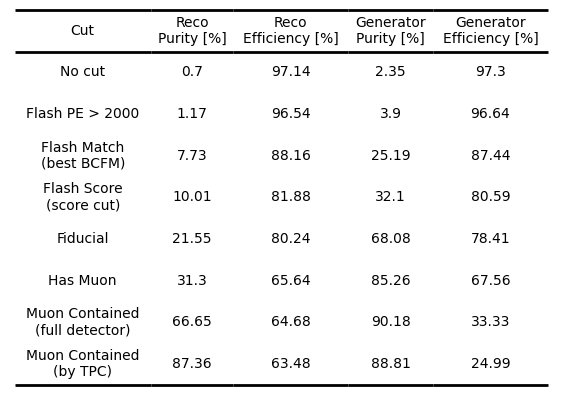

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))
ax, table = create_purity_efficiency_table(
    reco_pur, reco_eff, gen_pur, gen_eff, PAND_CUT_LABELS_CONT, ax, save_name=f'{TABLE_DIR}/pur_eff.csv'
)
#plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.0,1.155),color='gray',alpha=0.9,fontsize=12)
plotters.save_plot('pur_eff_table_cont_pandora',fig=fig,folder_name=f'{PLOT_DIR}/pandora')


#### 3.1.2 Make plots

In [ ]:
SYST_DIR = f'{DATA_DIR}/data/checkpoint8_full/syst' #this should include everything
SYST_DIR

'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint8_full/syst'

In [70]:
# Get binnings from SYST_DIR
if os.path.exists(f'{SYST_DIR}/precut/metadata_detsys/'):
  print(f'Found {SYST_DIR}/precut/metadata_detsys/')
  syst_costheta_bins = np.loadtxt(f'{SYST_DIR}/precut/metadata_detsys/costheta_bins.csv')
  syst_momentum_bins = np.loadtxt(f'{SYST_DIR}/precut/metadata_detsys/momentum_bins.csv')
  syst_momentum_bins_unaltered = syst_momentum_bins.copy()
  syst_momentum_bins[-1] = MAX_PMOM #manually adjust last bin
  syst_bcfm_bins = np.loadtxt(f'{SYST_DIR}/precut/metadata_detsys/bcfm_bins.csv')
  syst_flashpe_bins = np.loadtxt(f'{SYST_DIR}/precut/metadata_detsys/flashpe_bins.csv')
else:
  print(f'No {SYST_DIR}/precut/metadata_detsys/ found')
  syst_costheta_bins = COSTHETA_BINS
  syst_momentum_bins = MOMENTUM_BINS
  syst_momentum_bins_unaltered = syst_momentum_bins.copy()
  syst_momentum_bins[-1] = MAX_PMOM #manually adjust last bin
  syst_bcfm_bins = BCFM_BINS
  syst_flashpe_bins = FLASHPE_BINS
syst_xy_bins = TRACK_XY_BINS
syst_z_bins = TRACK_Z_BINS
syst_length_bins = TRACK_LENGTH_BINS
syst_phi_bins = TRACK_PHI_BINS
syst_theta_bins = TRACK_THETA_BINS

Found /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint8_full/syst/precut/metadata_detsys/


In [71]:
from sbnd.general.utils import get_nperbin
from sbnd.stats import stats

In [72]:
from sbnd.cafclasses.binning import Binning2D
diff_momentum_bins_2d = DIFF_MOMENTUM_BINS_2D
for i,row in enumerate(diff_momentum_bins_2d):
  row[-1] = MAX_PMOM
binning2d = Binning2D(diff_momentum_bins_2d=diff_momentum_bins_2d)

In [73]:
PLOT_DIR

'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint9_interaction_cuts_test3'

In [74]:
from sbnd.detector.definitions import *
#from sbnd.detector.volume import involume, track_cont_tpc1, track_cont_tpc0, coord_columns, enters, point_in_contained
from sbnd.detector.volume import (
    involume, track_cont_tpc0, track_cont_tpc1, track_contained,
    enters, point_in_contained,
)

print(f'PLOT_DIR: {PLOT_DIR}')
# Apply region mask, if it's region 1, 2, or 3, modify the mask and the save dir
# If it's none, continue
MAX_NPFP = 3
npfp_mask = None
REGION_MASK = None
TPC_MASK = None
FV_MASK = None
MIDZ_MASK = None
HIGHX_MASK = None
HIGHY_MASK = None
INVERT_VOLUME = True
x_cathode = X_CATHODE_CM
x_fiducial = X_FIDUCIAL_CM

# z_region masks: canonical FV partition via sbnd.detector.definitions
def get_region_masks(s, x_cathode_cm, x_fiducial_cm):
  vtx = s.data.slc.vertex
  coords = pd.DataFrame({'x': vtx.x, 'y': vtx.y, 'z': vtx.z})
  in_contained = point_in_contained(
    coords, x_cathode_cm=x_cathode_cm, x_fiducial_cm=x_fiducial_cm,
  )
  region1 = in_contained & involume(coords, Z_REGION1)
  region2 = in_contained & involume(coords, Z_REGION2)
  region3 = in_contained & involume(coords, Z_REGION3)
  region_null = in_contained & ~region1 & ~region2 & ~region3
  return region1, region2, region3, region_null

def volume_track_mask(start, end, volume, *, veto_kw, track_kw):
  if INVERT_VOLUME:
    return enters(start, end, volume)
  return track_contained(start, end, **veto_kw, **track_kw)

def volume_folder_suffix(base, mask_id):
  if INVERT_VOLUME:
    return f'_{base}invert{mask_id}'
  return f'_{base}{mask_id}'

REGION_FOLDER_SUFFIX = {1: '_zregion1', 2: '_zregion2', 3: '_zregion3', 4: '_zregion_null'}

from sbnd.plotlibrary import makeplot
from naming import *
#for cuts,folder,categories in zip([PAND_CUTS_CONT,PAND_CUTS],['pandora_cont','pandora_uncont'],[[0],[0,1]]):
#for cuts,folder,categories in zip([PAND_CUTS],['pandora_uncont'],[[0,1]]):
for REGION_MASK in [None]:
  for HIGHY_MASK in [1,None]:#1,2]:
    for x_cathode in [5]:#[5,10]:
      for x_fiducial in [190,180]:#[190,180,170,160]:
        for HIGHX_MASK in [None]:#[1,3]:
          for TPC_MASK in [None]:#[None,0,1]:
            for MIDZ_MASK in [2,None]:
              for npfp_mask in [None,1,2,3]:#[None,1,2,3]:
                _active_veto_masks = [
                  name for name, val in [
                    ('midz', MIDZ_MASK), ('highx', HIGHX_MASK), ('highy', HIGHY_MASK),
                  ] if val is not None
                ]
                if INVERT_VOLUME and len(_active_veto_masks) > 1:
                  print(
                    f'SKIP: multiple volume masks active: {_active_veto_masks} '
                    f'(midz={MIDZ_MASK}, highx={HIGHX_MASK}, highy={HIGHY_MASK})'
                  )
                  continue
                for cuts,folder,categories in zip([cuts_in_chain],['pandora_cont'],[[0]]):
                  # Make spectra for pandora
                  _slcs = slcs 
                  _slc_weights = slc_weights
                  _slc_data = slc_data #Set to slc_data if you want to plot data
                  data_counts = []

                  # Initialize variables outside the loop
                  _data_events = None
                  cut_descriptions = []

                  # Main loop - only copy data when we need to apply cuts
                  for i, cut in enumerate(['precut'] + cuts):
                      print('*' * 70)
                      print(f'cut: {cut}')

                      #Leave it empty
                      cut_descriptions.append('')
                      
                      if cut != 'precut':
                          # Only copy when we need to apply cuts
                          if i == 1:  # First cut application
                              _slcs = [s.copy() for s in slcs]
                              _slc_weights = [w.copy() for w in slc_weights]
                              if _slc_data is not None:
                                  _slc_data = slc_data.copy()
                              else:
                                  _slc_data = None
                          
                          # Apply cuts in batch
                          for s in _slcs:
                              s.apply_cut(cut)
                          
                          if _slc_data is not None:
                              _slc_data.apply_cut(cut)
                              _data_events = len(_slc_data.data)
                              data_counts.append(_data_events)
                              print(f'len(_slc_data): {_data_events}')
                          else:
                              _data_events = None
                      if cut != cuts_in_chain[-1]:# and cut != cuts_in_chain[-2]: 
                        continue
                      else: 
                        print(f' Doing {cut} cut')
                      if REGION_MASK in REGION_FOLDER_SUFFIX:
                        mc_masks = [
                          get_region_masks(s, x_cathode, x_fiducial) for s in _slcs
                        ]
                        data_r1, data_r2, data_r3, data_rnull = get_region_masks(
                          _slc_data, x_cathode, x_fiducial,
                        )
                        region_idx = REGION_MASK - 1

                        print('Before region mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        n_total = len(_slc_data.data)
                        n_r1, n_r2, n_r3 = data_r1.sum(), data_r2.sum(), data_r3.sum()
                        n_rnull = data_rnull.sum()
                        print(
                          f'len(_slc_data.data): {n_total}, '
                          f'r1={n_r1}, r2={n_r2}, r3={n_r3}, null={n_rnull}, '
                          f'r1+r2+r3={n_r1 + n_r2 + n_r3}'
                        )
                        if n_r1 + n_r2 + n_r3 + n_rnull != n_total:
                          print(
                            f'WARNING: {n_total - n_r1 - n_r2 - n_r3 - n_rnull} events '
                            'outside contained FV vertex partition'
                          )

                        pick_data = (data_r1, data_r2, data_r3, data_rnull)[region_idx]
                        _slcs = [
                          CAFSlice(s.data[mask[region_idx]])
                          for s, mask in zip(_slcs, mc_masks)
                        ]
                        _slc_data = CAFSlice(_slc_data.data[pick_data])
                        folder += REGION_FOLDER_SUFFIX[REGION_MASK]

                        print('After region mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        print(f'len(_slc_data.data): {len(_slc_data.data)}')

                      if npfp_mask is not None:
                        print('Before npfp mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        print(f'len(_slc_data.data): {len(_slc_data.data)}')
                        if npfp_mask >= MAX_NPFP:
                          _slcs = [CAFSlice(s.data[s.data.slc.num_primary_particles >= npfp_mask]) for s in _slcs]
                          _slc_data = CAFSlice(_slc_data.data[_slc_data.data.slc.num_primary_particles >= npfp_mask])
                        else:
                          _slcs = [CAFSlice(s.data[s.data.slc.num_primary_particles == npfp_mask]) for s in _slcs]
                          _slc_data = CAFSlice(_slc_data.data[_slc_data.data.slc.num_primary_particles == npfp_mask])
                        folder += f'_npfp{npfp_mask}'
                        print('After npfp mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        print(f'len(_slc_data.data): {len(_slc_data.data)}')

                      # Apply tpc mask
                      if TPC_MASK is not None:
                        if TPC_MASK == 0:
                          tpc_volume = TPC0
                        elif TPC_MASK == 1:
                          tpc_volume = TPC1
                        else:
                          raise ValueError(f'TPC_MASK must be 0 or 1, got {TPC_MASK}')
                          
                        print('Before tpc mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        print(f'len(_slc_data.data): {len(_slc_data.data)}')
                        _slcs = [CAFSlice(s.data[involume(s.data.slc.vertex,tpc_volume)]) for s in _slcs]
                        _slc_data = CAFSlice(_slc_data.data[involume(_slc_data.data.slc.vertex,tpc_volume)])
                        folder += f'_tpc{TPC_MASK}'
                        print('After tpc mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        print(f'len(_slc_data.data): {len(_slc_data.data)}')

                      # Get any cathode modifications
                      track_kw = dict(x_cathode_cm=x_cathode,x_fiducial_cm=x_fiducial)
                      if x_cathode != X_CATHODE_CM: #Don't rename since these are nominal values
                        folder += f'_xc{x_cathode}'
                      if x_fiducial != X_FIDUCIAL_CM: #Don't rename since these are nominal values
                        folder += f'_xf{x_fiducial}'
                      # Apply midz mask
                      if MIDZ_MASK is not None:
                        print('Before midz mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        print(f'len(_slc_data.data): {len(_slc_data.data)}')
                        if MIDZ_MASK == 1:
                          _volume = NOT_FV_MIDZ_LOWY1
                        elif MIDZ_MASK == 2:
                          _volume = NOT_FV_MIDZ_LOWY2
                        elif MIDZ_MASK == 3:
                          _volume = NOT_FV_MIDZ_LOWY3
                        else:
                          raise ValueError(f'MIDZ_MASK must be 1 or 2, got {MIDZ_MASK}')
                        _veto_kw = {'midz_lowy_veto': True, 'midz_lowy_volume': _volume}
                        _masks = [
                          volume_track_mask(s.data.mu.pfp.trk.start, s.data.mu.pfp.trk.end, _volume,
                                            veto_kw=_veto_kw, track_kw=track_kw) for s in _slcs]
                        _slcs = [CAFSlice(s.data[_masks]) for s, _masks in zip(_slcs, _masks)]
                        _mask_data = volume_track_mask(
                          _slc_data.data.mu.pfp.trk.start, _slc_data.data.mu.pfp.trk.end, _volume,
                          veto_kw=_veto_kw, track_kw=track_kw,
                        )
                        _slc_data = CAFSlice(_slc_data.data[_mask_data])
                        
                        folder += volume_folder_suffix('midz', MIDZ_MASK)
                        print('After midz mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        print(f'len(_slc_data.data): {len(_slc_data.data)}')

                      if HIGHX_MASK is not None:
                        print('Before highx mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        print(f'len(_slc_data.data): {len(_slc_data.data)}')
                        
                        if HIGHX_MASK == 1:
                          _volume = NOT_FV_HIGHX_LOWZ1
                        elif HIGHX_MASK == 2:
                          _volume = NOT_FV_HIGHX_LOWZ2
                        elif HIGHX_MASK == 3:
                          _volume = NOT_FV_HIGHX_LOWZ3
                        elif HIGHX_MASK == 4:
                          _volume = NOT_FV_HIGHX_LOWZ4
                        else:
                          raise ValueError(f'HIGHX_MASK must be 1, 2, 3, or 4, got {HIGHX_MASK}')
                        _veto_kw = {'highx_lowz_veto': True, 'highx_lowz_volume': _volume}
                        _masks = [
                          volume_track_mask(s.data.mu.pfp.trk.start, s.data.mu.pfp.trk.end, _volume,
                                            veto_kw=_veto_kw, track_kw=track_kw) for s in _slcs]
                        _slcs = [CAFSlice(s.data[_masks]) for s, _masks in zip(_slcs, _masks)]
                        _mask_data = volume_track_mask(
                          _slc_data.data.mu.pfp.trk.start, _slc_data.data.mu.pfp.trk.end, _volume,
                          veto_kw=_veto_kw, track_kw=track_kw,
                        )
                        _slc_data = CAFSlice(_slc_data.data[_mask_data])
                        
                        folder += volume_folder_suffix('highx', HIGHX_MASK)
                        print('After highx mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        print(f'len(_slc_data.data): {len(_slc_data.data)}')

                      if HIGHY_MASK is not None:
                        print('Before highy lowz mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        print(f'len(_slc_data.data): {len(_slc_data.data)}')

                        if HIGHY_MASK == 1:
                          _volume = NOT_FV_HIGHY_LOWZ1
                        elif HIGHY_MASK == 2:
                          _volume = NOT_FV_HIGHY_LOWZ2
                        else:
                          raise ValueError(f'HIGHY_MASK must be 1 or 2, got {HIGHY_MASK}')
                        _veto_kw = {'highy_lowz_veto': True, 'highy_lowz_volume': _volume}
                        _masks = [
                          volume_track_mask(s.data.mu.pfp.trk.start, s.data.mu.pfp.trk.end, _volume,
                                            veto_kw=_veto_kw, track_kw=track_kw) for s in _slcs]
                        _slcs = [CAFSlice(s.data[_masks]) for s, _masks in zip(_slcs, _masks)]
                        _mask_data = volume_track_mask(
                          _slc_data.data.mu.pfp.trk.start, _slc_data.data.mu.pfp.trk.end, _volume,
                          veto_kw=_veto_kw, track_kw=track_kw,
                        )
                        _slc_data = CAFSlice(_slc_data.data[_mask_data])

                        folder += volume_folder_suffix('highylowz', HIGHY_MASK)
                        print('After highy lowz mask lengths')
                        for s in _slcs:
                          print(f' - len(s.data): {len(s.data)}')
                        print(f'len(_slc_data.data): {len(_slc_data.data)}')
                      print(f'folder: {folder}')
                      
                      # Pre-compute data access
                      total_events = np.sum([len(_s.data) for _s in _slcs])
                      print(f'len(_slcs): {total_events}')
                      
                      # Muon information
                      costheta = [s.data.mu.pfp.trk.costheta for s in _slcs]
                      momentum = [s.data.mu.pfp.trk.P.p_muon for s in _slcs]
                      bin2d = [s.data.bin.differential for s in _slcs]
                      length = [s.data.mu.pfp.trk.len for s in _slcs]

                      # -start and end points
                      start_x = [s.data.mu.pfp.trk.start.x for s in _slcs]
                      start_y = [s.data.mu.pfp.trk.start.y for s in _slcs]
                      start_z = [s.data.mu.pfp.trk.start.z for s in _slcs]
                      end_x = [s.data.mu.pfp.trk.end.x for s in _slcs]
                      end_y = [s.data.mu.pfp.trk.end.y for s in _slcs]
                      end_z = [s.data.mu.pfp.trk.end.z for s in _slcs]

                      # -phi and theta
                      phi = [s.data.mu.pfp.trk.phi for s in _slcs]
                      theta = [s.data.mu.pfp.trk.theta for s in _slcs]

                      # -direction
                      direction_x = [s.data.mu.pfp.trk.dir.x for s in _slcs]
                      direction_y = [s.data.mu.pfp.trk.dir.y for s in _slcs]
                      direction_z = [s.data.mu.pfp.trk.dir.z for s in _slcs]

                      # Interaction information
                      opt0_score = [s.data.slc.opt0.score for s in _slcs]
                      opt0_time = [s.data.slc.opt0.time for s in _slcs]
                      bcfm_score = [s.data.slc.barycenterFM.score for s in _slcs]
                      nu_score = [s.data.slc.nu_score for s in _slcs]
                      flashpe = [s.data.slc.barycenterFM.flashPEs for s in _slcs]

                      # -interaction vertex
                      interaction_x = [s.data.slc.vertex.x for s in _slcs]
                      interaction_y = [s.data.slc.vertex.y for s in _slcs]
                      interaction_z = [s.data.slc.vertex.z for s in _slcs]

                      # Get weights
                      _weights = [s.data.genweight for s in _slcs]

                      # Get data
                      if _slc_data is not None:
                        # Muon information
                        costheta_data = _slc_data.data.mu.pfp.trk.costheta
                        momentum_data = _slc_data.data.mu.pfp.trk.P.p_muon
                        length_data = _slc_data.data.mu.pfp.trk.len
                        bin2d_data = _slc_data.data.bin.differential

                        # -start and end points
                        start_x_data = _slc_data.data.mu.pfp.trk.start.x
                        start_y_data = _slc_data.data.mu.pfp.trk.start.y
                        start_z_data = _slc_data.data.mu.pfp.trk.start.z
                        end_x_data = _slc_data.data.mu.pfp.trk.end.x
                        end_y_data = _slc_data.data.mu.pfp.trk.end.y
                        end_z_data = _slc_data.data.mu.pfp.trk.end.z

                        # -phi and theta
                        phi_data = _slc_data.data.mu.pfp.trk.phi
                        theta_data = _slc_data.data.mu.pfp.trk.theta

                        # -direction
                        direction_x_data = _slc_data.data.mu.pfp.trk.dir.x
                        direction_y_data = _slc_data.data.mu.pfp.trk.dir.y
                        direction_z_data = _slc_data.data.mu.pfp.trk.dir.z

                        # Interaction information
                        opt0_score_data = _slc_data.data.slc.opt0.score
                        opt0_time_data = _slc_data.data.slc.opt0.time
                        bcfm_score_data = _slc_data.data.slc.barycenterFM.score
                        nu_score_data = _slc_data.data.slc.nu_score
                        flashpe_data = _slc_data.data.slc.barycenterFM.flashPEs
                        # -interaction vertex
                        interaction_x_data = _slc_data.data.slc.vertex.x
                        interaction_y_data = _slc_data.data.slc.vertex.y
                        interaction_z_data = _slc_data.data.slc.vertex.z
                        
                      else: #Set all to None if no data
                        costheta_data = None
                        momentum_data = None
                        length_data = None
                        bin2d_data = None
                        start_x_data = None
                        start_y_data = None
                        start_z_data = None
                        end_x_data = None
                        end_y_data = None
                        end_z_data = None
                        phi_data = None
                        theta_data = None
                        direction_x_data = None
                        direction_y_data = None
                        direction_z_data = None
                        opt0_score_data = None
                        opt0_time_data = None
                        bcfm_score_data = None
                        nu_score_data = None
                        flashpe_data = None
                        interaction_x_data = None
                        interaction_y_data = None
                        interaction_z_data = None
                        nu_score_data = None
                      # Use pre-computed cut description
                      cut_desc = cut_descriptions[i]

                      # Get frac uncertainty from SYST_DIR
                      if os.path.exists(f'{SYST_DIR}/{cut}/') or os.path.exists(f'{SYST_DIR}/full/'):
                        if cut == cuts_in_chain[-1]:
                          syst_folder = f'{SYST_DIR}/full/total/'#.replace('checkpoint7_full','checkpoint7_full_contsig')
                          if not os.path.exists(syst_folder):
                            raise FileNotFoundError(f'{syst_folder} does not exist')
                        else:
                          syst_folder = f'{SYST_DIR}/{cut}/total/'
                        syst_var_folder = syst_folder#f'{SYST_DIR}/{cut}/total/' #this is alwyas the same for bcfm, flashpe
                        print(' - Loading syst from: ', syst_folder)
                        print(' - Loading var syst from: ', syst_var_folder)
                        syst_costheta_frac = np.loadtxt(f'{syst_folder}/costheta_event_fracunc.csv')
                        syst_momentum_frac = np.loadtxt(f'{syst_folder}/momentum_event_fracunc.csv')
                        syst_differential_frac = np.loadtxt(f'{syst_folder}/differential_event_fracunc.csv')
                        syst_bcfm_frac = np.loadtxt(f'{syst_var_folder}/bcfm_event_fracunc.csv')
                        syst_flashpe_frac = np.loadtxt(f'{syst_var_folder}/flashpe_event_fracunc.csv')
                        #Checkpoint 7 and beyond
                        syst_startx_frac = np.loadtxt(f'{syst_var_folder}/startx_event_fracunc.csv')
                        syst_starty_frac = np.loadtxt(f'{syst_var_folder}/starty_event_fracunc.csv')
                        syst_startz_frac = np.loadtxt(f'{syst_var_folder}/startz_event_fracunc.csv')
                        syst_endx_frac = np.loadtxt(f'{syst_var_folder}/endx_event_fracunc.csv')
                        syst_endy_frac = np.loadtxt(f'{syst_var_folder}/endy_event_fracunc.csv')
                        syst_endz_frac = np.loadtxt(f'{syst_var_folder}/endz_event_fracunc.csv')
                        syst_phi_frac = np.loadtxt(f'{syst_var_folder}/phi_event_fracunc.csv')
                        syst_theta_frac = np.loadtxt(f'{syst_var_folder}/theta_event_fracunc.csv')
                        syst_length_frac = np.loadtxt(f'{syst_var_folder}/length_event_fracunc.csv')
                        syst_vtxx_frac = np.loadtxt(f'{syst_var_folder}/vtxx_event_fracunc.csv')
                        syst_vtxy_frac = np.loadtxt(f'{syst_var_folder}/vtyy_event_fracunc.csv')
                        syst_vtxz_frac = np.loadtxt(f'{syst_var_folder}/vtzx_event_fracunc.csv')
                        
                        
                        # Get covariance matrix from DET_SYST_DIR
                        syst_costheta_cov = np.loadtxt(f'{syst_folder}/costheta_event_cov.csv')
                        syst_momentum_cov = np.loadtxt(f'{syst_folder}/momentum_event_cov.csv')
                        syst_differential_cov = np.loadtxt(f'{syst_folder}/differential_event_cov.csv')
                        syst_bcfm_cov = np.loadtxt(f'{syst_var_folder}/bcfm_event_cov.csv')
                        syst_flashpe_cov = np.loadtxt(f'{syst_var_folder}/flashpe_event_cov.csv')
                        # Checkpoint 7 and beyond
                        syst_startx_cov = np.loadtxt(f'{syst_var_folder}/startx_event_cov.csv')
                        syst_starty_cov = np.loadtxt(f'{syst_var_folder}/starty_event_cov.csv')
                        syst_startz_cov = np.loadtxt(f'{syst_var_folder}/startz_event_cov.csv')
                        syst_endx_cov = np.loadtxt(f'{syst_var_folder}/endx_event_cov.csv')
                        syst_endy_cov = np.loadtxt(f'{syst_var_folder}/endy_event_cov.csv')
                        syst_endz_cov = np.loadtxt(f'{syst_var_folder}/endz_event_cov.csv')
                        syst_phi_cov = np.loadtxt(f'{syst_var_folder}/phi_event_cov.csv')
                        syst_theta_cov = np.loadtxt(f'{syst_var_folder}/theta_event_cov.csv')
                        syst_length_cov = np.loadtxt(f'{syst_var_folder}/length_event_cov.csv')
                        syst_vtxx_cov = np.loadtxt(f'{syst_var_folder}/vtxx_event_cov.csv')
                        syst_vtxy_cov = np.loadtxt(f'{syst_var_folder}/vtyy_event_cov.csv')
                        syst_vtxz_cov = np.loadtxt(f'{syst_var_folder}/vtzx_event_cov.csv')
                        
                      else: #Set everything to None if no syst folder
                        print(f'No syst folder found for {SYST_DIR}/{cut}/ or {SYST_DIR}/full/')
                        syst_costheta_frac = None
                        syst_momentum_frac = None
                        syst_differential_frac = None
                        syst_bcfm_frac = None
                        syst_flashpe_frac = None
                        syst_startx_frac = None
                        syst_starty_frac = None
                        syst_startz_frac = None
                        syst_endx_frac = None
                        syst_endy_frac = None
                        syst_endz_frac = None
                        syst_phi_frac = None
                        syst_theta_frac = None
                        syst_length_frac = None
                        syst_vtxx_frac = None
                        syst_vtyy_frac = None
                        syst_vtzx_frac = None
                        
                        syst_costheta_cov = None
                        syst_momentum_cov = None
                        syst_differential_cov = None
                        syst_bcfm_cov = None
                        syst_flashpe_cov = None
                        syst_startx_cov = None
                        syst_starty_cov = None
                        syst_startz_cov = None
                        syst_endx_cov = None
                        syst_endy_cov = None
                        syst_endz_cov = None
                        syst_phi_cov = None
                        syst_theta_cov = None
                        syst_length_cov = None
                        syst_vtxx_cov = None
                        syst_vtyy_cov = None
                        syst_vtzx_cov = None

                      syst_label = r'Total'
                      
                      # Create plots for both density and counts
                      dens_list = [False]#[False,'stackfrac'] if cut == PAND_CUTS_CONT[-1] else [False]
                      for dens in dens_list:
                        for scale in [False]:#,True]:
                          if dens == False:
                            plot_dir = f'{PLOT_DIR}/{folder}/{cut}/counts'
                          if scale == True: #overwrite the plot_dir
                            plot_dir = f'{PLOT_DIR}/{folder}/{cut}/scaled'
                          if dens and scale: continue #These don't go together
                          if dens == 'stackfrac':
                            if scale: continue #These don't go together
                            dens_name = '_stackfrac'
                          else:
                            dens_name = ''
                          #print(f'dens: {dens}, scale: {scale}')
                          #2D momentum and costheta (in binID space) - BG only
                          # fig,ax = makeplot.create_hist(
                          #   bin2d[2:], labels[2:], dens,
                          #   xlabel=r'Reconstructed Bin ID',
                          #   label=INTERNAL_LABEL,
                          #   colors=colors[2:],
                          #   weights=_weights[2:],
                          #   bins=binning2d.differential_edges,
                          #   cut=cut,
                          #   savename=f'differential_binid_bgonly_{cut}cut',
                          #   plot_dir=plot_dir
                          # )

                          #2D momentum and costheta - BG only
                          # figs,axs = makeplot.create_differential_stack(
                          #   bin2d[2:], labels[2:], binning2d=binning2d,
                          #   weights=_weights[2:],
                          #   xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
                          #   label=INTERNAL_LABEL,
                          #   pot_label=POT_LABEL,
                          #   colors=colors[2:],
                          #   savename=f'differential_bgonly_{cut}cut',
                          #   plot_dir=plot_dir,
                          # )

                          # -Costheta syst - BG only
                          # fig, ax = makeplot.create_hist(
                          #     costheta[2:], labels[2:], dens,
                          #     #data_series=costheta_data,
                          #     #cut_desc=cut_desc,
                          #     xlabel=r'Reconstructed $\cos\theta_{\mu}$',
                          #     label=INTERNAL_LABEL,
                          #     colors=colors[2:],
                          #     weights=_weights[2:],
                          #     bins=syst_costheta_bins,
                          #     cut=cut,
                          #     savename=f'costhetamu_syst_bgonly_{cut}cut',
                          #     plot_dir=plot_dir
                          # )

                          # -Momentum syst - BG only
                          # fig, ax = makeplot.create_hist(
                          #     momentum[2:], labels[2:], dens,
                          #     #cut_desc=cut_desc,
                          #     xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
                          #     label=INTERNAL_LABEL,
                          #     colors=colors[2:],
                          #     weights=_weights[2:],
                          #     bins=syst_momentum_bins_unaltered,
                          #     bin_centers=(syst_momentum_bins[:-1] + syst_momentum_bins[1:])/2,
                          #     cut=cut,
                          #     plot_dir=plot_dir,
                          #     pot_label=POT_LABEL,
                          #     scale_data=scale,
                          #     show_counts=not scale
                          # )

                          #Customize plot
                          # ax.set_xlim(0, MAX_PMOM)
                          # plotters.save_plot(f'pmu_syst_bgonly_{cut}cut',fig=fig,folder_name=plot_dir)
                          # plt.close(fig)

                          # ------ PLOTS AFTER THIS HAVE DATA SO CAN'T DO STACKFRAC

                          if dens == 'stackfrac':
                            continue

                          
                          #2D momentum and costheta
                          figs,axs = makeplot.create_differential_stack(
                            bin2d, labels, binning2d=binning2d,
                            data_ids=bin2d_data,
                            weights=_weights,
                            xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
                            label=INTERNAL_DATA_LABEL,
                            frac_unc=syst_differential_frac[1:] if not scale else None, #Remove null bin
                            cov=syst_differential_cov[1:,1:] if not scale else None, #Remove null bin
                            colors=colors,
                            yerr_label=syst_label if not scale else 'Stat',
                            pot_label=POT_LABEL,
                            scale_data=scale,
                            show_counts=not scale,
                            savename=f'differential_{cut}cut',
                            plot_dir=plot_dir
                          )

                          #2D momentum and costheta (in binID space)
                          fig,ax,ax2 = makeplot.create_hist_dataratio(
                            bin2d, labels, dens,
                            data_series=bin2d_data,
                            ##cut_desc=cut_desc,
                            xlabel=r'Reconstructed Bin ID',
                            label=INTERNAL_DATA_LABEL,
                            colors=colors,
                            weights=_weights,
                            bins=binning2d.differential_edges,
                            cut=cut,
                            savename=f'differential_binid_{cut}cut',
                            plot_dir=plot_dir,
                            scale_data=scale,
                            show_counts=not scale,
                            yerr=syst_differential_frac if not scale else None,
                            yerr_label=syst_label if not scale else 'Stat',
                            pot_label=POT_LABEL,
                            cov=syst_differential_cov if not scale else None
                          )
                  #         break
                  #     break
                  # break

                          #Muon infomation
                          #-Costheta
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              costheta, labels, dens,
                              data_series=costheta_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\cos\theta_{\mu}$',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=np.arange(-1, 1.1, 0.1),
                              cut=cut,
                              savename=f'costhetamu_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # -FlashPE syst
                          # for k in range(1,len(syst_flashpe_bins)-1):
                          #   print('+'*50,f' k: {k} ', '+'*50)
                          #   cov = stats.keep_top_eigenvalues_cov(syst_flashpe_cov, k, diagnose=True)
                          #   fig, ax, ax2 = makeplot.create_hist_dataratio(
                          #       flashpe, labels, dens,
                          #       data_series=flashpe_data,
                          #       #cut_desc=cut_desc,
                          #       xlabel=r'Flash PE',
                          #       label=INTERNAL_DATA_LABEL,
                          #       colors=colors,
                          #       weights=_weights,
                          #       bins=syst_flashpe_bins,
                          #       cut=cut,
                          #       savename=f'flashpe_syst_k{k}',
                          #       plot_dir=plot_dir,
                          #       show_counts=not dens,
                          #       yerr=syst_flashpe_frac,
                          #       yerr_label=syst_label,
                          #       cov=cov
                          #   )
                          #   plt.title(f'k: {k}')
                          #   plt.imshow(cov-syst_flashpe_cov)
                          #   plt.colorbar()
                          #   plt.show()


                          # fig, ax, ax2 = makeplot.create_hist_dataratio(
                          #     flashpe, labels, dens,
                          #     data_series=flashpe_data,
                          #     #cut_desc=cut_desc,
                          #     xlabel=r'Flash PE',
                          #     label=INTERNAL_DATA_LABEL,
                          #     colors=colors,
                          #     weights=_weights,
                          #     bins=syst_flashpe_bins,
                          #     cut=cut,
                          #     savename='flashpe_syst_diag',
                          #     plot_dir=plot_dir,
                          #     show_counts=not dens,
                          #     yerr=syst_flashpe_frac,
                          #     yerr_label=syst_label,
                          #     cov=np.diag(syst_flashpe_cov)*np.eye(len(syst_flashpe_cov))
                          # )
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              flashpe, labels, dens,
                              data_series=flashpe_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Flash PE',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_flashpe_bins,
                              cut=cut,
                              savename=f'flashpe_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              yerr=syst_flashpe_frac if not scale else None,
                              pot_label=POT_LABEL,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_flashpe_cov if not scale else None
                          )

                          # fig, ax, ax2 = makeplot.create_hist_dataratio(
                          #     flashpe, labels, dens,
                          #     data_series=flashpe_data,
                          #     #cut_desc=cut_desc,
                          #     xlabel=r'Flash PE',
                          #     label=INTERNAL_DATA_LABEL,
                          #     colors=colors,
                          #     weights=_weights,
                          #     bins=syst_flashpe_bins,
                          #     cut=cut,
                          #     #savename='flashpe_syst',
                          #     plot_dir=plot_dir,
                          #     show_counts=not dens,
                          #     yerr=syst_flashpe_frac,
                          #     yerr_label=syst_label,
                          #     cov=syst_flashpe_cov_shrunk
                          # )
                            
                  #         break
                  #     break
                  # break

                          # -Costheta syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              costheta, labels, dens,
                              data_series=costheta_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\cos\theta_{\mu}$',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_costheta_bins,
                              cut=cut,
                              savename=f'costhetamu_syst_{cut}cut',
                              plot_dir=plot_dir,
                              yerr=syst_costheta_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              cov=syst_costheta_cov if not scale else None,
                          )

                          # -Start z
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              start_z, labels, dens,
                              data_series=start_z_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Start Z [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_z_bins,
                              cut=cut,
                              savename=f'reco_start_z_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL
                          )

                          # - Start z syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              start_z, labels, dens,
                              data_series=start_z_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Start Z [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_z_bins,
                              cut=cut,
                              savename=f'reco_start_z_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_startz_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_startz_cov if not scale else None
                          )
                          
                      #     break
                      # break
                          
                          #-Momentum
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              momentum, labels, dens,
                              data_series=momentum_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=np.arange(0, 3.1, 0.1),
                              cut=cut,
                              savename=f'pmu_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL
                          )

                          # -Momentum syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              momentum, labels, dens,
                              data_series=momentum_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_momentum_bins_unaltered,
                              bin_centers=(syst_momentum_bins[:-1] + syst_momentum_bins[1:])/2,
                              cut=cut,
                              #savename=f'pmu_syst_{cut}cut',
                              plot_dir=plot_dir,
                              yerr=syst_momentum_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              cov=syst_momentum_cov if not scale else None
                          )
                          #Customize plot
                          ax.set_xlim(0, MAX_PMOM)
                          plotters.save_plot(f'pmu_syst_{cut}cut',fig=fig,folder_name=plot_dir)
                          plt.close(fig)

                          # -Momentum syst - restrict p range
                          # fig, ax, ax2 = makeplot.create_hist_dataratio(
                          #     momentum, labels, dens,
                          #     data_series=momentum_data,
                          #     #cut_desc=cut_desc,
                          #     xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
                          #     label=INTERNAL_DATA_LABEL,
                          #     colors=colors,
                          #     weights=_weights,
                          #     bins=syst_momentum_bins_unaltered[:-3],
                          #     bin_centers=((syst_momentum_bins[:-1] + syst_momentum_bins[1:])/2)[:-3],
                          #     cut=cut,
                          #     #savename=f'pmu_syst_{cut}cut',
                          #     plot_dir=plot_dir,
                          #     yerr=syst_momentum_frac[:-3] if not scale else None,
                          #     yerr_label=syst_label if not scale else 'Stat',
                          #     scale_data=scale,
                          #     show_counts=not scale,
                          #     pot_label=POT_LABEL,
                          #     cov=syst_momentum_cov[:-3,:-3] if not scale else None
                          # )
                          # #Customize plot
                          # ax.set_xlim(0, 1.)
                          # plotters.save_plot(f'pmu_syst_{cut}cut_limit_prange',fig=fig,folder_name=plot_dir)
                          # plt.close(fig)
                          

                          # -Length
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              length, labels, dens,
                              data_series=length_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Length [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_length_bins,
                              cut=cut,
                              savename=f'reco_length_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # - Length syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              length, labels, dens,
                              data_series=length_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Length [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_length_bins,
                              cut=cut,
                              savename=f'reco_length_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_length_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_length_cov if not scale else None
                          )

                          # -Start x
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              start_x, labels, dens,
                              data_series=start_x_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Start X [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_start_x_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                          )

                          # - Start x syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              start_x, labels, dens,
                              data_series=start_x_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Start X [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_start_x_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_startx_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_startx_cov if not scale else None
                          )
                          

                          # -Start y
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              start_y, labels, dens,
                              data_series=start_y_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Start Y [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_start_y_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # - Start y syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              start_y, labels, dens,
                              data_series=start_y_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Start Y [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_start_y_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_starty_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_starty_cov if not scale else None
                          )

                          # -End x
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              end_x, labels, dens,
                              data_series=end_x_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ End X [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_end_x_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # -End x syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              end_x, labels, dens,
                              data_series=end_x_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ End X [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_end_x_syst_{cut}cut',
                              plot_dir=plot_dir, 
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_endx_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_endx_cov if not scale else None
                          )
                          
                          # -End y
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              end_y, labels, dens,
                              data_series=end_y_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ End Y [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_end_y_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # - End y syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              end_y, labels, dens,
                              data_series=end_y_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ End Y [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_end_y_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_endy_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_endy_cov if not scale else None
                          )

                          # -End z
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              end_z, labels, dens,
                              data_series=end_z_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ End Z [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_z_bins,
                              cut=cut,
                              savename=f'reco_end_z_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # - End z syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              end_z, labels, dens,
                              data_series=end_z_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ End Z [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_z_bins,
                              cut=cut,
                              savename=f'reco_end_z_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_endz_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_endz_cov if not scale else None
                          )

                          # -Direction x
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              direction_x, labels, dens,
                              data_series=direction_x_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Direction X',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=np.arange(-1, 1.5, 0.1),
                              cut=cut,
                              savename=f'reco_direction_x_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # -Direction y
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              direction_y, labels, dens,
                              data_series=direction_y_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Direction Y',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=np.arange(-1, 1.5, 0.1),
                              cut=cut,
                              savename=f'reco_direction_y_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # -Direction z
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              direction_z, labels, dens,
                              data_series=direction_z_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed $\mu$ Direction Z',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=np.arange(-1, 1.5, 0.1),
                              cut=cut,
                              savename=f'reco_direction_z_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # -Interaction x
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              interaction_x, labels, dens,
                              data_series=interaction_x_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed Interaction X [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_interaction_x_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # - Interaction x syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              interaction_x, labels, dens,
                              data_series=interaction_x_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed Interaction X [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_interaction_x_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_vtxx_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_vtxx_cov if not scale else None
                          )
                          
                          # -Interaction y
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              interaction_y, labels, dens,
                              data_series=interaction_y_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed Interaction Y [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_interaction_y_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # - Interaction y syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              interaction_y, labels, dens,
                              data_series=interaction_y_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed Interaction Y [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_xy_bins,
                              cut=cut,
                              savename=f'reco_interaction_y_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_vtxy_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_vtxy_cov if not scale else None
                          )

                          # -Interaction z
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              interaction_z, labels, dens,
                              data_series=interaction_z_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed Interaction Z [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_z_bins,
                              cut=cut,
                              savename=f'reco_interaction_z_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # - Interaction z syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              interaction_z, labels, dens,
                              data_series=interaction_z_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Reconstructed Interaction Z [cm]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_z_bins,
                              cut=cut,
                              savename=f'reco_interaction_z_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_vtxz_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_vtxz_cov if not scale else None
                          )   

                          # -Opt0 score
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              opt0_score, labels, dens,
                              data_series=opt0_score_data,
                              #cut_desc=cut_desc,
                              xlabel=r'OpT0 Score',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=np.logspace(-1,7,140),
                              cut=cut,
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )
                          #Customize plot
                          ax.set_xscale('log')
                          plotters.save_plot(f'opt0_score_{cut}cut',fig=fig,folder_name=plot_dir)
                          plt.close(fig)

                          # - Opt0 score syst
                          # fig, ax, ax2 = makeplot.create_hist_dataratio(
                          #     opt0_score, labels, dens,
                          #     data_series=opt0_score_data,
                          #     #cut_desc=cut_desc,
                          #     xlabel=r'OpT0 Score',
                          #     label=INTERNAL_DATA_LABEL,
                          #     colors=colors,
                          #     weights=_weights,
                          #     bins=syst_opt0_bins,
                          #     cut=cut,
                          #     plot_dir=plot_dir,
                          #     yerr=syst_opt0_frac,
                          #     yerr_label=syst_label,
                          #     show_counts=not dens
                          # )
                          # ax.set_xscale('log')
                          # plotters.save_plot('opt0_score_syst',fig=fig,folder_name=plot_dir)
                          # plt.close(fig)

                          # -Opt0 time
                          # fig, ax, ax2 = makeplot.create_hist_dataratio(
                          #     opt0_time, labels, dens,
                          #     data_series=opt0_time_data,
                          #     #cut_desc=cut_desc,
                          #     xlabel=r'Opt0 Time [ns]',
                          #     label=INTERNAL_DATA_LABEL,
                          #     colors=colors,
                          #     weights=_weights,
                          #     bins=np.arange(-10, 10.5, 0.5),
                          #     cut=cut,
                          #     savename='opt0_time',
                          #     plot_dir=plot_dir,
                          #     show_counts=not dens
                          # )

                          # -BarycenterFM score
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              bcfm_score, labels, dens,
                              data_series=bcfm_score_data,
                              #cut_desc=cut_desc,
                              xlabel=r'BarycenterFM Score',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=np.arange(0,1.1,0.025),
                              cut=cut,
                              savename=f'bcfm_score_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # -BarycenterFM score zoom
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              bcfm_score, labels, dens,
                              data_series=bcfm_score_data,
                              #cut_desc=cut_desc,
                              xlabel=r'BarycenterFM Score',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=np.arange(0.025,1.1,0.025),
                              cut=cut,
                              savename=f'bcfm_score_zoom_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # -BarycenterFM score syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              bcfm_score, labels, dens,
                              data_series=bcfm_score_data,
                              #cut_desc=cut_desc,
                              xlabel=r'BarycenterFM Score',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_bcfm_bins,
                              cut=cut,
                              savename=f'bcfm_score_syst_{cut}cut',
                              plot_dir=plot_dir,
                              yerr=syst_bcfm_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              cov=syst_bcfm_cov if not scale else None,
                          )

                          # -BarycenterFM score zoom syst
                          # fig, ax, ax2 = makeplot.create_hist_dataratio(
                          #     bcfm_score, labels, dens,
                          #     data_series=bcfm_score_data,
                          #     #cut_desc=cut_desc,
                          #     xlabel=r'BarycenterFM Score',
                          #     label=INTERNAL_DATA_LABEL,
                          #     colors=colors,
                          #     weights=_weights,
                          #     bins=syst_bcfm_bins[1:],
                          #     cut=cut,
                          #     savename=f'bcfm_score_syst_zoom_{cut}cut',
                          #     plot_dir=plot_dir,
                          #     yerr=syst_bcfm_frac[1:] if not scale else None,
                          #     yerr_label=syst_label if not scale else 'Stat',
                          #     scale_data=scale,
                          #     show_counts=not scale,
                          #     pot_label=POT_LABEL,
                          #     cov=syst_bcfm_cov[1:,1:] if not scale else None,
                          # )
                              
                          # -Nu score
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              nu_score, labels, dens,
                              data_series=nu_score_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Nu Score',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=np.arange(-1,1.1,0.05),
                              cut=cut,
                              savename=f'nu_score_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # -Nu score zoom
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              nu_score, labels, dens,
                              data_series=nu_score_data,
                              #cut_desc=cut_desc,
                              xlabel=r'Nu Score',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=np.arange(0,1.1,0.025),
                              cut=cut,
                              savename=f'nu_score_zoom_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # -Nu score syst
                          # fig, ax, ax2 = makeplot.create_hist_dataratio(
                          #     nu_score, labels, dens,
                          #     data_series=nu_score_data,
                          #     #cut_desc=cut_desc,
                          #     xlabel=r'Nu Score',
                          #     label=INTERNAL_DATA_LABEL,
                          #     colors=colors,
                          #     weights=_weights,
                          #     bins=syst_nuscore_bins,
                          #     cut=cut,
                          #     savename='nu_score_syst',
                          #     plot_dir=plot_dir,
                          #     yerr=syst_nuscore_frac,
                          #     yerr_label=syst_label,
                          #     show_counts=not dens
                          # )

                          # # -Nu score syst zoom
                          # fig, ax, ax2 = makeplot.create_hist_dataratio(
                          #     nu_score, labels, dens,
                          #     data_series=nu_score_data,
                          #     #cut_desc=cut_desc,
                          #     xlabel=r'Nu Score',
                          #     label=INTERNAL_DATA_LABEL,
                          #     colors=colors,
                          #     weights=_weights,
                          #     bins=syst_nuscore_bins[int(len(syst_nuscore_bins)/2):],
                          #     cut=cut,
                          #     savename='nu_score_syst_zoom',
                          #     plot_dir=plot_dir,
                          #     yerr=syst_nuscore_frac[int(len(syst_nuscore_bins)/2):],
                          #     yerr_label=syst_label,
                          #     show_counts=not dens
                          # )

                          # Phi
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              phi, labels, dens,
                              data_series=phi_data,
                              xlabel=r'$\phi_\mu$ [rad]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_phi_bins,
                              cut=cut,
                              savename=f'phi_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # Phi syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              phi, labels, dens,
                              data_series=phi_data,
                              xlabel=r'$\phi_\mu$ [rad]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_phi_bins,
                              cut=cut,
                              savename=f'phi_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_phi_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_phi_cov if not scale else None
                          )   

                          # Theta
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              theta, labels, dens,
                              data_series=theta_data,
                              xlabel=r'$\theta_\mu$ [rad]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_theta_bins,
                              cut=cut,
                              savename=f'theta_{cut}cut',
                              plot_dir=plot_dir,
                              pot_label=POT_LABEL,
                              scale_data=scale,
                              show_counts=not scale
                          )

                          # Theta syst
                          fig, ax, ax2 = makeplot.create_hist_dataratio(
                              theta, labels, dens,
                              data_series=theta_data,
                              xlabel=r'$\theta_\mu$ [rad]',
                              label=INTERNAL_DATA_LABEL,
                              colors=colors,
                              weights=_weights,
                              bins=syst_theta_bins,
                              cut=cut,
                              savename=f'theta_syst_{cut}cut',
                              plot_dir=plot_dir,
                              scale_data=scale,
                              show_counts=not scale,
                              pot_label=POT_LABEL,
                              yerr=syst_theta_frac if not scale else None,
                              yerr_label=syst_label if not scale else 'Stat',
                              cov=syst_theta_cov if not scale else None
                          )
                              

                  #         break
                  #     break
                  # break


PLOT_DIR: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint9_interaction_cuts_test3
SKIP: multiple volume masks active: ['midz', 'highy'] (midz=2, highx=None, highy=1)
SKIP: multiple volume masks active: ['midz', 'highy'] (midz=2, highx=None, highy=1)
SKIP: multiple volume masks active: ['midz', 'highy'] (midz=2, highx=None, highy=1)
SKIP: multiple volume masks active: ['midz', 'highy'] (midz=2, highx=None, highy=1)
**********************************************************************
cut: precut
**********************************************************************
cut: fv


Applied cut on key: cut.fv (102,900 --> 102,395)
Applied cut on key: cut.fv (268,089 --> 259,471)
Applied cut on key: cut.fv (136,659 --> 27,874)
Applied cut on key: cut.fv (227,396 --> 33,950)
Applied cut on key: cut.fv (3,744 --> 2,869)
Applied cut on key: cut.fv (89,209 --> 69,231)
Applied cut on key: cut.fv (624,123 --> 69,031)
Applied cut on key: cut.fv (54,387 --> 25,391)
len(_slc_data): 25391
**********************************************************************
cut: muon
Applied cut on key: cut.muon (102,395 --> 102,359)
Applied cut on key: cut.muon (259,471 --> 209,473)
Applied cut on key: cut.muon (27,874 --> 5,905)
Applied cut on key: cut.muon (33,950 --> 18,917)
Applied cut on key: cut.muon (2,869 --> 384)
Applied cut on key: cut.muon (69,231 --> 9,127)
Applied cut on key: cut.muon (69,031 --> 45,397)
Applied cut on key: cut.muon (25,391 --> 16,726)
len(_slc_data): 16726
**********************************************************************
cut: cont_full
Applied cut on key

In [ ]:
# Plot ratio of data/mc for x vertex for each region

In [49]:
syst_var_folder = f'{SYST_DIR}/cont_full/total/'
syst_endx_frac_contfull = np.loadtxt(f'{syst_var_folder}/endx_event_fracunc.csv')
syst_var_folder = f'{SYST_DIR}/cont/total/'
syst_endx_frac_cont = np.loadtxt(f'{syst_var_folder}/endx_event_fracunc.csv')
syst_endx_frac_cont

array([0.22142002, 0.11899186, 0.10892453, 0.12161965, 0.11992457,
       0.11875801, 0.12719011, 0.12138614, 0.13582331, 0.12603697,
       0.17673369, 0.13376841, 0.1202255 , 0.12742237, 0.12435177,
       0.13228996, 0.15018999, 0.12974502, 0.12615139, 0.13466964,
       0.19654912])

/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()


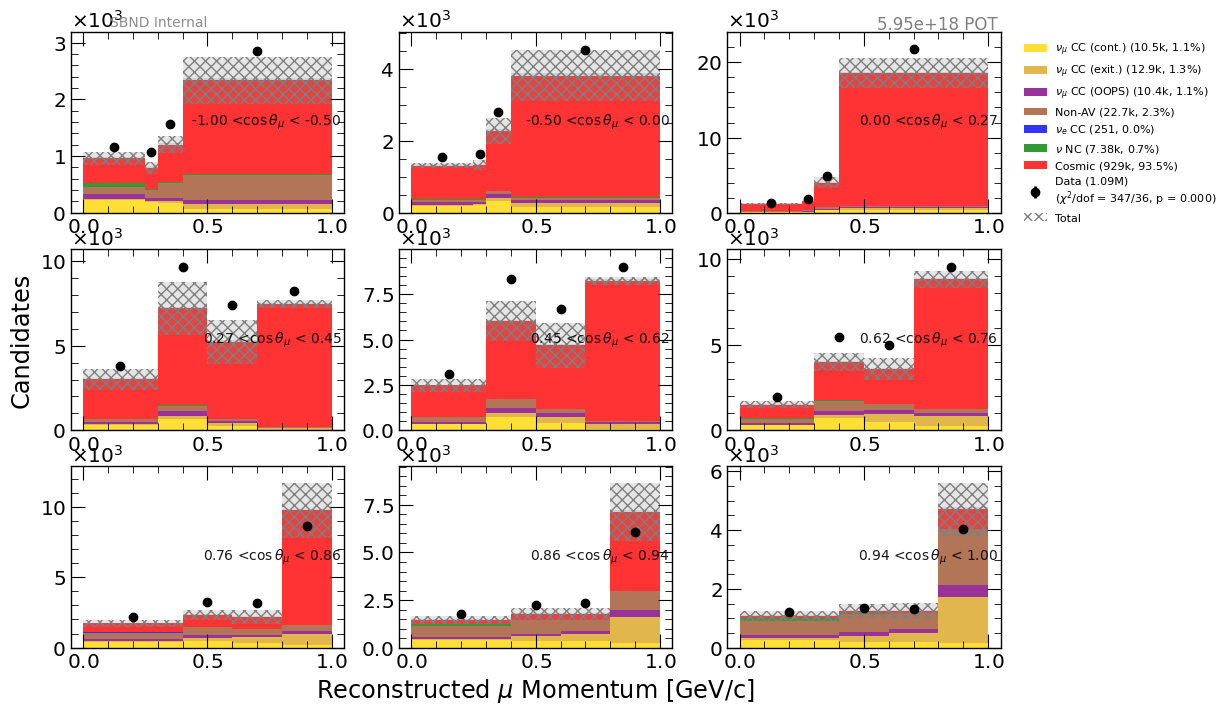

In [28]:
figs,axs = makeplot.create_differential_stack(
  bin2d, labels, binning2d=binning2d,
  data_ids=bin2d_data,
  weights=_weights,
  xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
  label=INTERNAL_DATA_LABEL,
  frac_unc=syst_differential_frac[1:], #Remove null bin
  cov=syst_differential_cov[1:,1:], #Remove null bin
  colors=colors,
  yerr_label=syst_label,
  pot_label=POT_LABEL,
  scale_data=False,
  show_counts=True,
  #savename=f'differential_{cut}cut',
  plot_dir=plot_dir
)

In [62]:
syst_differential_frac = np.loadtxt(f'{syst_folder}/differential_event_fracunc.csv')
len(binning2d.bin_widths),len(syst_differential_frac)

(37, 37)

In [ ]:
from sbnd.stats.systematics import Systematics
flashpe_systematics = Systematics.from_saved(f'{DET_SYST_DIR}/precut','flashpe')

In [483]:
from sbnd.general import utils
cov = flashpe_systematics.systematics['total']['event_cov']
frac_unc = flashpe_systematics.systematics['total']['event_fracunc']
#Get the bin counts from the series
nperbin = utils.get_nperbin(flashpe,syst_flashpe_bins,weights=_weights,sum_hists=True)
nperbin_data = utils.get_nperbin([flashpe_data],syst_flashpe_bins,sum_hists=True)
cov_study_dict = {k:{} for k in range(1,len(syst_flashpe_bins))}
# Get nominal uncertainty from diagonal of covariance matrix
cov_diag = np.diag(cov)*np.eye(len(cov))
#cov = cov_diag
chi2_nom,dof_nom,pval_nom = stats.calc_chi2(nperbin_data,nperbin,cov_diag)
for k in range(1,len(syst_flashpe_bins)):
  #Get the top k eigenvalues for the cov
  cov_top = stats.keep_top_eigenvalues_cov(cov,k)
  cov_diff = cov_top-cov
  cov_ratio = cov_top/cov
  max_cov_diff = np.nanmax(np.abs(cov_diff))
  max_cov_ratio = np.nanmax(np.abs(cov_ratio))
  min_cov_ratio = np.nanmin(np.abs(cov_ratio))
  eigvals,eigvecs,cond,min_eg,max_eig = stats._cov_eigenvalue_diagnostics(cov_top)
  #Get the chi2
  chi2,dof,pval = stats.calc_chi2(nperbin_data,nperbin,cov_top)
  
  cov_study_dict[k]['chi2'] = chi2
  cov_study_dict[k]['dof'] = dof
  cov_study_dict[k]['pval'] = pval
  cov_study_dict[k]['cov'] = cov_top
  cov_study_dict[k]['cov_diff'] = cov_diff
  cov_study_dict[k]['cov_ratio'] = cov_ratio
  cov_study_dict[k]['max_cov_diff'] = max_cov_diff
  cov_study_dict[k]['max_cov_ratio'] = max_cov_ratio
  cov_study_dict[k]['min_cov_ratio'] = min_cov_ratio
  cov_study_dict[k]['eigvals'] = eigvals
  cov_study_dict[k]['min_eig'] = min_eg
  cov_study_dict[k]['max_eig'] = max_eig
  cov_study_dict[k]['diff_eig'] = max_eig-min_eg
  cov_study_dict[k]['eig_vecs'] = eigvecs
  cov_study_dict[k]['cond'] = cond


In [481]:
fig,ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(list(cov_study_dict.keys()),[cov_study_dict[k]['chi2'] for k in cov_study_dict.keys()],label=r'$\chi^2$')
#ax2.plot(list(cov_study_dict.keys()),[cov_study_dict[k]['min_eig'] for k in cov_study_dict.keys()],label=r'$\min(\lambda)$',color='blue')
max_cov_ratio = np.array([cov_study_dict[k]['max_cov_ratio'] for k in cov_study_dict.keys()])
min_cov_ratio = np.array([cov_study_dict[k]['min_cov_ratio'] for k in cov_study_dict.keys()])
ax2.plot(list(cov_study_dict.keys()),max_cov_ratio,label=r'$\max(\Sigma_{\text{reduced}}/\Sigma)$',color='black')
ax2.plot(list(cov_study_dict.keys()),min_cov_ratio,label=r'$\min(\Sigma_{\text{reduced}}/\Sigma)$',color='blue')
ax2.plot(list(cov_study_dict.keys()),(min_cov_ratio+max_cov_ratio)/2,color='green',label=r'$\frac{\min(\Sigma_{\text{reduced}}/\Sigma)+\max(\Sigma_{\text{reduced}}/\Sigma)}{2}$')
#ax2.plot(list(cov_study_dict.keys()),[cov_study_dict[k]['max_eig'] for k in cov_study_dict.keys()],label=r'$\max(\lambda)$',color='green')
ax.axhline(chi2_nom,color='red',ls='--',label=r'$\chi^2_{nom}$')
ax.legend()
ax2.legend()
ax.set_yscale('log')
#ax2.set_yscale('log')
ax2.set_ylim(0.5,1.5)
ax.set_xlabel(r'Number of eigenvalues')
ax.set_ylabel(r'$\chi^2$')
ax2.set_ylabel(r'$\Sigma_{\text{reduced}}/\Sigma$')
ax.set_title(r'Flash PE Total Systematics - Precut')

In [494]:
nperbin

In [495]:
nperbin_data

In [482]:
# Plot all eigenvalues of 
fig,ax = plt.subplots()
eigvals = np.sort(cov_study_dict[list(cov_study_dict.keys())[-1]]['eigvals'])[::-1]
ax.bar(np.arange(len(eigvals)),eigvals)
ax.axhline(np.max(eigvals)*1e-6,color='black',ls='--',label=r'$\max(\lambda) \times 10^{-6}$')
ax.axhline(np.max(eigvals)*1e-3,color='blue',ls='--',label=r'$\max(\lambda) \times 10^{-3}$')
ax.set_xlabel(r'Eigenvalue index')
ax.set_yscale('log')
ax.set_ylabel(r'Eigenvalue')
ax.legend()
ax.set_title(r'Flash PE Total Systematics - Precut')


In [489]:
plt.imshow(cov_study_dict[11]['cov_ratio'])
plt.colorbar()
plt.title(r'$\Sigma_{\text{reduced}}/\Sigma$')

In [490]:
plt.imshow(cov_study_dict[11]['cov_diff'])
plt.colorbar()
plt.title(r'$\Sigma_{\text{reduced}}-\Sigma$')

In [492]:
plt.imshow(cov_study_dict[11]['cov'])
plt.colorbar()
plt.title(r'$\Sigma_{\text{reduced}}$')

In [493]:
plt.imshow(cov)
plt.colorbar()
plt.title(r'$\Sigma$')

In [370]:
syst_flashpe_cov_shrunk,rho,phi = stats.shrink_covariance_oasd(syst_flashpe_cov,n=1)
print(rho,phi)

In [380]:
syst_flashpe_cov_top_eigenvalues = stats.keep_top_eigenvalues_cov(syst_flashpe_cov, 10)
plt.imshow(syst_flashpe_cov_top_eigenvalues)
plt.colorbar()


In [381]:
plt.imshow(syst_flashpe_cov_top_eigenvalues - syst_flashpe_cov)
plt.colorbar()

In [379]:
plt.imshow(flashpe_systematics.systematics['total']['event_cov'])
plt.colorbar()

In [298]:
syst_flashpe_frac = np.loadtxt(f'{DET_SYST_DIR}/precut/total/flashpe_event_fracunc.csv')
#syst_flashpe_cov = np.loadtxt(f'{DET_SYST_DIR}/{cut}/total/flashpe_event_cov.csv')

In [290]:
len(syst_flashpe_bins),len(syst_flashpe_frac)

In [500]:
_slcs = [s.copy() for s in slcs]
[s.cut_all(cut=True) for s in _slcs]

_slc_data = slc_data.copy()
_slc_data.cut_all(cut=True)

In [501]:
momentum = [s.data.mu.pfp.trk.P.p_muon for s in _slcs]
momentum_data = _slc_data.data.mu.pfp.trk.P.p_muon
_weights = [s.data.genweight for s in _slcs]
_data_events = len(_slc_data.data)

syst_momentum_sel = np.loadtxt('/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_28/syst/lowz/metadata_detsys/momentum_sel.csv')
syst_momentum_bg = np.loadtxt('/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_01_28/syst/lowz/metadata_detsys/momentum_sel_background.csv')
syst_momentum_frac = np.loadtxt(f'{DET_SYST_DIR}/lowz/total/momentum_event_fracunc.csv')
syst_momentum_cov = np.eye(len(syst_momentum_frac))*np.diag(np.loadtxt(f'{DET_SYST_DIR}/lowz/total/momentum_event_cov.csv'))
syst_momentum_cov = np.loadtxt(f'{DET_SYST_DIR}/lowz/total/momentum_event_cov.csv')

In [502]:
costheta = [s.data.mu.pfp.trk.costheta for s in _slcs]
costheta_data = _slc_data.data.mu.pfp.trk.costheta

syst_costheta_cov = np.loadtxt(f'{DET_SYST_DIR}/lowz/total/costheta_event_cov.csv')
syst_costheta_frac = np.loadtxt(f'{DET_SYST_DIR}/lowz/total/costheta_event_fracunc.csv')

In [ ]:
fig,ax,ax2 = makeplot.create_hist_dataratio(
    costheta,labels,False,
    data_series=costheta_data,
    xlabel=r'Reconstructed $\cos\theta_{\mu}$',
    label=PANDORA_QUALIFIER_INTERNAL_LABEL,
    colors=colors,
    weights=_weights,
    bins=syst_costheta_bins,
    #cut='full',
    data_events=_data_events,
    yerr=syst_costheta_frac,
    yerr_label=syst_label,
    show_counts=not dens,
    cov=syst_costheta_cov)
    #cov=np.diag(syst_costheta_cov)*np.eye(len(syst_costheta_cov)))

In [505]:
plt.imshow(syst_costheta_cov)
plt.colorbar()


In [340]:
syst_momentum_sel + syst_momentum_bg

In [341]:
np.min(np.abs(syst_momentum_cov))

In [342]:
fig, ax, ax2 = makeplot.create_hist_dataratio(
      momentum, labels, False,
      data_series=momentum_data,
      #cut_desc=cut_desc,
      xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
      label=PANDORA_QUALIFIER_INTERNAL_LABEL,
      colors=colors,
      weights=_weights,
      bins=syst_momentum_bins,
      cut='full',
      #savename='pmu_syst',
      #plot_dir=plot_dir,
      data_events=_data_events,
      yerr=syst_momentum_frac,
      yerr_label=syst_label,
      show_counts=not dens,
      cov=syst_momentum_cov
  )

In [343]:
fig, ax, ax2 = makeplot.create_hist_dataratio(
      momentum, labels, False,
      data_series=momentum_data,
      #cut_desc=cut_desc,
      xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
      label=PANDORA_QUALIFIER_INTERNAL_LABEL,
      colors=colors,
      weights=_weights,
      bins=syst_momentum_bins,
      cut='full',
      #savename='pmu_syst',
      #plot_dir=plot_dir,
      data_events=_data_events,
      yerr=syst_momentum_frac,
      yerr_label=syst_label,
      show_counts=not dens,
      #cov=syst_momentum_cov
  )

In [270]:
cov_diagonal = [114559.25169719,417831.2615943 ,254012.48248511,121681.98516581,62530.93417183,20591.46515236,7212.56230125,7375.38499257,2372.89652732,1233.71733916]
var = [4.60638676e+05,1.59410661e+06,8.94985334e+05,4.04657878e+05,1.80328607e+05,7.49969912e+04,2.81058222e+04,2.90604752e+04,8.47631577e+03,5.07950368e+02]

In [271]:
np.array(cov_diagonal) / np.array(var)

In [272]:
plt.imshow(syst_momentum_cov)
plt.colorbar()

In [115]:
m_data= ~np.isnan(slc_data.data.mu.pfp.trk.start.x)
slc_data.data[m_data].genweight.sum()
m_mc = ~np.isnan(slc_mc.data.mu.pfp.trk.start.x)
m_lowe = np.isnan(slc_mc_lowe.data.mu.pfp.trk.start.x)
m_offbeam = np.isnan(slc_offbeam.data.mu.pfp.trk.start.x)
slc_mc.data[m_mc].genweight.sum()/slc_data.data[m_data].genweight.sum(),slc_mc.data.genweight.sum()/slc_data.data.genweight.sum()

In [116]:
slc_mc.data[m_mc].genweight.sum()/slc_mc.data.genweight.sum(),slc_data.data[m_data].genweight.sum()/slc_data.data.genweight.sum()

#### 3.1.2. SPINE

In [34]:
from naming import SPINE_CUTS_CONT, SPINE_CUTS, SPINE_CUTS_CONT_NOFM, SPINE_CUT_LABELS_CONT_NOFM, SPINE_CUT_LABELS_CONT, SPINE_CUT_LABELS, SPINE_QUALIFIER_PRELIM_LABEL, SPINE_QUALIFIER_INTERNAL_LABEL

In [35]:
reco_pur, reco_eff, gen_pur, gen_eff, f1, _, _, _ = inter.get_pur_eff_f1(
    mcnu, SPINE_CUTS_CONT, categories=[0]
)
reco_pur, reco_eff, gen_pur, gen_eff


In [36]:
fig,ax = plt.subplots(figsize=(7,4))
ax, table = create_purity_efficiency_table(
    reco_pur, reco_eff, gen_pur, gen_eff, SPINE_CUT_LABELS_CONT, ax
)
plotters.add_label(ax,SPINE_QUALIFIER_INTERNAL_LABEL,where=(-0.1,1.06),color='gray',alpha=0.9,fontsize=12)
plotters.save_plot('pur_eff_table_cont_spine',fig=fig,folder_name=f'{PLOT_DIR}/spine_cont')


In [37]:
reco_pur, reco_eff, gen_pur, gen_eff, f1, _, _, _ = inter.get_pur_eff_f1(
    mcnu, SPINE_CUTS, categories=[0, 1]
)
reco_pur, reco_eff, gen_pur, gen_eff


In [38]:
fig,ax = plt.subplots(figsize=(7,4))
ax, table = create_purity_efficiency_table(
    reco_pur, reco_eff, gen_pur, gen_eff, SPINE_CUT_LABELS, ax
)
plotters.add_label(ax,SPINE_QUALIFIER_INTERNAL_LABEL,where=(-0.1,1.14),color='gray',alpha=0.9,fontsize=12)
plotters.save_plot('pur_eff_table_uncont_spine',fig=fig,folder_name=f'{PLOT_DIR}/spine_uncont')


In [39]:
reco_pur, reco_eff, gen_pur, gen_eff, f1, _, _, _ = inter.get_pur_eff_f1(
    mcnu, SPINE_CUTS_CONT_NOFM, categories=[0]
)
reco_pur, reco_eff, gen_pur, gen_eff


In [40]:
fig,ax = plt.subplots(figsize=(7,4))
ax, table = create_purity_efficiency_table(
    reco_pur, reco_eff, gen_pur, gen_eff, SPINE_CUT_LABELS_CONT_NOFM, ax
)
plotters.add_label(ax,SPINE_QUALIFIER_INTERNAL_LABEL,where=(-0.1,1.06),color='gray',alpha=0.9,fontsize=12)
plotters.save_plot('pur_eff_table_cont_nofm_spine',fig=fig,folder_name=f'{PLOT_DIR}/spine_cont_nofm')


In [ ]:
from sbnd.plotlibrary import makeplot
cnt = 0
#for cuts,folder,categories in zip([SPINE_CUTS_CONT,SPINE_CUTS,SPINE_CUTS_CONT_NOFM],['spine_cont','spine_uncont','spine_uncont_nofm'],[[0],[0,1],[0]]):
for cuts,folder,categories in zip([SPINE_CUTS_CONT,SPINE_CUTS],['spine_cont','spine_uncont'],[[0],[0,1]]):
  # if cnt > 0:
  #   break
  cnt += 1
  # Make spectra for spine
  _inters = inters
  _inter_weights = inter_weights
  _inter_data = inter_data
  data_counts = []

  reco_pur, reco_eff, gen_pur, gen_eff, f1, _, _, _ = inter.get_pur_eff_f1(
      mcnu, cuts, categories=categories
  )

  # Initialize variables outside the loop
  _data_events = None
  cut_descriptions = []

  # Pre-compute cut descriptions
  for i, cut in enumerate(['precut'] + cuts):
      cut_desc = f'{cut}:' + '\n' + f'Reco pur = {reco_pur[i]:.2f}' + '\n' + f'Gen eff = {gen_eff[i]:.2f}' + '\n' + f'F1 = {f1[i]:.2f}'
      cut_descriptions.append(cut_desc)

  # Main loop - only copy data when we need to apply cuts
  for i, cut in enumerate(['precut'] + cuts):
      print('*' * 70)
      print(f'cut: {cut}')
      
      if cut != 'precut':
          # Only copy when we need to apply cuts
          if i == 1:  # First cut application
              _inters = [s.copy() for s in inters]
              _inter_weights = [w.copy() for w in inter_weights]
              if _inter_data is not None:
                  _inter_data = inter_data.copy()
              else:
                  _inter_data = None
          
          # Apply cuts in batch
          for s in _inters:
              s.apply_cut(cut)
          
          if _inter_data is not None:
              _inter_data.apply_cut(cut)
              _data_events = len(_inter_data.data)
              data_counts.append(_data_events)
              print(f'len(_inter_data): {_data_events}')
          else:
              _data_events = None
      
      # Pre-compute data access
      total_events = np.sum([len(_s.data) for _s in _inters])
      print(f'len(_inters): {total_events}')
      
      # Muon information
      costheta = [s.data.mu.costheta for s in _inters]
      momentum = [s.data.mu.p/1000. for s in _inters] #convert to GeV
      length = [s.data.mu.length for s in _inters]

      # -start and end points
      start_x = [s.data.mu.start_point.x for s in _inters]
      start_y = [s.data.mu.start_point.y for s in _inters]
      start_z = [s.data.mu.start_point.z for s in _inters]
      end_x = [s.data.mu.end_point.x for s in _inters]
      end_y = [s.data.mu.end_point.y for s in _inters]
      end_z = [s.data.mu.end_point.z for s in _inters]

      # -direction
      direction_x = [s.data.mu.start_dir.x for s in _inters]
      direction_y = [s.data.mu.start_dir.y for s in _inters]
      direction_z = [s.data.mu.start_dir.z for s in _inters]
      
      #Interaction information
      flash_score = [1/s.data.flash_scores for s in _inters]
      flash_time = [s.data.flash_times for s in _inters]
      
      # -Vertex information
      interaction_x = [s.data.vertex.x for s in _inters]
      interaction_y = [s.data.vertex.y for s in _inters]
      interaction_z = [s.data.vertex.z for s in _inters]

      _weights = [s.data.genweight for s in _inters]
      if _inter_data is not None:
        # Muon information
        costheta_data = _inter_data.data.mu.costheta
        momentum_data = _inter_data.data.mu.p/1000. #convert to GeV
        length_data = _inter_data.data.mu.length

        # -start and end points
        start_x_data = _inter_data.data.mu.start_point.x
        start_y_data = _inter_data.data.mu.start_point.y
        start_z_data = _inter_data.data.mu.start_point.z
        end_x_data = _inter_data.data.mu.end_point.x
        end_y_data = _inter_data.data.mu.end_point.y
        end_z_data = _inter_data.data.mu.end_point.z

        # -direction
        direction_x_data = _inter_data.data.mu.start_dir.x
        direction_y_data = _inter_data.data.mu.start_dir.y
        direction_z_data = _inter_data.data.mu.start_dir.z

        # Interaction information
        flash_score_data = 1/_inter_data.data.flash_scores
        flash_time_data = _inter_data.data.flash_times

        # -Vertex information
        vertex_x_data = _inter_data.data.vertex.x
        vertex_y_data = _inter_data.data.vertex.y
        vertex_z_data = _inter_data.data.vertex.z

      else:
        costheta_data = None
        momentum_data = None
        length_data = None
        start_x_data = None
        start_y_data = None
        start_z_data = None
        end_x_data = None
        end_y_data = None
        end_z_data = None
        direction_x_data = None
        direction_y_data = None
        direction_z_data = None
        flash_score_data = None
        flash_time_data = None
        vertex_x_data = None
        vertex_y_data = None
        vertex_z_data = None
      
      # Use pre-computed cut description
      cut_desc = cut_descriptions[i]
      
      # Create plots for both density and counts
      for dens in [True, False]:
          plot_dir = f'{PLOT_DIR}/{folder}/{cut}/{"dens" if dens else "counts"}'
          
          # Costheta
          fig, ax = makeplot.create_hist(
              costheta, labels, dens,
              data_series=costheta_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\cos\theta_{\mu}$',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-1, 1.1, 0.1),
              cut=cut,
              savename='costhetamu',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )
          
          # Momentum
          fig, ax = makeplot.create_hist(
              momentum, labels, dens,
              data_series=momentum_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(0, 2.6, 0.1),
              cut=cut,
              savename='pmu',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -Length
          fig, ax = makeplot.create_hist(
              length, labels, dens,
              data_series=length_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\mu$ Length [cm]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(0, 700, 5),
              cut=cut,
              savename='reco_length',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -Start x
          fig, ax = makeplot.create_hist(
              start_x, labels, dens,
              data_series=start_x_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\mu$ Start X [cm]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-250, 350, 5),
              cut=cut,
              savename='reco_start_x',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -Start y
          fig, ax = makeplot.create_hist(
              start_y, labels, dens,
              data_series=start_y_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\mu$ Start Y [cm]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-250, 350, 5),
              cut=cut,
              savename='reco_start_y',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -Start z
          fig, ax = makeplot.create_hist(
              start_z, labels, dens,
              data_series=start_z_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\mu$ Start Z [cm]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-50, 650, 5),
              cut=cut,
              savename='reco_start_z',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -End x
          fig, ax = makeplot.create_hist(
              end_x, labels, dens,
              data_series=end_x_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\mu$ End X [cm]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-250, 250, 5),
              cut=cut,
              savename='reco_end_x',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -End y
          fig, ax = makeplot.create_hist(
              end_y, labels, dens,
              data_series=end_y_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\mu$ End Y [cm]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-250, 250, 5),
              cut=cut,
              savename='reco_end_y',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -End z
          fig, ax = makeplot.create_hist(
              end_z, labels, dens,
              data_series=end_z_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\mu$ End Z [cm]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-50, 650, 5),
              cut=cut,
              savename='reco_end_z',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -Direction x
          fig, ax = makeplot.create_hist(
              direction_x, labels, dens,
              data_series=direction_x_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\mu$ Direction X',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-1, 1.5, 0.1),
              cut=cut,
              savename='reco_direction_x',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -Direction y
          fig, ax = makeplot.create_hist(
              direction_y, labels, dens,
              data_series=direction_y_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\mu$ Direction Y',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-1, 1.5, 0.1),
              cut=cut,
              savename='reco_direction_y',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -Direction z
          fig, ax = makeplot.create_hist(
              direction_z, labels, dens,
              data_series=direction_z_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed $\mu$ Direction Z',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-1, 1.5, 0.1),
              cut=cut,
              savename='reco_direction_z',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -Interaction x
          fig, ax = makeplot.create_hist(
              interaction_x, labels, dens,
              data_series=interaction_x_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed Interaction X [cm]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-250, 350, 5),
              cut=cut,
              savename='reco_interaction_x',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -Interaction y
          fig, ax = makeplot.create_hist(
              interaction_y, labels, dens,
              data_series=interaction_y_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed Interaction Y [cm]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-250, 350, 5),
              cut=cut,
              savename='reco_interaction_y',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -Interaction z
          fig, ax = makeplot.create_hist(
              interaction_z, labels, dens,
              data_series=interaction_z_data,
              cut_desc=cut_desc,
              xlabel=r'Reconstructed Interaction Z [cm]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-50, 650, 5),
              cut=cut,
              savename='reco_interaction_z',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )

          # -Flash score
          fig, ax = makeplot.create_hist(
              flash_score, labels, dens,
              data_series=flash_score_data,
              cut_desc=cut_desc,
              xlabel=r'OpT0 $\chi^2$ (1/Score)',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.logspace(-5,2,120),
              cut=cut,
              savename='',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )
          #Customize plot
          ax.set_xscale('log')
          plotters.save_plot('opt0_score',fig=fig,folder_name=plot_dir)
          plt.close(fig)

          # -Flash time
          fig, ax = makeplot.create_hist(
              flash_time, labels, dens,
              data_series=flash_time_data,
              cut_desc=cut_desc,
              xlabel=r'Flash Time [ns]',
              label=SPINE_QUALIFIER_INTERNAL_LABEL,
              colors=colors,
              weights=_weights,
              bins=np.arange(-3, 3.1, 0.1),
              cut=cut,
              savename='opt0_time',
              plot_dir=plot_dir,
              data_events=_data_events,
              show_counts=not dens
          )


## 4. Pandora SPINE comp

In [81]:
#Get slices with all cuts applied
slc_cut = slc_mc.copy()
slc_cut.cut_all(False,cut=True)

### 4.1. Track flipping

In [573]:
slc_cut.data.mu.pfp.trk.is_flipped.value_counts(normalize=True)

In [574]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_track_flipping(nprimaries,isflipped,reco_algo='',label='',fig=None,ax1=None,ax2=None,color='blue',xlabel='',**kwargs):
  # Create bins for num_primary_particles_y
  # You might want to adjust these bins based on your data range
  bins = np.arange(1, nprimaries.max() + 2, 1)  # Adjust binning as needed

  # Calculate the fraction of flipped tracks in each bin
  bin_centers = (bins[:-1] + bins[1:]) / 2
  fractions = []
  bin_counts = []
  errors = []

  for i in range(len(bins) - 1):
      mask = (nprimaries >= bins[i]) & (nprimaries < bins[i + 1])
      if mask.sum() > 0:  # Only include bins with data
          flipped_count = isflipped[mask].sum()
          total_count = mask.sum()
          fraction = flipped_count / total_count
          # Binomial error
          error = np.sqrt(fraction * (1 - fraction) / total_count)
          
          fractions.append(fraction)
          bin_counts.append(total_count)
          errors.append(error)
      else:
          fractions.append(np.nan)
          bin_counts.append(0)
          errors.append(0)

  # Convert to numpy arrays and remove NaN values
  fractions = np.array(fractions)
  bin_counts = np.array(bin_counts)
  errors = np.array(errors)

  # Remove bins with no data
  valid_mask = bin_counts > 0
  fractions = fractions[valid_mask]
  bin_centers = bin_centers[valid_mask]
  errors = errors[valid_mask]
  bin_counts = bin_counts[valid_mask]

  # Create the plot
  if fig is None and ax1 is None and ax2 is None:
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

  # Plot the histogram
  ax1.errorbar(bin_centers-0.5, fractions, yerr=errors, label=reco_algo, color=color, **kwargs)

  # Plot the value counts
  ax2.bar(bin_centers-0.5, bin_counts, alpha=0.5, edgecolor=color, facecolor='none', label='Number of Events', hatch='//')

  # Add some styling
  ax1.set_xlabel(xlabel)
  ax1.set_ylabel('Fraction of Flipped Tracks')
  ax1.grid(True, alpha=0.3)
  ax1.axhline(isflipped.mean(),color=color,linestyle='--',label=f'{reco_algo} mean = {isflipped.mean()*100:.1f}%',alpha=0.3)
  ax1.legend(loc='upper right')
  ax2.set_ylabel('Candidates')

  # Add text showing total number of events in each bin
  # for i, (x, y, count) in enumerate(zip(bin_centers, fractions, bin_counts)):
  #     ax1.annotate(f'n={count}', (x-0.15, y), textcoords="offset points", 
  #                 xytext=(0,10), ha='center', fontsize=8, alpha=1.,rotation=45)

  # Add label because this is a plot to keep
  plotters.add_label(ax1,label,where='toprightoutside',color='gray',alpha=0.9,fontsize=10)

  # Print some summary statistics
  print(f"Total events: {len(nprimaries)}")
  print(f"Total flipped tracks: {isflipped.sum()}")
  print(f"Overall flipping fraction: {isflipped.mean():.4f}")
  print(f"Number of bins with data: {len(bin_centers)}")
  return fig,ax1,ax2

In [575]:
# Get the data
x_pand = slc_cut.data.slc.reco.npfp-1
y_pand = slc_cut.data.mu.pfp.trk.is_flipped

# fig,ax1,ax2 = plot_track_flipping(x_spine_cont,y_spine_cont,'SPINE Contained','',color='blue',
#   fmt='o', capsize=5, capthick=2, markersize=6, linewidth=2,alpha=0.6)
# fig,ax1,ax2 = plot_track_flipping(x_spine_uncont,y_spine_uncont,'SPINE Uncontained','',xlabel='Reconstructed Primary Particles', color='red',
#   fmt='o', capsize=5, capthick=2, markersize=6, linewidth=2,alpha=0.6)
fig,ax1,ax2 = plot_track_flipping(x_pand,y_pand,'Pandora','',xlabel='Reconstructed Primary Particles', color='green',
  fmt='o', capsize=5, capthick=2, markersize=6, linewidth=2,alpha=0.6)

plotters.save_plot('pandora_track_flipping',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

In [114]:
#(inter_cut.data.truth.ng-inter_cut.data.truth.npi0_0MeV).value_counts()

In [576]:
x_pandora_uncont_true_trk = slc_cut.data.truth.nmu_25MeV +\
                      slc_cut.data.truth.np_50MeV +\
                      slc_cut.data.truth.npi_25MeV +\
                      slc_cut.data.truth.nk_25MeV
x_pandora_uncont_true_shw = slc_cut.data.truth.ne_25MeV +\
                            2*slc_cut.data.truth.npi0_0MeV +\
                            slc_cut.data.truth.ng
x_pandora_uncont_true_part = x_pandora_uncont_true_trk + x_pandora_uncont_true_shw

In [ ]:
fig,ax1,ax2 = plot_track_flipping(x_pandora_uncont_true_part,y_pand,'Pandora Uncontained','',xlabel='True Primary Particles', color='green',
  fmt='o', capsize=5, capthick=2, markersize=6, linewidth=2,alpha=0.6)

plotters.save_plot('pandora_track_flipping_true_npart',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

## 5. Efficiencies

In [13]:
# from naming import * #Reset all constants cause i think i fuck it up earlier in notebook
# SPINE_CUT_LABELS = ['Flash Match\n(best match, whole detector)','Fiducial','Has Muon','Start dE/dx','Flash Score']
# PAND_CUT_LABELS = ['Flash Match\n($\chi^2$ cut, by TPC)','Fiducial','Has Muon']

In [14]:
COSTHETA_BINS

array([-1.  , -0.5 ,  0.  ,  0.27,  0.45,  0.62,  0.76,  0.86,  0.94,
        1.  ])

In [15]:
# Setup binning
costheta_bins = COSTHETA_BINS
costheta_bin_labels = [f'{costheta_bins[i]:.2f} - {costheta_bins[i+1]:.2f}' for i in range(len(costheta_bins)-1)]
costheta_bin_labels = ['NaN'] + costheta_bin_labels
mom_bins = MOMENTUM_BINS
mom_bin_labels = [f'{mom_bins[i]:.2f} - {mom_bins[i+1]:.2f}' if i < len(mom_bins)-2 else f'> {mom_bins[i]:.2f}' for i in range(len(mom_bins)-1)]
mom_bin_labels = ['NaN'] + mom_bin_labels

# Number of particles binning
count_bins = np.hstack((np.arange(-0.5,7.5,1),np.array([np.inf])))
count_bin_centers = (count_bins[:-1] + count_bins[1:]) / 2
count_bin_labels = [f'{count_bin_centers[i]:.0f}' if i < len(count_bin_centers)-1 else f'> {count_bin_centers[i-1]:.0f}' for i in range(len(count_bin_centers))]

true_count_bins = count_bins[1:] #Remove 0 bin
true_count_bin_centers = (true_count_bins[:-1] + true_count_bins[1:]) / 2
true_count_bin_labels = [f'{true_count_bin_centers[i]:.0f}' if i < len(true_count_bin_centers)-1 else f'> {true_count_bin_centers[i-1]:.0f}' for i in range(len(true_count_bin_centers))]

# Interaction mode binning

#-First replace NaNs with -1 (cosmics)
# col = inter.get_key('truth.genie_mode')[0]
# inter.data.loc[np.isnan(inter.data[col]),col] = -1

col = slc_mc.get_key('truth.genie_mode')[0]
slc_mc.data.loc[np.isnan(slc_mc.data[col]),col] = -1

# Vertex binning
x_bins = np.array([-190, -180, -160,  -40,  -20,    0, 20,   40,  160,  180, 190])
#x_bins = np.array([-100,-60])
x_bin_labels = [f'{x_bins[i]:.0f} - {x_bins[i+1]:.0f}' if i < len(x_bins)-1 else f'Out of AV' for i in range(len(x_bins))]

y_bins = x_bins.copy()
y_bin_labels = [f'{y_bins[i]:.0f} - {y_bins[i+1]:.0f}' if i < len(y_bins)-1 else f'Out of AV' for i in range(len(y_bins))]

z_bins = np.array([30,  40,  60,  200, 220, 240, 245, 255,
        260, 280, 300, 420, 440, 450])
z_bin_labels = [f'{z_bins[i]:.0f} - {z_bins[i+1]:.0f}' if i < len(z_bins)-1 else f'Out of AV' for i in range(len(z_bins))]

In [16]:
#SPINE binning
# inter.assign_bins(costheta_bins,'mu.costheta',assign_key='reco_costheta_bin')
# inter.assign_bins(mom_bins*1000,'mu.p',assign_key='reco_mom_bin')
# #inter.assign_bins(count_bins,'num_primary_particles_x',assign_key='num_primary_particles_x_bin')
# inter.assign_bins(true_count_bins,'truth.ntrue_part',assign_key='ntrue_part_bin')
# inter.assign_bins(x_bins,'vertex.x',assign_key='reco_vertex_x_bin')
# inter.assign_bins(y_bins,'vertex.y',assign_key='reco_vertex_y_bin')
# inter.assign_bins(z_bins,'vertex.z',assign_key='reco_vertex_z_bin')
# inter.assign_bins(x_bins,'truth.position.x',assign_key='true_vertex_x_bin')
# inter.assign_bins(y_bins,'truth.position.y',assign_key='true_vertex_y_bin')
# inter.assign_bins(z_bins,'truth.position.z',assign_key='true_vertex_z_bin')

CONTAINED = True
CATEGORIES = [0]
cuts = PAND_CUTS_CONT if CONTAINED else PAND_CUTS
cut_labels = ['No cut']+PAND_CUT_LABELS_CONT if CONTAINED else PAND_CUT_LABELS

#Pandora binning
#slc_mc.assign_bins(costheta_bins,'mu.pfp.trk.costheta',assign_key='reco_costheta_bin')
#slc_mc.assign_bins(mom_bins,'mu.pfp.trk.P.p_muon',assign_key='reco_mom_bin')
slc_mc.assign_bins(mom_bins,'truth.mu.totp',assign_key='true_mom_bin') #Need this since the binning assigned is for differential bins
slc_mc.assign_bins(costheta_bins,'truth.mu.dir.z',assign_key='true_costheta_bin')
# slc_mc.assign_bins(count_bins,'slc.reco.npfp',assign_key='num_primary_particles_bin')
# #slc_mc.assign_bins(true_count_bins,'truth.ntrue_part',assign_key='ntrue_part_bin')
# slc_mc.assign_bins(x_bins,'slc.vertex.x',assign_key='reco_vertex_x_bin')
# slc_mc.assign_bins(y_bins,'slc.vertex.y',assign_key='reco_vertex_y_bin')
# slc_mc.assign_bins(z_bins,'slc.vertex.z',assign_key='reco_vertex_z_bin')
# slc_mc.assign_bins(x_bins,'truth.position.x',assign_key='true_vertex_x_bin')
# slc_mc.assign_bins(y_bins,'truth.position.y',assign_key='true_vertex_y_bin')
# slc_mc.assign_bins(z_bins,'truth.position.z',assign_key='true_vertex_z_bin')

In [22]:
from sbnd.general.utils import format_number_with_suffix
def get_pur_eff_binned(partgroup,mcnu_obj,bin_key,cuts,**kwargs):
  """
  Get pur, eff, f1 for each bin of bin_key
  
  Parameters
  ----------
  partgroup : caf.NTupleProc
    Particle group
  mcnu_obj : caf.NTupleProc
    MCNu object
  bin_key : str
    Key to bin on
  cuts : list of str
    Cuts to apply
  **kwargs : dict
    Keyword arguments for get_pur_eff_f1

  Returns
  -------
  purs : np.ndarray (len(binning),len(cuts)+1)
    Purity for each bin and cut
  effs : np.ndarray (len(binning),len(cuts)+1)
    Efficiency for each bin and cut
  f1s : np.ndarray (len(binning),len(cuts)+1)
    F1 score for each bin and cut
  """
  bin_col = partgroup.get_key(bin_key)[0]
  binning = np.sort(np.unique(partgroup.data[bin_col].values))

  purs = np.zeros((len(binning),len(cuts)+1))
  effs = purs.copy()
  f1s = purs.copy()
  true_events = purs.copy()
  reco_events = purs.copy()

  for i,bin_val in tqdm(enumerate(binning),total=len(binning),unit='goomba'):
    mask = partgroup.data.loc[:,bin_col] == bin_val
    _partgroup = partgroup.copy()
    _partgroup.data = _partgroup.data[mask]
    _mcnu_obj = _partgroup.get_reference_mcnu(mcnu_obj)
    pur,eff, f1, true_event, reco_event, _ = _partgroup.get_pur_eff_f1(
        _mcnu_obj, cuts, **kwargs
    )
    purs[i] = pur
    effs[i] = eff
    f1s[i] = f1
    true_events[i] = true_event
    reco_events[i] = reco_event
  
  return purs,effs,f1s,true_events,reco_events,binning
def plot_matrix_binned(vals,counts,bin_values,bin_labels,cut_labels,label='',xlabel='',remove_dummy_col=True,title='',roll=False,**kwargs):
  """
  Plot efficiency or purity matrix with text annotations as a function of cut and bin

  Parameters
  ----------
  vals : np.ndarray
    Efficiency matrix
  counts : np.ndarray
    Number of events in each bin
  ax : matplotlib.axes.Axes
    Axes to plot on
  bin_values : np.ndarray
    Bin values
  bin_labels : list
    Bin labels
  cut_labels : list
    Cut labels
  label : str
    Label for the plot
  remove_dummy_col : bool
    Whether to remove the dummy column
  title : str
    Title for the plot
  **kwargs : dict
    Keyword arguments for pcolormesh
  """
  assert (np.nanmax(vals) <= 1.0) & (np.nanmin(vals) >= 0.0), f'max(vals) = {np.max(vals)}. Expect vals between 0 and 1'
  assert np.shape(vals) == np.shape(counts), f'vals.shape = {np.shape(vals)} != {np.shape(counts)} = counts.shape'
  fig,ax = plt.subplots(figsize=(len(bin_values),len(cut_labels)))
  if remove_dummy_col:
    vals = vals[1:]
    counts = counts[1:]
    bin_values = bin_values[1:]
    print('Removing dummy column')
  if roll: #Move the first column to the end
    bin_labels = np.roll(bin_labels,1)
    bin_values = np.roll(bin_values,1)
    counts = np.roll(counts,1,axis=1)
    vals = np.roll(vals,1,axis=1)
    print('Rolling -1 to the end')
    
  adjusted_vals = np.rot90(vals)
  adjusted_counts = np.rot90(counts)
  # print(f'adjusted_vals.shape: {adjusted_vals.shape}')
  # print(f'bin_values: {bin_values}')
  # print(f'bin_labels: {bin_labels}')
  # print(f'cut_labels: {cut_labels}')
  im = ax.pcolormesh(adjusted_vals,vmin=0,vmax=1,**kwargs)

  ax.set_xticks(np.arange(len(bin_values)) + 0.5)
  ax.set_xticklabels(bin_labels,rotation=60)

  ax.set_yticks(np.arange(len(cut_labels)) + 0.5)
  ax.set_yticklabels(reversed(cut_labels))

  for i in range(adjusted_vals.shape[0]):
    for j in range(adjusted_vals.shape[1]):
      value = adjusted_vals[i, j]
      count = adjusted_counts[i, j]
      count_str = format_number_with_suffix(count)
      ax.text(j + 0.5, i + 0.5, f'{value:.3f}'+'\n'+f'({count_str})',
             ha='center', va='center',
             color='black' if value < 0.5 else 'white')

  ax.set_title(title)
  ax.set_xlabel(xlabel)
  fig.colorbar(im,ax=ax)
  plotters.add_label(ax,label,where=(0.,1.02),color='gray',alpha=0.9,fontsize=9)

  return fig,ax

def plot_line_binned(vals, counts, bin_values, bin_labels, cut_labels, label='', xlabel='', remove_dummy_col=True, title='', roll=False, bbox=False, **kwargs):
  assert (np.nanmax(vals) <= 1.0) & (np.nanmin(vals) >= 0.0), f'max(vals) = {np.max(vals)}. Expect vals between 0 and 1'
  assert np.shape(vals) == np.shape(counts), f'vals.shape = {np.shape(vals)} != {np.shape(counts)} = counts.shape'

  fig, ax = plt.subplots()

  if remove_dummy_col:
    vals = vals[1:]
    counts = counts[1:]
    bin_values = bin_values[1:]
    bin_labels = bin_labels[1:]

  if roll:
    bin_labels = np.roll(bin_labels, 1)
    bin_values = np.roll(bin_values, 1)
    counts = np.roll(counts, 1, axis=1)
    vals = np.roll(vals, 1, axis=1)

  x = np.arange(len(bin_values))
  vals = vals.T
  counts = counts.T
  for i, cut in enumerate(cut_labels):
    ax.plot(x, vals[i], marker='o', label=cut)

  ax.set_xticks(x)
  ax.set_xticklabels(bin_labels, rotation=60)
  ax.set_ylim(-0.2, 1)
  ax.set_xlabel(xlabel)
  ax.set_ylabel('Metric')
  ax.set_title(title)
  if bbox:
    ax.legend(ncol=2,bbox_to_anchor=(1.05, 1),loc='upper left')
  else:
    ax.legend(ncol=2)
  plotters.add_label(ax, label, where=(0., 1.02), color='gray', alpha=0.9, fontsize=9)

  return fig, ax
  


### 5.1 Costheta

#### 5.1.1 Reco

In [45]:
#Costheta binning - SPINE
# costheta_inter_purs,costheta_inter_effs,costheta_inter_f1s,costheta_inter_true_events,costheta_inter_reco_events,costheta_inter_binning \
#   = get_pur_eff_binned(inter,mcnu,'reco_costheta_bin',SPINE_CUTS)

In [46]:
# fig,ax = plot_matrix_binned(costheta_inter_effs,costheta_inter_true_events,ax,costheta_inter_binning,costheta_bin_labels,['No cut']+SPINE_CUT_LABELS,label=SPINE_QUALIFIER_INTERNAL_LABEL,xlabel=r'Reconstructed $\cos\theta_\mu$',title='Efficiency',cmap='Greens')
# plotters.save_plot('eff_costheta_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
# fig,ax = plot_matrix_binned(costheta_inter_purs,costheta_inter_true_events,ax,costheta_inter_binning,costheta_bin_labels,['No cut']+SPINE_CUT_LABELS,label=SPINE_QUALIFIER_INTERNAL_LABEL,xlabel=r'Reconstructed $\cos\theta_\mu$',title='Purity',cmap='Blues')
# plotters.save_plot('pur_costheta_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
# plt.close('all')

In [66]:
#Costheta binning - Pandora
from naming import *
costheta_slc_purs,costheta_slc_effs,costheta_slc_f1s,costheta_slc_true_events,costheta_slc_reco_events,costheta_slc_binning \
  = get_pur_eff_binned(slc_mc,mcnu,'reco_costheta_bin',cuts,categories=CATEGORIES)

  0%|          | 0/10 [00:00<?, ?goomba/s]

  0%|          | 0/10 [00:05<?, ?goomba/s]


KeyboardInterrupt: 

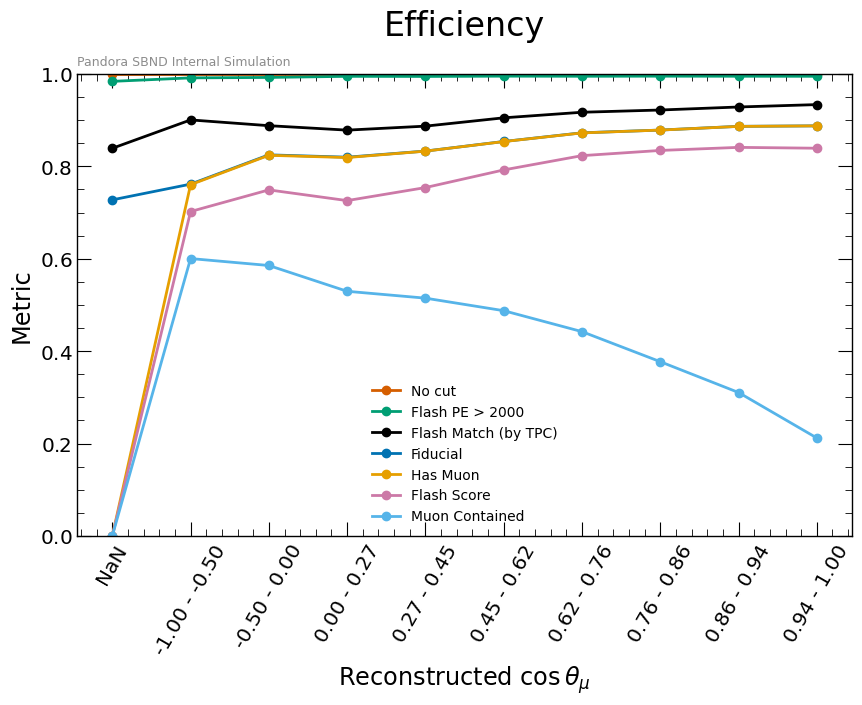

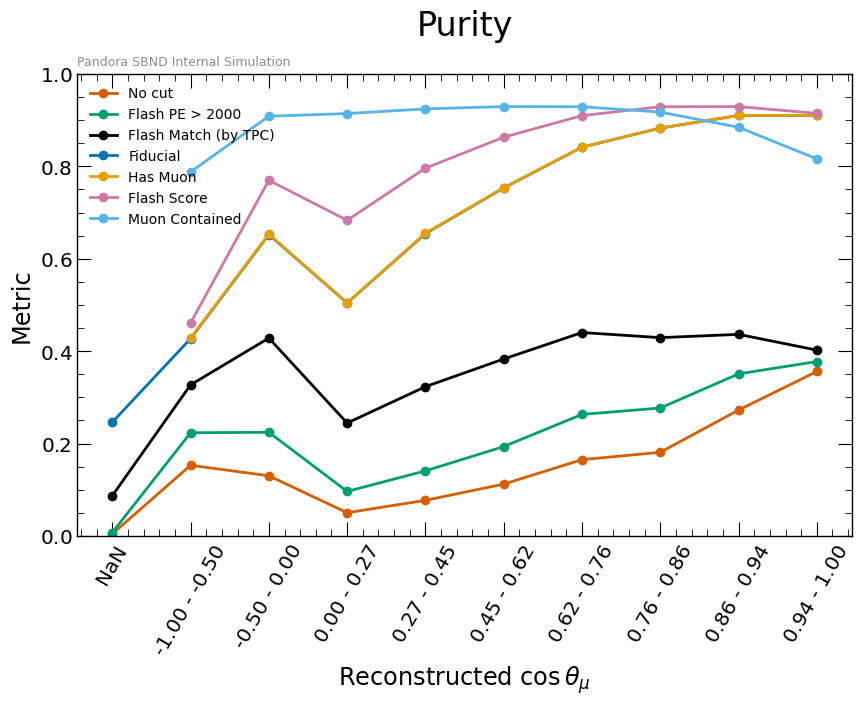

In [ ]:
fig,ax = plot_line_binned(costheta_slc_effs,costheta_slc_true_events,ax,costheta_slc_binning,costheta_bin_labels,cut_labels,
  remove_dummy_col=False,
  label=PANDORA_QUALIFIER_INTERNAL_LABEL,xlabel=r'Reconstructed $\cos\theta_\mu$',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_costheta_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
fig,ax = plot_line_binned(costheta_slc_purs,costheta_slc_true_events,ax,costheta_slc_binning,costheta_bin_labels,cut_labels,
  remove_dummy_col=False,
  label=PANDORA_QUALIFIER_INTERNAL_LABEL,xlabel=r'Reconstructed $\cos\theta_\mu$',title='Purity',cmap='Blues')
plotters.save_plot('pur_costheta_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
#plt.close('all')

In [93]:
# m1 = slc_mc.data.reco_costheta_bin == -1
# m2 = np.isin(slc_mc.data.truth.event_type,[0,1])
# slc_mc.data[m1 & m2].mu.pfp.trk

#### 5.1.2 True

In [48]:
#Costheta binning - Pandora
costheta_slc_purs,costheta_slc_effs,costheta_slc_f1s,costheta_slc_true_events,costheta_slc_reco_events,costheta_slc_binning \
  = get_pur_eff_binned(slc_mc,mcnu,'true_costheta_bin',cuts,categories=CATEGORIES)

100%|██████████| 10/10 [05:09<00:00, 30.94s/goomba]


In [49]:
len(costheta_slc_binning[1:]),len(costheta_slc_true_events[1:]),costheta_bin_labels

(9,
 9,
 ['NaN',
  '-1.00 - -0.50',
  '-0.50 - 0.00',
  '0.00 - 0.27',
  '0.27 - 0.45',
  '0.45 - 0.62',
  '0.62 - 0.76',
  '0.76 - 0.86',
  '0.86 - 0.94',
  '0.94 - 1.00'])

In [50]:
costheta_slc_effs

array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan],
       [1.        , 0.98859166, 0.88276947, 0.81038552, 0.79937057,
        0.5700236 , 0.55428796, 0.55428796, 0.47285602],
       [1.        , 0.9925084 , 0.88840093, 0.81219323, 0.80521829,
        0.52492896, 0.50167915, 0.50167915, 0.41539654],
       [1.        , 0.99546926, 0.89029126, 0.80291262, 0.79805825,
        0.50032362, 0.48414239, 0.48381877, 0.4038835 ],
       [1.        , 0.99546952, 0.89950577, 0.83525535, 0.8315486 ,
        0.68163097, 0.66474465, 0.66474465, 0.56054366],
       [1.        , 0.99448846, 0.92008267, 0.85945574, 0.85532208,
        0.75714778, 0.74543576, 0.74543576, 0.63176025],
       [1.        , 0.99362832, 0.92495575, 0.87929204, 0.87504425,
        0.7840708 , 0.77451327, 0.77380531, 0.66442478],
       [1.        , 0.99424579, 0.92807234, 0.88573777, 0.88080559,
        0.79284834, 0.77969585, 0.77969585, 0.68845047],


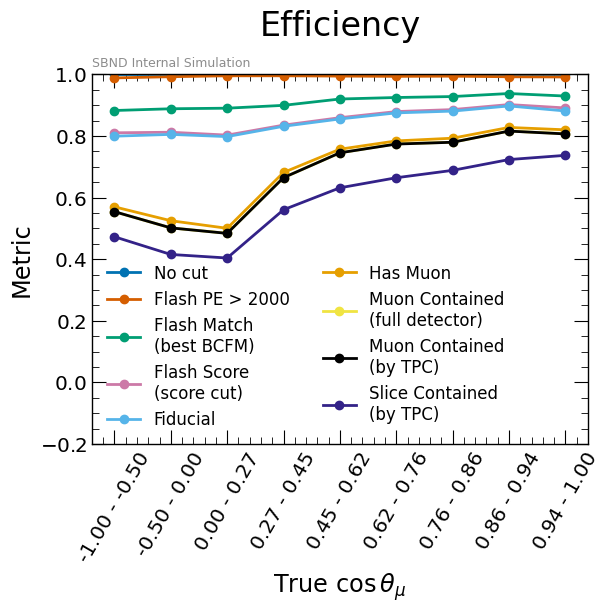

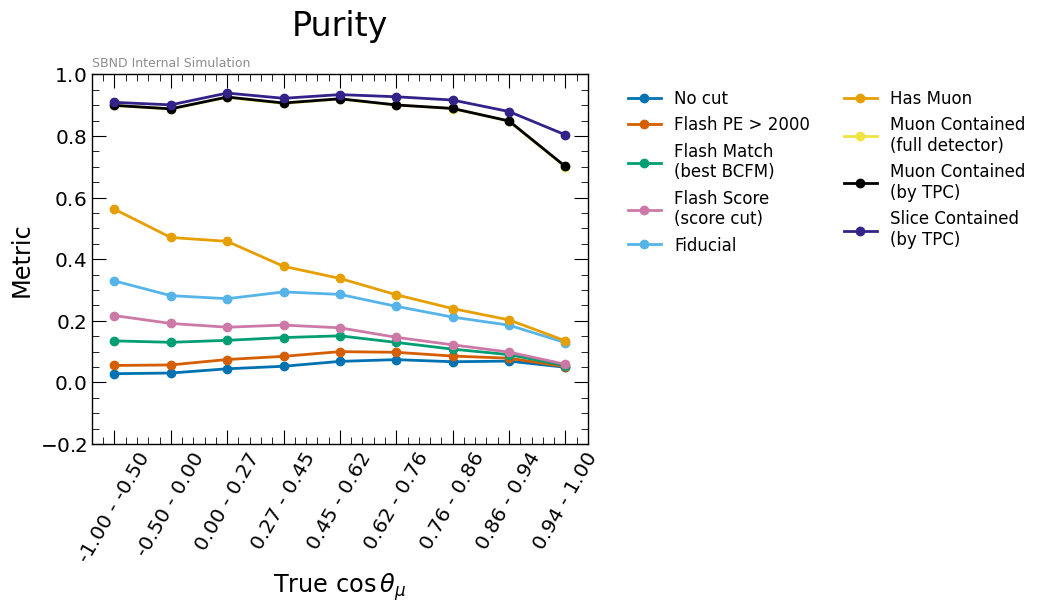

In [52]:
fig,ax = plot_line_binned(costheta_slc_effs,costheta_slc_true_events,costheta_slc_binning,costheta_bin_labels,cut_labels,
  remove_dummy_col=True,
  roll=False,
  label=INTERNAL_LABEL,xlabel=r'True $\cos\theta_\mu$',title='Efficiency')
plotters.save_plot('eff_true_costheta_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
fig,ax = plot_line_binned(costheta_slc_purs,costheta_slc_true_events,costheta_slc_binning,costheta_bin_labels,cut_labels,
  remove_dummy_col=True,
  roll=False,
  label=INTERNAL_LABEL,xlabel=r'True $\cos\theta_\mu$',title='Purity',bbox=True)
plotters.save_plot('pur_true_costheta_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
#plt.close('all')

### 5.2 Momentum

#### 5.2.1 Reco

In [85]:
# Momentum binning - Pandora
mom_slc_purs,mom_slc_effs,mom_slc_f1s,mom_slc_true_events,mom_slc_reco_events,mom_slc_binning \
  = get_pur_eff_binned(slc_mc,mcnu,'reco_mom_bin',PAND_CUTS)

  0%|          | 0/9 [00:00<?, ?goomba/s]

/tmp/ipykernel_56699/2682259774.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  _partgroup.data = _partgroup.data[mask]
 11%|█         | 1/9 [02:00<16:03, 120.39s/goomba]/tmp/ipykernel_56699/2682259774.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  _partgroup.data = _partgroup.data[mask]
 22%|██▏       | 2/9 [02:35<08:11, 70.17s/goomba] /tmp/ipykernel_56699/2682259774.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  _partgroup.data = _partgroup.data[mask]
 33%|███▎      | 3/9 [03:10<05:23, 53.98s/goomba]/tmp/ipykernel_56699/2682259774.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  _partgroup.data = _partgroup.data[mask]
 44%|████▍     | 4/9 [03:44<03:50, 46.10s/goomba]/tmp/ipykernel_56699/2682259774.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  _partgroup.data = _partgroup.data[mask]
 56%|█████▌    | 

In [86]:
fig,ax = plot_matrix_binned(mom_slc_effs,mom_slc_true_events,ax,mom_slc_binning,mom_bin_labels,['No cut']+PAND_CUT_LABELS,
  remove_dummy_col=False,
  roll=False,
  label=PANDORA_QUALIFIER_INTERNAL_LABEL,xlabel=r'Reconstructed $p_\mu$ [MeV]',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_mom_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
fig,ax = plot_matrix_binned(mom_slc_purs,mom_slc_true_events,ax,mom_slc_binning,mom_bin_labels,['No cut']+PAND_CUT_LABELS,
  remove_dummy_col=False,
  roll=False,
  label=PANDORA_QUALIFIER_INTERNAL_LABEL,xlabel=r'Reconstructed $p_\mu$ [MeV]',title='Purity',cmap='Blues')
plotters.save_plot('pur_mom_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
plt.close('all')

#### 5.2.2 True

In [18]:
# Momentum binning - Pandora
mom_slc_purs,mom_slc_effs,mom_slc_f1s,mom_slc_true_events,mom_slc_reco_events,mom_slc_binning \
  = get_pur_eff_binned(slc_mc,mcnu,'true_mom_bin',cuts,categories=CATEGORIES)

  0%|          | 0/10 [00:00<?, ?goomba/s]

100%|██████████| 10/10 [05:31<00:00, 33.12s/goomba]


array([[   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],
       [1553., 1532., 1331., 1207., 1198.,  440.,  406.,  406.,  356.],
       [3630., 3600., 3234., 2963., 2945., 1746., 1691., 1691., 1496.],
       [3751., 3714., 3334., 3077., 3054., 2336., 2282., 2282., 1978.],
       [6096., 6060., 5536., 5159., 5127., 4353., 4263., 4262., 3677.],
       [3730., 3710., 3440., 3238., 3211., 2910., 2847., 2846., 2418.],
       [2273., 2266., 2135., 2021., 2011., 1907., 1883., 1882., 1598.],
       [1321., 1319., 1232., 1195., 1185., 1140., 1123., 1123.,  952.],
       [ 710.,  704.,  677.,  643.,  640.,  612.,  605.,  604.,  525.],
       [ 657.,  656.,  633.,  602.,  595.,  573.,  559.,  559.,  450.]])

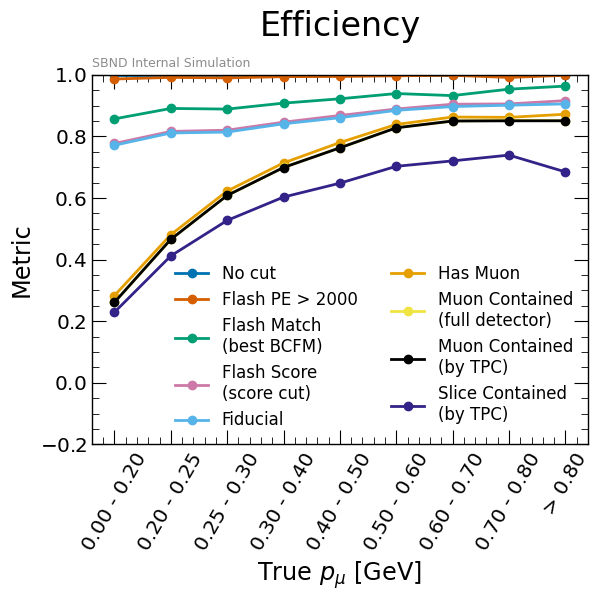

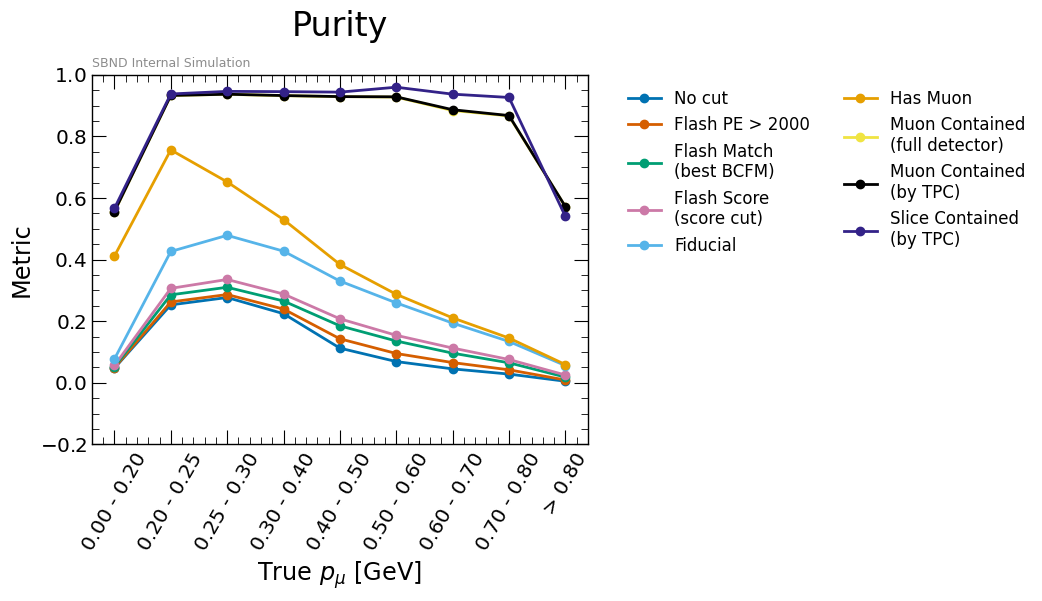

In [47]:
fig,ax = plot_line_binned(mom_slc_effs[1:],mom_slc_true_events[1:],mom_slc_binning[1:],mom_bin_labels[1:],cut_labels,
  remove_dummy_col=False,
  #roll=True,
  label=INTERNAL_LABEL,xlabel=r'True $p_\mu$ [GeV]',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_true_mom_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
fig,ax = plot_line_binned(mom_slc_purs[1:],mom_slc_true_events[1:],mom_slc_binning[1:],mom_bin_labels[1:],cut_labels,
  remove_dummy_col=False,
  #roll=True,
  label=INTERNAL_LABEL,xlabel=r'True $p_\mu$ [GeV]',title='Purity',bbox=True)
plotters.save_plot('pur_true_mom_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
#plt.close('all')

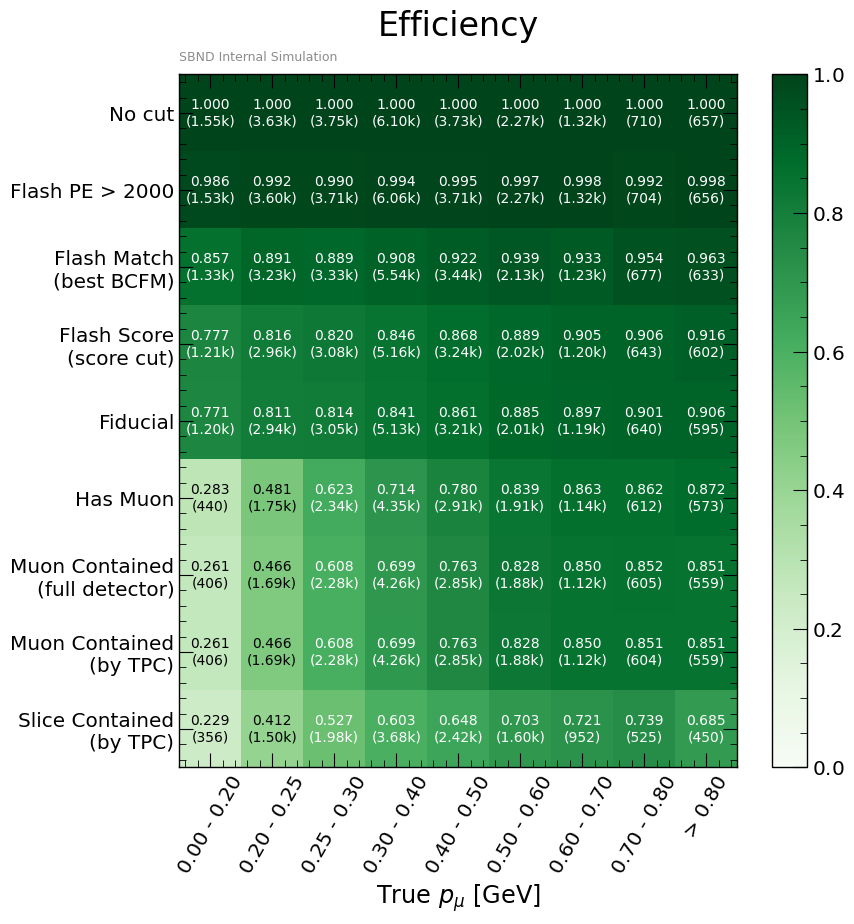

In [46]:
fig,ax = plot_matrix_binned(mom_slc_effs[1:],mom_slc_true_events[1:],mom_slc_binning[1:],mom_bin_labels[1:],cut_labels,
  remove_dummy_col=False,
  #roll=True,
  label=INTERNAL_LABEL,xlabel=r'True $p_\mu$ [GeV]',title='Efficiency',cmap='Greens')

In [45]:
mom_slc_true_events

array([[   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.],
       [1553., 1532., 1331., 1207., 1198.,  440.,  406.,  406.,  356.],
       [3630., 3600., 3234., 2963., 2945., 1746., 1691., 1691., 1496.],
       [3751., 3714., 3334., 3077., 3054., 2336., 2282., 2282., 1978.],
       [6096., 6060., 5536., 5159., 5127., 4353., 4263., 4262., 3677.],
       [3730., 3710., 3440., 3238., 3211., 2910., 2847., 2846., 2418.],
       [2273., 2266., 2135., 2021., 2011., 1907., 1883., 1882., 1598.],
       [1321., 1319., 1232., 1195., 1185., 1140., 1123., 1123.,  952.],
       [ 710.,  704.,  677.,  643.,  640.,  612.,  605.,  604.,  525.],
       [ 657.,  656.,  633.,  602.,  595.,  573.,  559.,  559.,  450.]])

### 5.3 Number of primary particles

#### 5.3.1 Reco

In [38]:
# Number of primary particles binning - SPINE
# nprim_inter_purs,nprim_inter_effs,nprim_inter_f1s,nprim_inter_true_events,nprim_inter_reco_events,nprim_inter_binning \
#   = get_pur_eff_binned(inter,mcnu,'num_primary_particles_x_bin',SPINE_CUTS)

In [39]:
# fig,ax = plot_matrix_binned(nprim_inter_effs,nprim_inter_true_events,ax,nprim_inter_binning,count_bin_labels,['Precut']+SPINE_CUT_LABELS,label=SPINE_QUALIFIER_INTERNAL_LABEL,remove_dummy_col=False,xlabel=r'Number of primary particles',title='Efficiency',cmap='Greens')
# plotters.save_plot('eff_nprim_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
# fig,ax = plot_matrix_binned(nprim_inter_purs,nprim_inter_true_events,ax,nprim_inter_binning,count_bin_labels,['Precut']+SPINE_CUT_LABELS,label=SPINE_QUALIFIER_INTERNAL_LABEL,remove_dummy_col=False,xlabel=r'Number of primary particles',title='Purity',cmap='Blues')
# plotters.save_plot('pur_nprim_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
#plt.close('all')


In [87]:
nprim_slc_purs,nprim_slc_effs,nprim_slc_f1s,nprim_slc_true_events,nprim_slc_reco_events,nprim_slc_binning \
  = get_pur_eff_binned(slc,mcnu,'num_primary_particles_bin',cuts,categories=CATEGORIES)

NameError: name 'slc' is not defined

In [ ]:
fig,ax = plot_line_binned(nprim_slc_effs,nprim_slc_true_events,ax,nprim_slc_binning,count_bin_labels[2:],['Precut']+PAND_CUT_LABELS,label=PANDORA_QUALIFIER_INTERNAL_LABEL,remove_dummy_col=False,xlabel=r'Number of primary particles',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_nprim_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
fig,ax = plot_line_binned(nprim_slc_purs,nprim_slc_true_events,ax,nprim_slc_binning,count_bin_labels[2:],['Precut']+PAND_CUT_LABELS,label=PANDORA_QUALIFIER_INTERNAL_LABEL,remove_dummy_col=False,xlabel=r'Number of primary particles',title='Purity',cmap='Blues')
plotters.save_plot('pur_nprim_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
#plt.close('all')

#### 5.3.2 True

In [ ]:
# ntrue_part_inter_purs,ntrue_part_inter_effs,ntrue_part_inter_f1s,ntrue_part_inter_true_events,ntrue_part_inter_reco_events,ntrue_part_inter_binning \
#   = get_pur_eff_binned(inter,mcnu,'ntrue_part_bin',SPINE_CUTS)

In [ ]:
# fig,ax = plot_matrix_binned(ntrue_part_inter_effs,ntrue_part_inter_true_events,ax,ntrue_part_inter_binning,true_count_bin_labels,['Precut']+SPINE_CUT_LABELS,label=SPINE_QUALIFIER_INTERNAL_LABEL,remove_dummy_col=True,xlabel=r'True primary particles',title='Efficiency',cmap='Greens')
# plotters.save_plot('eff_true_nprim_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
# fig,ax = plot_matrix_binned(ntrue_part_inter_purs,ntrue_part_inter_true_events,ax,ntrue_part_inter_binning,true_count_bin_labels,['Precut']+SPINE_CUT_LABELS,label=SPINE_QUALIFIER_INTERNAL_LABEL,remove_dummy_col=True,xlabel=r'True primary particles',title='Purity',cmap='Blues')
# plotters.save_plot('pur_true_nprim_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
# plt.close('all')

In [ ]:
ntrue_part_slc_purs,ntrue_part_slc_effs,ntrue_part_slc_f1s,ntrue_part_slc_true_events,ntrue_part_slc_reco_events,ntrue_part_slc_binning \
  = get_pur_eff_binned(slc_mc,mcnu,'ntrue_part_bin',cuts,categories=CATEGORIES)

In [ ]:
fig,ax = plot_matrix_binned(ntrue_part_slc_effs,ntrue_part_slc_true_events,ax,ntrue_part_slc_binning,true_count_bin_labels,['Precut']+PAND_CUT_LABELS,label=PANDORA_QUALIFIER_INTERNAL_LABEL,remove_dummy_col=True,xlabel=r'True primary particles',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_true_nprim_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
fig,ax = plot_matrix_binned(ntrue_part_slc_purs,ntrue_part_slc_true_events,ax,ntrue_part_slc_binning,true_count_bin_labels,['Precut']+PAND_CUT_LABELS,label=PANDORA_QUALIFIER_INTERNAL_LABEL,remove_dummy_col=True,xlabel=r'True primary particles',title='Purity',cmap='Blues')
plotters.save_plot('pur_true_nprim_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
plt.close('all')

### 5.4 Vertex

#### 5.4.1 True

##### 5.4.1.1 X

In [ ]:
# X binning - SPINE
x_inter_purs,x_inter_effs,x_inter_f1s,x_inter_true_events,x_inter_reco_events,x_inter_binning \
  = get_pur_eff_binned(inter,mcnu,'true_vertex_x_bin',SPINE_CUTS)

In [ ]:
fig,ax = plot_matrix_binned(x_inter_effs,x_inter_true_events,ax,x_inter_binning,x_bin_labels[:-1],['No cut']+SPINE_CUT_LABELS,remove_dummy_col=True,label=SPINE_QUALIFIER_INTERNAL_LABEL,xlabel=r'True X Vertex [cm]',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_x_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
fig,ax = plot_matrix_binned(x_inter_purs,x_inter_true_events,ax,x_inter_binning,x_bin_labels[:-1],['No cut']+SPINE_CUT_LABELS,remove_dummy_col=True,label=SPINE_QUALIFIER_INTERNAL_LABEL,xlabel=r'True X Vertex [cm]',title='Purity',cmap='Blues')
plotters.save_plot('pur_x_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
plt.close('all')

In [ ]:
x_slc_purs,x_slc_effs,x_slc_f1s,x_slc_true_events,x_slc_reco_events,x_slc_binning \
  = get_pur_eff_binned(slc,mcnu,'true_vertex_x_bin',PAND_CUTS)

In [ ]:
fig,ax = plot_matrix_binned(x_slc_effs,x_slc_true_events,ax,x_slc_binning,x_bin_labels[:-1],['No cut']+PAND_CUT_LABELS,label=PANDORA_QUALIFIER_INTERNAL_LABEL,xlabel=r'True X Vertex [cm]',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_x_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
fig,ax = plot_matrix_binned(x_slc_purs,x_slc_true_events,ax,x_slc_binning,x_bin_labels[:-1],['No cut']+PAND_CUT_LABELS,label=PANDORA_QUALIFIER_INTERNAL_LABEL,xlabel=r'True X Vertex [cm]',title='Purity',cmap='Blues')
plotters.save_plot('pur_x_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
plt.close('all')

##### 5.4.1.2 Y

In [ ]:
y_inter_purs,y_inter_effs,y_inter_f1s,y_inter_true_events,y_inter_reco_events,y_inter_binning \
  = get_pur_eff_binned(inter,mcnu,'true_vertex_y_bin',SPINE_CUTS)

In [ ]:
fig,ax = plot_matrix_binned(y_inter_effs,y_inter_true_events,ax,y_inter_binning,y_bin_labels[:-1],['No cut']+SPINE_CUT_LABELS,label=SPINE_QUALIFIER_INTERNAL_LABEL,xlabel=r'True Y Vertex [cm]',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_y_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
fig,ax = plot_matrix_binned(y_inter_purs,y_inter_true_events,ax,y_inter_binning,y_bin_labels[:-1],['No cut']+SPINE_CUT_LABELS,label=SPINE_QUALIFIER_INTERNAL_LABEL,xlabel=r'True Y Vertex [cm]',title='Purity',cmap='Blues')
plotters.save_plot('pur_y_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
plt.close('all')

In [ ]:
y_slc_purs,y_slc_effs,y_slc_f1s,y_slc_true_events,y_slc_reco_events,y_slc_binning \
  = get_pur_eff_binned(slc,mcnu,'true_vertex_y_bin',PAND_CUTS)

In [ ]:
fig,ax = plot_matrix_binned(y_slc_effs,y_slc_true_events,ax,y_slc_binning,y_bin_labels[:-1],['No cut']+PAND_CUT_LABELS,label=PANDORA_QUALIFIER_INTERNAL_LABEL,xlabel=r'True Y Vertex [cm]',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_y_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
fig,ax = plot_matrix_binned(y_slc_purs,y_slc_true_events,ax,y_slc_binning,y_bin_labels[:-1],['No cut']+PAND_CUT_LABELS,label=PANDORA_QUALIFIER_INTERNAL_LABEL,xlabel=r'True Y Vertex [cm]',title='Purity',cmap='Blues')
plotters.save_plot('pur_y_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
plt.close('all')

##### 5.4.1.3 Z

In [ ]:
z_inter_purs,z_inter_effs,z_inter_f1s,z_inter_true_events,z_inter_reco_events,z_inter_binning \
  = get_pur_eff_binned(inter,mcnu,'true_vertex_z_bin',SPINE_CUTS)

In [ ]:
fig,ax = plot_matrix_binned(z_inter_effs,z_inter_true_events,ax,z_inter_binning,z_bin_labels[:-1],['No cut']+SPINE_CUT_LABELS,label=SPINE_QUALIFIER_INTERNAL_LABEL,xlabel=r'True Z Vertex [cm]',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_z_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
fig,ax = plot_matrix_binned(z_inter_purs,z_inter_true_events,ax,z_inter_binning,z_bin_labels[:-1],['No cut']+SPINE_CUT_LABELS,label=SPINE_QUALIFIER_INTERNAL_LABEL,xlabel=r'True Z Vertex [cm]',title='Purity',cmap='Blues')
plotters.save_plot('pur_z_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
plt.close('all')

In [ ]:
z_slc_purs,z_slc_effs,z_slc_f1s,z_slc_true_events,z_slc_reco_events,z_slc_binning \
  = get_pur_eff_binned(slc,mcnu,'true_vertex_z_bin',PAND_CUTS)

In [ ]:
fig,ax = plot_matrix_binned(z_slc_effs,z_slc_true_events,ax,z_slc_binning,z_bin_labels[:-1],['No cut']+PAND_CUT_LABELS,label=PANDORA_QUALIFIER_INTERNAL_LABEL,xlabel=r'True Z Vertex [cm]',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_z_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
fig,ax = plot_matrix_binned(z_slc_purs,z_slc_true_events,ax,z_slc_binning,z_bin_labels[:-1],['No cut']+PAND_CUT_LABELS,label=PANDORA_QUALIFIER_INTERNAL_LABEL,xlabel=r'True Z Vertex [cm]',title='Purity',cmap='Blues')
plotters.save_plot('pur_z_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
plt.close('all')

### 5.5 Interaction mode

In [ ]:
mode_inter_purs,mode_inter_effs,mode_inter_f1s,mode_inter_true_events,mode_inter_reco_events,mode_inter_binning \
  = get_pur_eff_binned(inter,mcnu,'truth.genie_mode',SPINE_CUTS)

In [ ]:
mode_labels = [GENIE_INTERACTION_MAP[mode][1] for mode in np.sort(mode_inter_binning)]

#Reduce the number of modes only to those that contribute to the signal
mode_labels = mode_labels[1:5] + [mode_labels[6]]
_mode_inter_binning = list(mode_inter_binning[1:5]) + [mode_inter_binning[6]]
_mode_inter_effs = np.vstack([mode_inter_effs[1:5],mode_inter_effs[6]])
_mode_inter_purs = np.vstack([mode_inter_purs[1:5],mode_inter_purs[6]])
_mode_inter_true_events = np.vstack([mode_inter_true_events[1:5],mode_inter_true_events[6]])
_mode_inter_reco_events = np.vstack([mode_inter_reco_events[1:5],mode_inter_reco_events[6]])
mode_labels,_mode_inter_binning,mode_inter_binning,_mode_inter_effs.shape,_mode_inter_purs.shape

In [ ]:
fig,ax = plot_matrix_binned(_mode_inter_effs,_mode_inter_true_events,ax,_mode_inter_binning,mode_labels,['Precut']+SPINE_CUT_LABELS,remove_dummy_col=False,label=SPINE_QUALIFIER_INTERNAL_LABEL,xlabel=r'Interaction mode',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_mode_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
fig,ax = plot_matrix_binned(_mode_inter_purs,_mode_inter_true_events,ax,_mode_inter_binning,mode_labels,['Precut']+SPINE_CUT_LABELS,remove_dummy_col=False,label=SPINE_QUALIFIER_INTERNAL_LABEL,xlabel=r'Interaction mode',title='Purity',cmap='Blues')
plotters.save_plot('pur_mode_binned',fig=fig,folder_name=f'{PLOT_DIR}/spine')
plt.close('all')


In [88]:
mode_slc_purs,mode_slc_effs,mode_slc_f1s,mode_slc_true_events,mode_slc_reco_events,mode_slc_binning \
  = get_pur_eff_binned(slc_mc,mcnu,'truth.genie_mode',cuts,categories=CATEGORIES)

  0%|          | 0/8 [00:00<?, ?goomba/s]/tmp/ipykernel_1568/1484603333.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  _partgroup.data = _partgroup.data[mask]
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/cafclasses/particlegroup.py:251: RuntimeWarning: invalid value encountered in scalar divide
  eff[0] = truth_events/init_truth
 12%|█▎        | 1/8 [03:02<21:15, 182.23s/goomba]/tmp/ipykernel_1568/1484603333.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  _partgroup.data = _partgroup.data[mask]
 25%|██▌       | 2/8 [04:05<11:13, 112.25s/goomba]/tmp/ipykernel_1568/1484603333.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  _partgroup.data = _partgroup.data[mask]
 38%|███▊      | 3/8 [05:07<07:25, 89.16s/goomba] /tmp/ipykernel_1568/1484603333.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  _partgroup.data = _pa

In [89]:
mode_labels = [GENIE_INTERACTION_MAP[mode][1] for mode in np.sort(mode_slc_binning)]

#Reduce the number of modes only to those that contribute to the signal
mode_labels = mode_labels[1:5] + [mode_labels[6]]
_mode_slc_binning = list(mode_slc_binning[1:5]) + [mode_slc_binning[6]]
_mode_slc_effs = np.vstack([mode_slc_effs[1:5],mode_slc_effs[6]])
_mode_slc_purs = np.vstack([mode_slc_purs[1:5],mode_slc_purs[6]])
_mode_slc_true_events = np.vstack([mode_slc_true_events[1:5],mode_slc_true_events[6]])
_mode_slc_reco_events = np.vstack([mode_slc_reco_events[1:5],mode_slc_reco_events[6]])

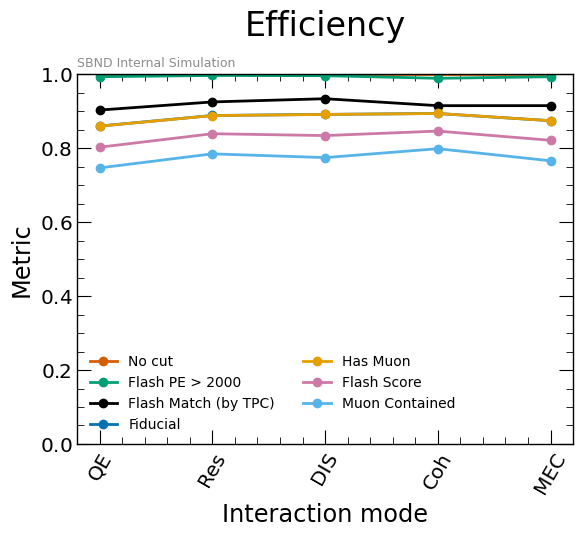

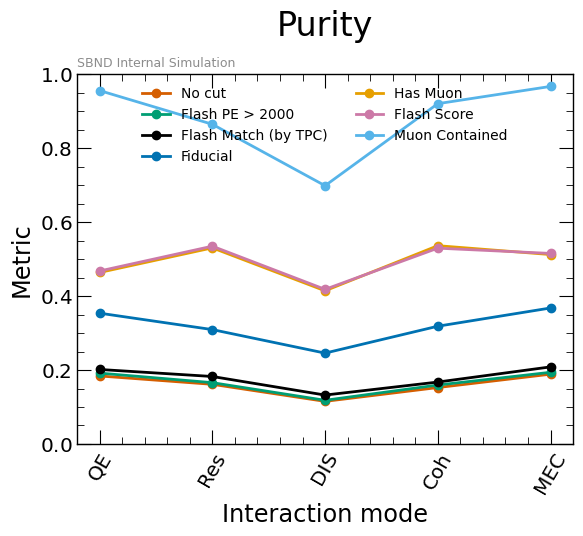

In [92]:
fig,ax = plot_line_binned(_mode_slc_effs,_mode_slc_true_events,ax,_mode_slc_binning,mode_labels,cut_labels,remove_dummy_col=False,label=INTERNAL_LABEL,xlabel=r'Interaction mode',title='Efficiency',cmap='Greens')
plotters.save_plot('eff_mode_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
fig,ax = plot_line_binned(_mode_slc_purs,_mode_slc_true_events,ax,_mode_slc_binning,mode_labels,cut_labels,remove_dummy_col=False,label=INTERNAL_LABEL,xlabel=r'Interaction mode',title='Purity',cmap='Blues')
plotters.save_plot('pur_mode_binned',fig=fig,folder_name=f'{PLOT_DIR}/pandora')
#plt.close('all')


### 5.6 Testing

In [73]:
fig,ax = plt.subplots(figsize=(8,4))

adjusted_effs = np.rot90(effs[1:])

im = ax.pcolormesh(adjusted_effs,vmin=0,vmax=1)

# Set x-axis labels (costheta bins) - these are the columns after rotation
costheta_bin_values = np.sort(inter.data.reco_costheta_bin.unique()[1:])
ax.set_xticks(np.arange(len(costheta_bin_values)) + 0.5)
ax.set_xticklabels(COSTHETA_BIN_LABELS,rotation=60)

# Set y-axis labels (cut labels) - these are the rows after rotation
# Note: SPINE_CUT_LABELS + one more for the +1 in the shape
cut_labels = ['Precut'] +SPINE_CUT_LABELS  # or whatever the +1 represents
ax.set_yticks(np.arange(len(cut_labels)) + 0.5)
ax.set_yticklabels(reversed(cut_labels))  # reversed because rot90 flips order
# Add text annotations to each cell
for i in range(adjusted_effs.shape[0]):  # rows (cuts)
    for j in range(adjusted_effs.shape[1]):  # columns (costheta bins)
        value = adjusted_effs[i, j]
        # Skip NaN values if you want
        if not np.isnan(value):
            ax.text(j + 0.5, i + 0.5, f'{value:.3f}', 
                   ha='center', va='center', 
                   color='black' if value < 0.5 else 'white')

ax.set_title('Efficiency')
ax.set_xlabel(r'Reconstructed $\cos\theta_\mu$')
fig.colorbar(im,ax=ax)
plotters.add_label(ax,SPINE_QUALIFIER_INTERNAL_LABEL,where=(0.,1.02),color='gray',alpha=0.9,fontsize=9)

#fig,(ax1,ax2) = plt.subplots(figsize=(8,4),nrows=1,ncols=2)

#ax1.imshow(np.rot90(effs))
#ax2.imshow(np.rot90(purs))

In [35]:
inter.data.reco_costheta_bin.unique()

In [39]:
purs = np.zeros((len(inter.data.reco_costheta_bin.unique()),len(SPINE_CUTS)+1))
effs = purs.copy()
f1s = purs.copy()

print(f'len(inter.data): {len(inter.data)}')
print(f'len(mcnu.data): {len(mcnu.data)}')
#Get pur, eff for each bin
for i,costheta_bin in tqdm(enumerate(np.sort(inter.data.reco_costheta_bin.unique()))):
  mask = inter.data.reco_costheta_bin == costheta_bin
  _inter = inter.copy()
  _inter.data = _inter.data[mask]
  print(f'-len(_inter): {len(_inter.data)}')
  #print(f'-len(mcnu): {len(mcnu.data)}')
  _mcnu = _inter.get_reference_mcnu(mcnu)
  print(f'-len(_mcnu): {len(_mcnu.data)}')
  reco_pur, reco_eff, gen_pur, gen_eff, f1, _, _, _ = _inter.get_pur_eff_f1(_mcnu, SPINE_CUTS)

  purs[i] = reco_pur
  effs[i] = gen_eff
  f1s[i] = f1
  print(f'-Costheta bin {costheta_bin}: reco_pur={reco_pur[-1]:.3f}, gen_eff={gen_eff[-1]:.3f}, f1={f1[-1]:.3f}')
  #if i > 0: break


## 6. Resolution

In [35]:
#Get number of clear cosmics
_slc = slc_mc.copy()
_slc_data = slc_data.copy()
# Initialize a dictionary to store the fraction of clear cosmics for each cut
clear_cosmic_fracs = {cut:None for cut in ['precut'] + PAND_CUTS_CONT}
for cut in tqdm(['precut'] + PAND_CUTS_CONT,desc='Getting clear cosmic fractions'):
  #Apply cut
  if cut != 'precut': 
    _slc.apply_cut(cut)
    _slc_data.apply_cut(cut)
  # Get total for normalization
  total_data = _slc_data.data.genweight.sum()
  total_mc = _slc.data.genweight.sum()

  #Masks for clear cosmics
  m_data = ~_slc_data.data.slc.is_clear_cosmic.values.astype(bool)
  m_mc = ~_slc.data.slc.is_clear_cosmic.values.astype(bool)

  # Get fraction of non-clear cosmics
  clear_cosmic_data_frac = _slc_data.data.loc[m_data].genweight.sum() / total_data
  clear_cosmic_mc_frac = _slc.data.loc[m_mc].genweight.sum() / total_mc

  #Store
  clear_cosmic_fracs[cut] = [clear_cosmic_data_frac,clear_cosmic_mc_frac]

Getting clear cosmic fractions:  11%|█         | 1/9 [00:02<00:16,  2.09s/it]

Applied cut on key: cut.flashpe (2,779,278 --> 1,752,060)
Applied cut on key: cut.flashpe (839,020 --> 499,033)


Getting clear cosmic fractions:  22%|██▏       | 2/9 [00:06<00:25,  3.60s/it]

Applied cut on key: cut.flashmatch (1,752,060 --> 245,433)
Applied cut on key: cut.flashmatch (499,033 --> 66,558)


Getting clear cosmic fractions:  33%|███▎      | 3/9 [00:07<00:15,  2.52s/it]

...

Applied cut on key: cut.fv (184,044 --> 87,791)
Applied cut on key: cut.fv (54,387 --> 25,391)


Getting clear cosmic fractions:  67%|██████▋   | 6/9 [00:09<00:02,  1.11it/s]

Applied cut on key: cut.muon (87,791 --> 60,812)
Applied cut on key: cut.muon (25,391 --> 16,726)
Applied cut on key: cut.cont_full (60,812 --> 19,196)
Applied cut on key: cut.cont_full (16,726 --> 5,522)


Getting clear cosmic fractions: 100%|██████████| 9/9 [00:09<00:00,  1.05s/it]

Applied cut on key: cut.cont (19,196 --> 19,176)
Applied cut on key: cut.cont (5,522 --> 5,516)
Applied cut on key: cut.all_cont (19,176 --> 14,873)
Applied cut on key: cut.all_cont (5,516 --> 4,394)


In [36]:
clear_cosmic_fracs

{'precut': [0.25126576243712906, 0.23579684689752062],
 'flashpe': [0.24437462051607808, 0.23448691109281314],
 'flashmatch': [0.8009405330689023, 0.783579228992122],
 'cosmic': [0.8076378546343795, 0.8015447670642318],
 'fv': [0.9562837225788665, 0.9769592046187213],
 'muon': [1.0, 1.0],
 'cont_full': [1.0, 1.0],
 'cont': [1.0, 1.0],
 'all_cont': [1.0, 1.0]}

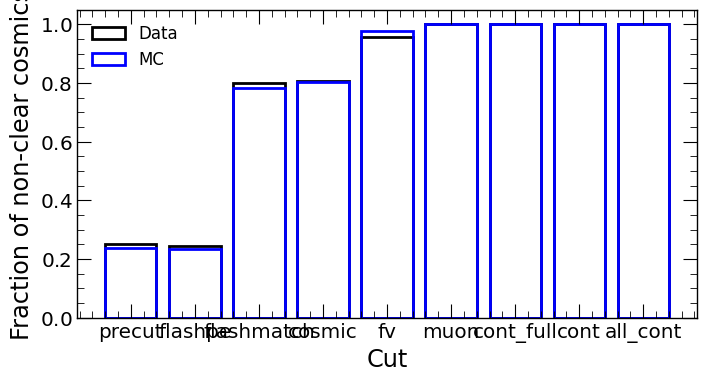

In [40]:
#Plot
fig,ax = plt.subplots(figsize=(8,4))
ax.bar(clear_cosmic_fracs.keys(),[frac[0] for frac in clear_cosmic_fracs.values()],fill=False)
ax.bar(clear_cosmic_fracs.keys(),[frac[1] for frac in clear_cosmic_fracs.values()],fill=False,edgecolor='blue')
ax.set_ylabel('Fraction of non-clear cosmics')
ax.set_xlabel('Cut')
ax.legend(['Data','MC'])

In [41]:
_slc = slc_mc.copy()
_slc.cut_all(cut=True,cont=True)

In [42]:
# Get fraction of each neutrino pdg
pdgs,counts = np.unique(_slc.data.truth.pdg,return_counts=True)
total = counts.sum()
print('pdgs, fraction')
for pdg,count in zip(pdgs,counts):
  print(f'{pdg}, {count/total*100:.2f}%')

pdgs, fraction
-14.0, 0.71%
-12.0, 0.01%
12.0, 0.30%
14.0, 98.01%
nan, 0.97%


In [43]:
# keys = ['mu.pfp.trk.is_flipped','mu.pfp.trk.dir.x','mu.pfp.trk.dir.y','mu.pfp.trk.dir.z','mu.pfp.trk.truth.p.dir.x','mu.pfp.trk.truth.p.dir.y','mu.pfp.trk.truth.p.dir.z']
# cols = _slc.get_key(keys)
# m = _slc.data.loc[:,cols[0]] == 1
# _slc.data.loc[m,cols].head(5)

### 6.1 Non-muon contamination

In [21]:
np.abs(_slc.data.mu.pfp.trk.truth.p.pdg).value_counts(normalize=True)

pdg
1.300000e+01    0.841037
2.110000e+02    0.103758
2.212000e+03    0.052993
2.147484e+09    0.001277
3.210000e+02    0.000397
2.200000e+01    0.000341
1.100000e+01    0.000118
1.000010e+09    0.000042
1.000020e+09    0.000019
1.000010e+09    0.000019
Name: proportion, dtype: float64

### 6.2 Energy

In [22]:
max_int32 = np.iinfo(np.int32).max
df = _slc.data
is_reco_cont = np.array(df.mu.pfp.trk.is_contained,dtype=bool)
is_flipped = np.array(df.mu.pfp.trk.is_flipped,dtype=bool)
mcs_col = ('mu', 'pfp', 'trk', 'mcsP', 'fwdP_muon', '', '', '', '')
csda_col =  ('mu', 'pfp', 'trk', 'rangeP', 'p_muon', '', '', '', '')
best_col = ('mu', 'pfp', 'trk', 'P', 'p_muon', '', '', '', '')
true_col = ('mu', 'pfp', 'trk', 'truth', 'p', 'totp', '', '', '')
is_true_muon = abs(df.mu.pfp.trk.truth.p.pdg == 13) | np.isclose(abs(df.mu.pfp.trk.truth.p.pdg),max_int32,atol=10,rtol=0)

In [23]:
mom_bins = MOMENTUM_BINS
mom_bins[-1] = MAX_PMOM


In [24]:
plot_configs = [
    {
        "name": "uncontained_reco_notflipped",
        "mask": ~is_reco_cont & (is_flipped == False),
        "label": None,
        "reco_key": mcs_col,
        "true_key": true_col,
        "bins": np.arange(0,2.05,0.05),
    },
    {
        "name": "uncontained_reco_flipped",
        "mask": ~is_reco_cont & (is_flipped == True),
        "label": None,
        "reco_key": mcs_col,
        "true_key": true_col,
        "bins": np.arange(0,2.05,0.05),
    },
    {
        "name": "uncontained_mcs",
        "mask": ~is_reco_cont,
        "label": None,
        "reco_key": mcs_col,
        "true_key": true_col,
        "bins": np.arange(0,2.05,0.05),
    },
    {
        "name": "contained_csda",
        "mask": is_reco_cont,
        "label": None,
        "reco_key": best_col,
        "true_key": true_col,
        "bins": np.arange(0,2.025,0.025),
    },
    {
        "name": "all",
        "mask": np.array([True]*len(df)),
        "label": None,
        "reco_key": best_col,
        "true_key": true_col,
        "bins": np.arange(0,2.05,0.05),
    },
    {
        "name": "all_match_bins",
        "mask": np.array([True]*len(df)),
        "label": None,
        "reco_key": best_col,
        "true_key": true_col,
        "bins": mom_bins,
    },
    {
        "name": "notflipped_mcs",
        "mask": (is_flipped == False),
        "label": None,
        "reco_key": mcs_col,
        "true_key": true_col,
        "bins": np.arange(0,2.05,0.05),
    },
    {
        "name": "flipped_mcs",
        "mask": (is_flipped == True),
        "label": None,
        "reco_key": mcs_col,
        "true_key": true_col,
        "bins": np.arange(0,2.05,0.05),
    },
    {
        "name": "mcs",
        "mask": np.array([True]*len(df)),
        "label": None,
        "reco_key": mcs_col,
        "true_key": true_col,
        "bins": np.arange(0,2.05,0.05),
    },
    {
        "name": "mcs_contained",
        "mask": is_reco_cont,
        "label": None,
        "reco_key": mcs_col,
        "true_key": true_col,
        "bins": np.arange(0,2.05,0.05),
    },
    {
        "name": "mcs_long",
        "mask": (df.mu.pfp.trk.len > 100),
        "label": None,
        "reco_key": mcs_col,
        "true_key": true_col,
        "bins": np.arange(0,2.05,0.05),
    },
]

In [25]:
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LogNorm
from sbnd.plotlibrary import makeplot

use_log = True
SAVE_PLOT = True

for config in plot_configs:
    print(config["name"])
    mask = config["mask"]
    print(f'filtering to {mask.sum()}/{len(df)} events')
    x = df.loc[mask, config["true_key"]]
    y = df.loc[mask, config["reco_key"]]
    if len(x) == 0 or len(y) == 0:
        continue
    xlabel = r'$p_{\mu,true}$ [GeV/c]'
    ylabel = r'$p_{\mu,reco}$ [GeV/c]'
    fig, (ax, ax2) = makeplot.plot_hist2d_frac_err(
        x, y,
        xlabel=xlabel,
        ylabel=ylabel,
        bins=config["bins"],
        #cmap=PID_COLOR_MAPS[config["pid"]],
        plot_line=True,
        norm=LogNorm() if use_log else None,
        colorbar=True,
        vmin=None if use_log else 0,
        normalize=True,
        use_errorbar=False,
        show_fit=False,
    )
    #Enforce a bias limit
    ylims = ax2.get_ylim()
    dgrid = 0.2
    if config["name"] == 'mcs_contained' or config["name"] == 'mcs':
      ax2.set_ylim([max(-.3,ylims[0]),min(.3,ylims[1])])
      # Fine grid
      for _x in np.arange(-3,3.+dgrid,dgrid):
        ax2.axhline(_x,ls='-',color='gray',alpha=0.2)
    else:
      #Coarse grid
      for _x in np.arange(-3,3.+dgrid,dgrid):
        ax2.axhline(_x,ls='-',color='gray',alpha=0.2)
    ax2.set_ylim([max(-1.,ylims[0]),min(1.,ylims[1])])
    #ax2.set_ylim([-1,1])

    #Add a stats box
    mbe = np.mean(x-y)
    mfe = np.mean((x-y)/x)
    mse = np.mean((x-y)**2)
    rms = np.sqrt(mse)
    var = np.var(x-y)
    std = np.std(x-y)
    mfe_std = np.std((x-y)/x)

    stats = r'MFE = '+ f'{mfe:.2f} ' + '\n' + fr'$\sigma$ = {mfe_std:.2f}'
    #plotters.add_label(ax2,stats,where='bottomrightoutside',color='black',size=12)

    #Set labels
    #ax.set_title(PID_LABELS[config["pid"]])
    ax.grid()
    ax2.grid()
    plotters.set_style(ax)
    plotters.add_label(ax,config["label"],where='topleft',color='black',size=12)

    if SAVE_PLOT:
        plot_dir = f'{PLOT_DIR}/resolution/momentum'
        if use_log:
            plot_dir += '_log'
        plotters.save_plot(f'momentum_resolution_{config["name"]}',fig=fig,folder_name=plot_dir)
        plt.close()

uncontained_reco_notflipped
filtering to 0/625050 events
uncontained_reco_flipped
filtering to 0/625050 events
uncontained_mcs
filtering to 0/625050 events
contained_csda
filtering to 625050/625050 events


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:878: RuntimeWarning: Mean of empty slice
  popt = [np.nan,np.nanmean(statistic),np.nanstd(statistic)]
/cvmfs/larsoft.opensciencegrid.org/spack-fnal-v1.0.0/opt/spack/linux-x86_64_v2/py-numpy-1.26.4-bjfwdigla2ihyygih63foelrl4jedvx2/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


all
filtering to 625050/625050 events
all_match_bins
filtering to 625050/625050 events
notflipped_mcs
filtering to 575331/625050 events
flipped_mcs
filtering to 49719/625050 events
mcs
filtering to 625050/625050 events
mcs_contained
filtering to 625050/625050 events
mcs_long
filtering to 344266/625050 events


### 6.2 Costheta

In [26]:
true_ct_col = ('mu', 'pfp', 'trk', 'truth', 'p', 'dir', 'z', '', '')
reco_ct_col = ('mu', 'pfp', 'trk', 'costheta', '', '', '', '', '')

In [27]:
plot_configs = [
    {
        "name": "reco_notflipped",
        "mask": (is_flipped == False),
        "label": None,
        "reco_key": reco_ct_col,
        "true_key": true_ct_col,
        "bins": np.arange(-1.,1.05,0.05),
    },
    {
        "name": "reco_flipped",
        "mask": (is_flipped == True),
        "label": None,
        "reco_key": reco_ct_col,
        "true_key": true_ct_col,
        "bins": np.arange(-1.,1.05,0.05),
    },
    {
        "name": "reco_contained",
        "mask": is_reco_cont,
        "label": None,
        "reco_key": reco_ct_col,
        "true_key": true_ct_col,
        "bins": np.arange(-1.,1.05,0.05),
    },
    {
        "name": "reco_exiting",
        "mask": (is_reco_cont == False),
        "label": None,
        "reco_key": reco_ct_col,
        "true_key": true_ct_col,
        "bins": np.arange(-1.,1.05,0.05),
    },
    {
        "name": "reco_match_bins",
        "mask": np.array([True]*len(df)),
        "label": None,
        "reco_key": reco_ct_col,
        "true_key": true_ct_col,
        "bins": COSTHETA_BINS,
    },
    {
        "name": "reco_match_bins_notflipped",
        "mask": (is_flipped == False),
        "label": None,
        "reco_key": reco_ct_col,
        "true_key": true_ct_col,
        "bins": COSTHETA_BINS,
    },
    {
        "name": "all",
        "mask": np.array([True]*len(df)),
        "label": None,
        "reco_key": reco_ct_col,
        "true_key": true_ct_col,
        "bins": np.arange(-1.,1.05,0.05),
    },
]

In [28]:
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LogNorm

use_log = True
SAVE_PLOT = True

for config in plot_configs:
    print(config["name"])
    mask = config["mask"]
    print(f'filtering to {mask.sum()}/{len(df)} events')
    x = df.loc[mask, config["true_key"]]
    y = df.loc[mask, config["reco_key"]]
    if len(x) == 0 or len(y) == 0:
        continue
    xlabel = r'$\cos\theta_{\mu,true}$'
    ylabel = r'$\cos\theta_{\mu,reco}$'
    fig, (ax, ax2) = makeplot.plot_hist2d_frac_err(
        x, y,
        xlabel=xlabel,
        ylabel=ylabel,
        bins=config["bins"],
        #cmap=PID_COLOR_MAPS[config["pid"]],
        plot_line=True,
        norm=LogNorm() if use_log else None,
        colorbar=True,
        vmin=None if use_log else 0,
        normalize=False,
        use_errorbar=False,
        show_fit=False,
    )
    #Enforce a bias limit
    ylims = ax2.get_ylim()
    # if config["name"] == 'mcs_contained' or config["name"] == 'mcs':
    #   ax2.set_ylim([max(-.3,ylims[0]),min(.3,ylims[1])])
    #   # Fine grid
    #   for _x in np.arange(-3,3.05,0.05):
    #     ax2.axhline(_x,ls='-',color='gray',alpha=0.2)
    # else:
    #   ax2.set_ylim([max(-2.,ylims[0]),min(2.,ylims[1])])
    #   #Coarse grid
    #   for _x in np.arange(-3,3.2,0.2):
    #     ax2.axhline(_x,ls='-',color='gray',alpha=0.2)
    #ax2.set_ylim([-1,1])

    #Add a stats box
    mbe = np.mean(x-y)
    mfe = np.mean((x-y)/x)
    mse = np.mean((x-y)**2)
    rms = np.sqrt(mse)
    var = np.var(x-y)
    std = np.std(x-y)
    mfe_std = np.std((x-y)/x)

    #stats = r'MFE = '+ f'{mfe:.2f} ' + '\n' + fr'$\sigma$ = {mfe_std:.2f}'
    #plotters.add_label(ax2,stats,where='bottomrightoutside',color='black',size=12)

    #Set labels
    #ax.set_title(PID_LABELS[config["pid"]])
    ax.grid()
    ax2.grid()
    plotters.set_style(ax)
    plotters.add_label(ax,config["label"],where='topleft',color='black',size=12)

    if SAVE_PLOT:
        plot_dir = f'{PLOT_DIR}/resolution/costheta'
        if use_log:
            plot_dir += '_log'
        plotters.save_plot(f'costheta_resolution_{config["name"]}',fig=fig,folder_name=plot_dir)
        plt.close()

reco_notflipped
filtering to 575331/625050 events
reco_flipped
filtering to 49719/625050 events
reco_contained
filtering to 625050/625050 events
reco_exiting
filtering to 0/625050 events
reco_match_bins
filtering to 625050/625050 events
reco_match_bins_notflipped
filtering to 575331/625050 events
all
filtering to 625050/625050 events


In [ ]:
4016/63975

0.06277452129738179

## 7. Momentum plots

In [ ]:
# Get cut slices
_slc = slc_mc.copy()
_slc.cut_all(cut=True)

_slc_data = slc_data.copy()
_slc_data.cut_all(cut=True)


ModuleNotFoundError: No module named 'cafpyana.cafclasses'

In [207]:
from sbnd.cafclasses.nu import NU
_mcnu = NU(mcnu.copy().data)
_mcnu.cut_all(cut=True)

Applied cut on key: cut.all (1,054,307 --> 171,804)


In [208]:
# Fix true momentum in the usual way
mask = (_slc.data.truth.mu.totp == -1) | (np.isnan(_slc.data.truth.mu.totp))
totp_col = _slc.get_key([f'mu.pfp.trk.truth.p.totp'])[0]
truth_totp_col = _slc.get_key([f'truth.mu.totp'])[0]
m2 = np.isnan(_slc.data.loc[:,totp_col])
if mask.sum() > 0:
  _slc.data.loc[mask,truth_totp_col] = _slc.data.loc[mask,totp_col]

In [209]:
_slc.add_tpc_containment()
_slc_data.add_tpc_containment()

bins = np.arange(0, 3.1, 0.1)
_slc.assign_bins(bins,'mu.pfp.trk.P.p_muon',assign_key='reco_mom_bin')
_slc.assign_bins(bins,'truth.mu.totp',assign_key='true_mom_bin')

In [247]:
# Add the cut before the breakdown
mode = 'tpc0'
if mode == 'exiting':
  mask = _slc.data.mu.pfp.trk.is_contained == False
  mask_data = _slc_data.data.mu.pfp.trk.is_contained == False
  title = 'Exiting'
  savename = 'pmu_exiting'
  savename_costheta = 'costheta_exiting'
elif mode == 'contained':
  mask = _slc.data.mu.pfp.trk.is_contained == True
  mask_data = _slc_data.data.mu.pfp.trk.is_contained == True
  title = 'Contained'
  savename = 'pmu_contained'
  savename_costheta = 'costheta_contained'
elif mode == 'tpc0':
  mask = _slc.data.mu.pfp.trk.cont_tpc0 == True
  mask_data = _slc_data.data.mu.pfp.trk.cont_tpc0 == True
  title = 'Contained in TPC0'
  savename = 'pmu_tpc0'
  savename_costheta = 'costheta_tpc0'
elif mode == 'tpc1':
  mask = _slc.data.mu.pfp.trk.cont_tpc1 == True
  mask_data = _slc_data.data.mu.pfp.trk.cont_tpc1 == True
  title = 'Contained in TPC1'
  savename = 'pmu_tpc1'
  savename_costheta = 'costheta_tpc1'
else:
  raise ValueError(f'Invalid mode: {mode}')

_slc_ = CAFSlice(_slc.data[mask])
_slc_data_ = CAFSlice(_slc_data.data[mask_data])

# Break data into lists of objects
_slcs = []

#Get event type col
slc_event_type_col = _slc_.get_key('truth.event_type')
#inter_event_type_col = inter.get_key('truth.event_type')

# Group data by event type once
slc_groups = _slc_.data.groupby(slc_event_type_col)
#inter_groups = inter.data.groupby(inter_event_type_col)

# Create objects only for groups that exist
for key, val in EVENT_TYPE_LIST.items():
    if key in slc_groups.groups:
        _slcs.append(CAFSlice(slc_groups.get_group(key)))

#Get label info
labels = []
names = []
colors = []

for key,item in EVENT_TYPE_LIST.items():
    if key == -1: #no unknown for now
        continue
    labels.append(item[0])
    names.append(item[1])
    colors.append(item[2])

_slc_weights = [s.data.genweight for s in _slcs]
#inter_weights = [i.data.genweight for i in inters]

#Assert no nans in weights
assert [any(np.isnan(sw)) for sw in _slc_weights].count(True) == 0

momentums = [s.data.mu.pfp.trk.P.p_muon for s in _slcs]
momentum = _slc_.data.mu.pfp.trk.P.p_muon
momentum_data = _slc_data_.data.mu.pfp.trk.P.p_muon
momentum_true = _slc_.data.truth.mu.totp

costhetas = [s.data.mu.pfp.trk.costheta for s in _slcs]
costheta = _slc_.data.mu.pfp.trk.costheta
costheta_data = _slc_data_.data.mu.pfp.trk.costheta
costheta_true = _slc_.data.truth.mu.dir.z

weights = _slc_.data.genweight

# Get purity and efficiency
#purs,effs,f1s,true_events,reco_events,binning = get_pur_eff_binned(_slc_,_mcnu,'true_mom_bin',['precut'])

In [248]:
fig, ax, ax2 = makeplot.create_hist_dataratio(
    momentums, labels, False,
    data_series=momentum_data,
    #cut_desc=cut_desc,
    xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
    label=INTERNAL_DATA_LABEL,
    colors=colors,
    weights=_slc_weights,
    bins=np.arange(0, 3.1, 0.1),
    savename=savename,
    plot_dir=f'{PLOT_DIR}/pandora_uncont/break_studies',
    #data_events=_data_events,
    show_counts=True,
    pot_label=POT_LABEL,
    title=title
)

fig,ax, ax2 = makeplot.create_hist_dataratio(
    costhetas, labels, False,
    data_series=costheta_data,
    xlabel=r'$\cos\theta_\mu$',
    label=INTERNAL_DATA_LABEL,
    colors=colors,
    weights=_slc_weights,
    bins=np.arange(-1,1.05,0.05),
    savename=savename_costheta,
    plot_dir=f'{PLOT_DIR}/pandora_uncont/break_studies',
    show_counts=True,
    pot_label=POT_LABEL,
    title=title
)

In [249]:
# Make smearing matrix
from sbnd.stats.stats import get_smear_matrix,convert_smearing_to_response
smearing = get_smear_matrix(momentum_true,momentum,bins,weights=weights)

# Plot smearing matrix
fig,ax = plt.subplots()
im = ax.pcolormesh(bins,bins,smearing.T,norm=LogNorm())
plt.colorbar(im,ax=ax)
ax.set_xlabel(r'True Momentum [GeV/c]')
ax.set_ylabel(r'Reconstructed Momentum [GeV/c]')
ax.set_title(f'{title} Smearing Matrix',fontsize=15)
plotters.save_plot(f'{savename}_smearing_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora_uncont/break_studies')
plt.close()

In [250]:
smearing_costheta = get_smear_matrix(costheta_true,costheta,np.arange(-1,1.05,0.05),weights=weights)
fig,ax = plt.subplots()
im = ax.pcolormesh(np.arange(-1,1.05,0.05),np.arange(-1,1.05,0.05),smearing_costheta.T,norm=LogNorm())
plt.colorbar(im,ax=ax)
ax.set_xlabel(r'True $\cos\theta_\mu$')
ax.set_ylabel(r'Reconstructed $\cos\theta_\mu$')
ax.set_title(f'{title} Smearing Matrix',fontsize=15)
plotters.save_plot(f'{savename_costheta}_smearing_matrix_costheta',fig=fig,folder_name=f'{PLOT_DIR}/pandora_uncont/break_studies')
plt.close()

## 8. Test CCQE backgrounds

### 7.1 Create breakdown

In [120]:
# Get full cut sample
# _slc = slc_mc.copy()
# _slc.cut_all(cut=True)

# Fix genie mode and iscc for cosmics
genie_mode_key = _slc.get_key('truth.genie_mode')
iscc_key = _slc.get_key('truth.iscc')
mask = _slc.data[genie_mode_key].isna().values.flatten()
_slc.data.loc[mask,genie_mode_key] = -1 # Set to -1 for cosmics
_slc.data.loc[mask,iscc_key] = 0 # Set to 0 for cosmics (false)

# Make a new column that is a combination of event type and genie mode
key = _slc.get_key('truth.event_type_genie_mode')
slc_event_type_col = _slc.get_key('truth.event_type')
m1 = _slc.data.truth.event_type.isin([0,1]).values.flatten()
inds = np.where(m1)[0]
non_inds = np.where(~m1)[0]

# Set signal to their event_type + offset. BG to genie_mode
values = np.zeros(_slc.data.shape[0])
values[inds] = (_slc.data.loc[m1,slc_event_type_col] + 1000).values.flatten()
# Offset cc by 10
print(len(non_inds),(~m1).sum())
values[non_inds] = (_slc.data.loc[~m1,genie_mode_key].values.flatten() + _slc.data.loc[~m1,iscc_key].values.flatten() * 100)
_slc.add_cols(['truth.event_type_genie_mode'],values=values)
slc_event_type_genie_mode_key = _slc.get_key('truth.event_type_genie_mode')

# Group by event type + genie mode
categories = np.sort(_slc.data.truth.event_type_genie_mode.unique())
slc_groups_cut = _slc.data.groupby(slc_event_type_genie_mode_key)

# Break data into lists of objects
slcs_cut = []
labels = []


# Create objects for groups that exist
df_lens = 0
for i, cat in enumerate(categories):
  df = slc_groups_cut.get_group(cat)
  df_lens += len(df)
  slcs_cut.append(CAFSlice(df))
  if cat == -1:
    name = 'Cosmic'
  elif cat >= 0 and cat < 100:
    name = 'NC' + GENIE_INTERACTION_MAP[cat][1]
  elif cat >= 100 and cat < 1000:
    name = 'CC' + GENIE_INTERACTION_MAP[cat-100][1]
  elif cat == 1000:
    name = EVENT_TYPE_LIST[cat-1000][0]
  labels.append(name)
  print(f'Category {cat} ({name}): {len(df)}')

assert df_lens == len(_slc.data), f'Not all events included. {df_lens} != {len(_slc.data)}'


26726 26726


/tmp/ipykernel_100754/2074617715.py:40: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df = slc_groups_cut.get_group(cat)


Category -1.0 (Cosmic): 17783
Category 0.0 (NCQE): 280
Category 1.0 (NCRes): 1949
Category 2.0 (NCDIS): 1265
Category 10.0 (NCMEC): 26
Category 100.0 (CCQE): 2743
Category 101.0 (CCRes): 1618
Category 102.0 (CCDIS): 556
Category 103.0 (CCCoh): 18
Category 110.0 (CCMEC): 488
Category 1000.0 ($\nu_\mu$ CC (cont.)): 60455
Category 1001.0 ($\nu_\mu$ CC (cont.)): 51152


### 7.2 Plotting

In [128]:
PLOT_DIR

'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint4'

In [142]:
# Extract series of variables we want
# Muon information
costheta = [s.data.mu.pfp.trk.costheta for s in slcs_cut]
momentum = [s.data.mu.pfp.trk.P.p_muon for s in slcs_cut]
bin2d = [s.data.bin.differential for s in slcs_cut]

true_costheta = [s.data.truth.mu.dir.z for s in slcs_cut]
true_momentum = [s.data.truth.mu.totp for s in slcs_cut]
true_bin2d = [s.data.true_bin.differential for s in slcs_cut]

# Get weights
_weights = [s.data.genweight for s in slcs_cut]

plot_dir = f'{PLOT_DIR}/pandora_uncont/bg_studies'

#Make bg plots
for ind_low,ind_name in zip([0,1],['','_nocosmic']):
  for dens,dens_name in zip([False,'stackfrac'],['raw','stackfrac']):
    #2D momentum and costheta - BG only
    figs,axs = makeplot.create_differential_stack(
      bin2d[ind_low:-2], labels[ind_low:-2], binning2d=binning2d,
      weights=_weights[ind_low:-2],
      xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
      label=INTERNAL_LABEL,
      pot_label=POT_LABEL,
      dens=dens,
      #colors=colors[2:],
      savename=f'differential_bgonly_{dens_name}{ind_name}',
      plot_dir=plot_dir
    )

    fig,axs = makeplot.create_differential_stack(
      true_bin2d[ind_low:-2], labels[ind_low:-2], binning2d=binning2d,
      weights=_weights[ind_low:-2],
      xlabel=r'True Bin ID',
      label=INTERNAL_LABEL,
      pot_label=POT_LABEL,
      dens=dens,
      savename=f'true_differential_binid_bgonly_{dens_name}{ind_name}',
      plot_dir=plot_dir
    )

    #2D momentum and costheta (in binID space) - BG only
    fig,ax = makeplot.create_hist(
      bin2d[ind_low:-2], labels[ind_low:-2],
      xlabel=r'Reconstructed Bin ID',
      label=INTERNAL_LABEL,
      weights=_weights[ind_low:-2],
      bins=binning2d.differential_edges,
      cut=cut,
      savename=f'differential_binid_bgonly_{dens_name}{ind_name}',
      plot_dir=plot_dir,
      dens=dens
    )

    fig,ax = makeplot.create_hist(
      true_bin2d[ind_low:-2], labels[ind_low:-2],
      bins=binning2d.differential_edges,
      weights=_weights[ind_low:-2],
      xlabel=r'True Bin ID',
      label=INTERNAL_LABEL,
      pot_label=POT_LABEL,
      dens=dens,
      savename=f'true_differential_binid_bgonly_{dens_name}{ind_name}',
      plot_dir=plot_dir,
      cut=cut
    )

    # Costheta
    fig,ax = makeplot.create_hist(
      costheta[ind_low:-2], labels[ind_low:-2],
      xlabel=r'Reconstructed $\cos\theta_\mu$',
      label=INTERNAL_LABEL,
      pot_label=POT_LABEL,
      weights=_weights[ind_low:-2],
      bins=syst_costheta_bins,
      cut=cut,
      savename=f'costheta_bgonly_{dens_name}{ind_name}',
      plot_dir=plot_dir,
      dens=dens
    )

    fig,ax = makeplot.create_hist(
      true_costheta[ind_low:-2], labels[ind_low:-2],
      xlabel=r'True $\cos\theta_\mu$',
      label=INTERNAL_LABEL,
      pot_label=POT_LABEL,
      weights=_weights[ind_low:-2],
      bins=syst_costheta_bins,
      cut=cut,
      savename=f'true_costheta_bgonly_{dens_name}{ind_name}',
      plot_dir=plot_dir,
      dens=dens
    )

    #Momentum
    fig,ax = makeplot.create_hist(
      momentum[ind_low:-2], labels[ind_low:-2],
      xlabel=r'Reconstructed $\mu$ Momentum [GeV/c]',
      label=INTERNAL_LABEL,
      weights=_weights[ind_low:-2],
      bins=syst_momentum_bins,
      cut=cut,
      savename=f'momentum_bgonly_{dens_name}{ind_name}',
      plot_dir=plot_dir,
      dens=dens,
      pot_label=POT_LABEL
    )

    fig,ax = makeplot.create_hist(
      true_momentum[ind_low:-2], labels[ind_low:-2],
      xlabel=r'True $\mu$ Momentum [GeV/c]',
      label=INTERNAL_LABEL,
      pot_label=POT_LABEL,
      weights=_weights[ind_low:-2],
      bins=syst_momentum_bins,
      cut=cut,
      savename=f'true_momentum_bgonly_{dens_name}{ind_name}',
      plot_dir=plot_dir,
      dens=dens
    )
    


## 8. Plot Q0, Enu, q3

In [287]:
_slc.data.bin

costheta momentum differential
                                                            
                                                            
                                                            
                                                            
                                                            
                                                            
                                                            
__ntuple entry rec.slc..index                               
0        0     0                     4      1.0         13.0
         2     4                     7      0.0          7.0
         6     0                     2      3.0         29.0
         15    2                     3      1.0         12.0
         16    0                     4      0.0          4.0
..                                 ...      ...          ...
9797     4     200000                2      3.0         29.0
9806     4     200000                4      2.0         22.0
9817     14    200000                7      3.0         34.0
9876     6     200000                3      1.0         12.0
9949     2     200001                3      0.0          3.0

[138333 rows x 3 columns]

### 8.1 Extract values

In [249]:
# Define bins
Q0BINS = [0.0, 0.05, 0.10, 0.20, 0.7, 10.0] # GeV
_Q0BINS = np.arange(0,10,0.05)

# Get full cut sample
# _slc = slc_mc.copy()
# _slc.cut_all(cut=True)

# Get values
y = _slc.data.slc.truth.inelasticityY
E = _slc.data.slc.truth.E
Q2 = _slc.data.slc.truth.Q2

# Add q0, q3
q0 = y * E
q3 = np.sqrt(Q2 + q0**2)
_slc.add_cols(['slc.truth.q0','slc.truth.q3'],values=[q0,q3])

# Assign q0 bin
_slc.assign_bins(Q0BINS,'bin.q0')

# Get event type col
slcs_cut_evt = []
slc_event_type_col = _slc.get_key('truth.event_type')
#inter_event_type_col = inter.get_key('truth.event_type')

# Group data by event type once
slc_groups_evt = _slc.data.groupby(slc_event_type_col)
#inter_groups = inter.data.groupby(inter_event_type_col)

# Create objects only for groups that exist
for key, val in EVENT_TYPE_LIST.items():
  if key in slc_groups_evt.groups:
      slcs_cut_evt.append(CAFSlice(slc_groups_evt.get_group(key)))

#slcs is already organized from section 3.
ys = [s.data.slc.truth.inelasticityY for s in slcs_cut_evt]
Es = [s.data.slc.truth.E for s in slcs_cut_evt]
Qs = [s.data.slc.truth.Q2 for s in slcs_cut_evt]
_weights = [s.data.genweight for s in slcs_cut_evt]

# y = q_0 / E_nu -> q_0 = y * E_nu
q0s = [y * E for y,E in zip(ys,Es)]

# q3 = sqrt(Q2 + q_0^2)
q3s = [np.sqrt(Q2 + q0**2) for Q2,q0 in zip(Qs,q0s)]

/tmp/ipykernel_100754/1433836431.py:15: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  slcs_cut_evt.append(CAFSlice(slc_groups_evt.get_group(key)))


In [250]:
Q0BINS[0:2]

[0.0, 0.05]

### 8.2 Plots from data

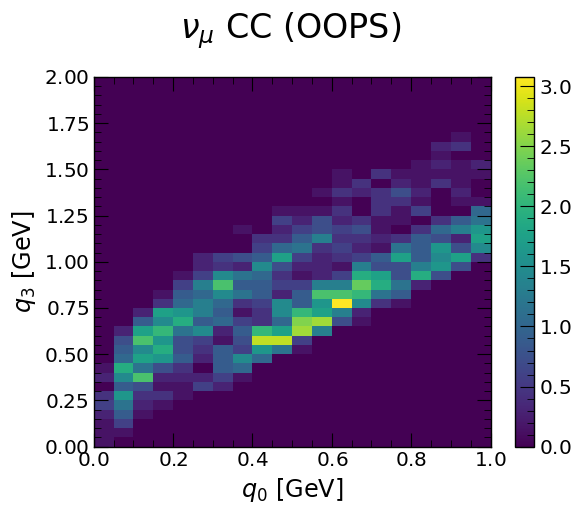

In [254]:
ind = 2
q0,q3,E,w = q0s[ind],q3s[ind],Es[ind],_weights[ind]

qind_low = 0
qind_high = qind_low + 1

# Turn on for q0 mask
#mask = (q0 < Q0BINS[qind_high]) & (q0 > Q0BINS[qind_low])
#mask_str = r'$q_0 \in $' + f'[{Q0BINS[qind_low]:.2f},{Q0BINS[qind_high]:.2f}]' + r' GeV'

mask = [True]*len(q0)
mask_str = ''

plot_dir = f'{PLOT_DIR}/pandora_uncont/bg_studies'
fig,ax = plt.subplots()
_,_,_,im = ax.hist2d(q0,q3,weights=w,bins=[_Q0BINS,_Q0BINS],cmap='viridis');
ax.set_ylim([0,2])
ax.set_xlim([0,1])
ax.set_xlabel(r'$q_0$ [GeV]')
ax.set_ylabel(r'$q_3$ [GeV]') 
fig.colorbar(im)
ax.set_title(f'{EVENT_TYPE_LIST[ind][0]} {mask_str}')
plotters.save_plot(f'{EVENT_TYPE_LIST[ind][1]}_q3q0',fig=fig,folder_name=plot_dir)

### 8.3 Plot from template

In [278]:
from sbnd.general import utils
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/bg_studies/CCQEReweight_templates_Ar23+.root'
#fname = '/exp/sbnd/data/users/munjung/ccqe_rw/CCQEReweight_templates.root'
tree = uproot.open(fname)
tree.keys()

th3_sf = tree['h_ENuq3q0_AR25_SF;1']
th3_cv = tree['h_ENuq3q0_AR23;1']

/tmp/ipykernel_100754/2204252309.py:11: RuntimeWarning: invalid value encountered in divide
  im = ax.pcolormesh(q0_edges,q3_edges,np_th3_sf[0]/np_th3_cv[0],cmap='viridis')


Text(0.5, 1.0, 'Weights')

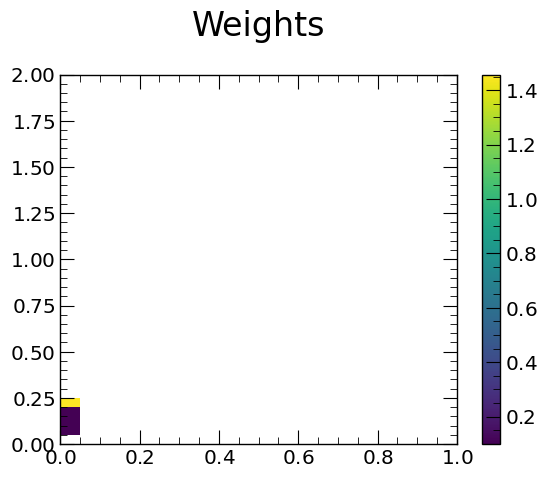

In [286]:
np_th3_sf = th3_sf.to_numpy()

enu_edges = np_th3_sf[1]
q3_edges = np_th3_sf[2]
q0_edges = np_th3_sf[3]

np_th3_cv = th3_cv.to_numpy()[0]
np_th3_sf = np_th3_sf[0]

fig,ax = plt.subplots()
im = ax.pcolormesh(q0_edges,q3_edges,np_th3_sf[0]/np_th3_cv[0],cmap='viridis')
fig.colorbar(im)
ax.set_xlim(0,1)
ax.set_ylim(0,2)
ax.set_title('Weights')

In [283]:
for i,th3 in enumerate([th3_sf,th3_cv]):
  if i == 0:
    title = r'SF AR25 $\frac{d^2\sigma}{dq_0dq_3}$'
  else:
    title = r'CV AR23 $\frac{d^2\sigma}{dq_0dq_3}$'

  np_th3 = th3.to_numpy()
  enu_edges = np_th3[1]
  q3_edges = np_th3[2]
  q0_edges = np_th3[3]
  np_th3 = np_th3[0]
  fig,ax = plt.subplots()
  q0_edges.shape,q3_edges.shape,np_th3.sum(axis=0).shape
  im = ax.pcolormesh(q0_edges,q3_edges,np_th3.sum(axis=0),cmap='viridis')
  fig.colorbar(im)
  ax.set_xlim(0,1)
  ax.set_ylim(0,2)
  ax.set_xlabel(r'$q_0$ [GeV]')
  ax.set_ylabel(r'$q_3$ [GeV]')
  ax.set_title(title)
  plt.close()
#plt.imshow(np_th3[0][0])

In [195]:
th3.member("fXaxis").member("fTitle")
th3.member("fYaxis").member("fTitle")
th3.member("fZaxis").member("fTitle")

'Axis 2'

## 10. Find ideal binning

### 10.1 Contained

In [276]:
_slc_signal = slc_mc.copy()
_slc_signal.cut_all(cut=True,mode='truth',cont=True)

In [383]:
diff_momentum_bins_2d = np.array([
  [0,0.25,0.3,0.4,1e10],
  [0,0.25,0.3,0.4,1e10],
  [0,0.25,0.3,0.4,1e10],
  [0,0.3,0.5,0.7,1e10],
  [0,0.3,0.5,0.7,1e10],
  [0,0.3,0.5,0.7,1e10],
  [0,0.4,0.6,0.8,1e10],
  [0,0.4,0.6,0.8,1e10],
  [0,0.4,0.6,0.8,1e10],
  ])
momentum_bins = np.array([0,0.2,0.3,0.4,0.5,0.6,0.7,0.8,1.,1e10])
len(momentum_bins),len(COSTHETA_BINS)

(10, 10)

In [384]:
# Fix the costheta and momentum for slices that don't have a true muon
mask = (_slc_signal.data.truth.mu.dir.z == -1) | (np.isnan(_slc_signal.data.truth.mu.dir.z))
dir_col = _slc_signal.get_key([f'mu.pfp.trk.truth.p.dir.z'])[0]
truth_dir_col = _slc_signal.get_key([f'truth.mu.dir.z'])[0]
_slc_signal.data.loc[mask,truth_dir_col] = _slc_signal.data.loc[mask,dir_col]

mask = (_slc_signal.data.truth.mu.totp == -1) | (np.isnan(_slc_signal.data.truth.mu.totp))
totp_col = _slc_signal.get_key([f'mu.pfp.trk.truth.p.totp'])[0]
truth_totp_col = _slc_signal.get_key([f'truth.mu.totp'])[0]
m2 = np.isnan(_slc_signal.data.loc[:,totp_col])
if mask.sum() > 0:
  _slc_signal.data.loc[mask,truth_totp_col] = _slc_signal.dåata.loc[mask,totp_col]

_slc_signal.add_2d_binning(momentum_bins=momentum_bins,momentum_bins_2d=diff_momentum_bins_2d,
  include_truth = True)
_binning2d = Binning2D(diff_momentum_bins_2d=diff_momentum_bins_2d)

In [385]:
np.unique(_slc_signal.data.truth.event_type)

array([0])

In [386]:
hist2d,diff_bins = np.histogram(_slc_signal.data.bin.differential,
weights=_slc_signal.data.genweight,
bins=_binning2d.differential_edges)
hist2d,diff_bins

(array([  0.        , 229.04509199, 201.34866052, 102.72591778,
        317.99606502, 324.29736953, 277.40394059, 417.79114349,
        375.88014137, 271.54226197, 186.40138005, 214.53743741,
        146.83504938, 673.50687319, 735.49412458, 684.35097864,
        457.79710006, 371.19079848, 206.77071325, 168.3767183 ,
        334.55530712, 336.02072677, 230.95013754, 405.18853446,
        498.82885038, 344.22707683, 334.55530712, 175.26419067,
         71.07285324, 147.71430117, 340.41698573,  19.34353944,
         82.21004262, 221.57145176, 178.63465588, 233.88097685,
        146.83504938]),
 array([-1.5, -0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,
         9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5,
        20.5, 21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5,
        31.5, 32.5, 33.5, 34.5, 35.5]))

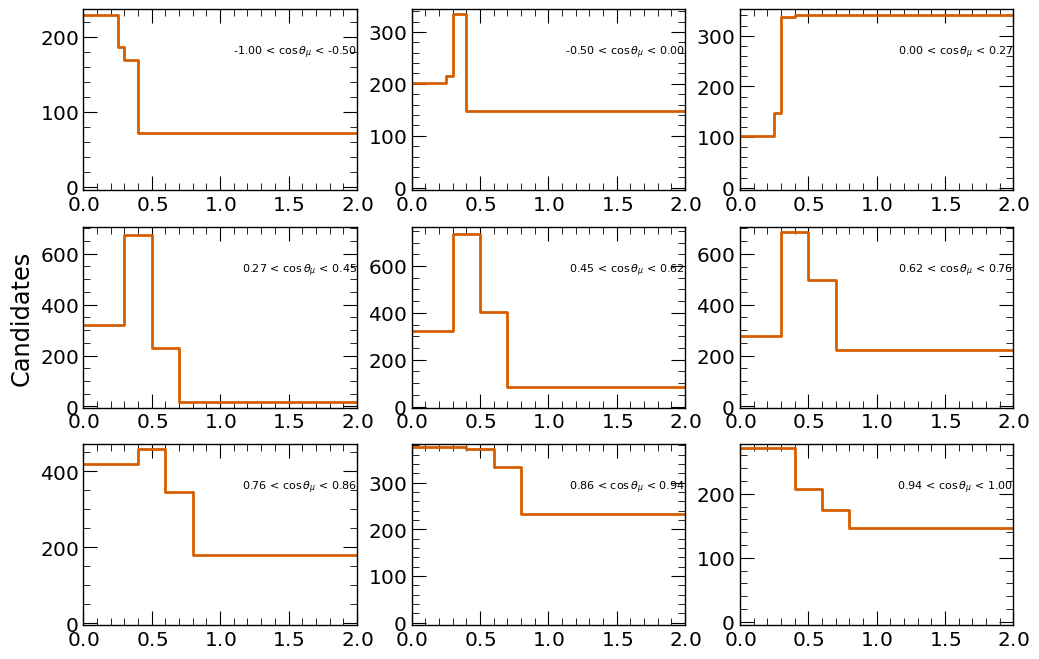

In [387]:
fig,axs = _binning2d.plot_differential_hist_binned(hist2d,ylabel='Candidates',add_labels=True,legend=False)
for ax in axs.flatten():
  ax.set_ylim([-5,None])


In [ ]:
_slc_signal.data.describe()

: 

: 

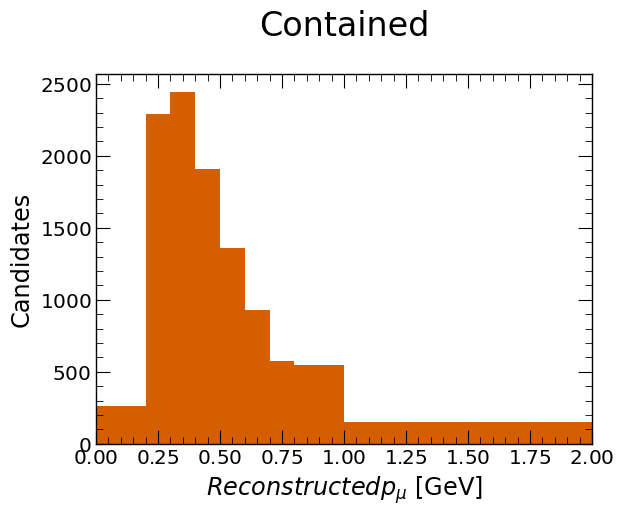

In [388]:
fig,ax = plt.subplots()
ax.hist(_slc_signal.data.mu.pfp.trk.P.p_muon,bins=momentum_bins,weights=_slc_signal.data.genweight)
ax.set_xlabel(r'$Reconstructed p_\mu$ [GeV]')
ax.set_ylabel(r'Candidates')
ax.set_title('Contained')
ax.set_xlim([0,2])
fig.show()


## 11. 2D plot of muon start/end points

In [119]:
NOT_FV_HIGH_Z

[[-190, 0], [100, 190], [250, 450]]

In [120]:
_slc_mc = slc_mc.copy()
_slc_data = slc_data.copy()

_slc_mc.cut_all(cut=True,mode='reco',cont=True)
_slc_data.cut_all(cut=True,mode='reco',cont=True)

In [121]:
from matplotlib.colors import TwoSlopeNorm

In [122]:
#Fill these in
view = 'yz'
xbins = np.arange(-200,250,50)
ybins = np.arange(-200,250,50)
zbins = np.arange(0,550,50)
TPC_MASK = None
display_mode = 'start' #Vertex, start, end
hist_mode = 'data' #ratio, mc, data, diff

for hist_mode in ['ratio','data']:
  for view in ['yz','xz','xy']:
    for display_mode in ['start','end']:
      for TPC_MASK in [None,0,1]:
        if display_mode == 'vertex':
          keys = ['slc.vertex.x','slc.vertex.y','slc.vertex.z']
          title = 'Vertex'
          fname = f'vertex_{view}_{hist_mode}_tpc{str(TPC_MASK)}'
          folder = f'vertex'
        elif display_mode == 'start':
          keys = ['mu.pfp.trk.start.x','mu.pfp.trk.start.y','mu.pfp.trk.start.z']
          title = 'Muon Start'
          fname = f'start_{view}_{hist_mode}_tpc{str(TPC_MASK)}'
          folder = f'start'
        elif display_mode == 'end':
          keys = ['mu.pfp.trk.end.x','mu.pfp.trk.end.y','mu.pfp.trk.end.z']
          title = 'Muon End'
          fname = f'end_{view}_{hist_mode}_tpc{str(TPC_MASK)}'
          folder = f'end'
        cols = _slc_mc.get_key(keys)

        if view == 'yz':
          _xbins = ybins.copy()
          _ybins = zbins.copy()
          x = _slc_mc.data.loc[:,cols[1]]
          y = _slc_mc.data.loc[:,cols[2]]

          x_data = _slc_data.data.loc[:,cols[1]]
          y_data = _slc_data.data.loc[:,cols[2]]
          data_weights = _slc_data.data.genweight

          x_label = 'Y [cm]'
          y_label = 'Z [cm]'
        elif view == 'xz':
          _xbins = xbins.copy()
          _ybins = zbins.copy()
          x = _slc_mc.data.loc[:,cols[0]]
          y = _slc_mc.data.loc[:,cols[2]]

          x_data = _slc_data.data.loc[:,cols[0]]
          y_data = _slc_data.data.loc[:,cols[2]]

          x_label = 'X [cm]'
          y_label = 'Z [cm]'
        elif view == 'xy':
          _xbins = xbins.copy()
          _ybins = ybins.copy()
          x = _slc_mc.data.loc[:,cols[0]]
          y = _slc_mc.data.loc[:,cols[1]]

          x_data = _slc_data.data.loc[:,cols[0]]
          y_data = _slc_data.data.loc[:,cols[1]]

          x_label = 'X [cm]'
          y_label = 'Y [cm]'
        weights = _slc_mc.data.genweight
        data_weights = _slc_data.data.genweight
        if TPC_MASK is not None:
          if TPC_MASK == 0:
            mask = involume(_slc_mc.data.slc.vertex,TPC0)
            mask_data = involume(_slc_data.data.slc.vertex,TPC0)
            title += ' TPC0'
          elif TPC_MASK == 1:
            mask = involume(_slc_mc.data.slc.vertex,TPC1)
            mask_data = involume(_slc_data.data.slc.vertex,TPC1)
            title += ' TPC1'
          x = x[mask]
          y = y[mask]

          x_data = x_data[mask_data]
          y_data = y_data[mask_data]

          weights = weights[mask]
          data_weights = data_weights[mask_data]
        
        #Get histograms
        hist_mc,xedges,yedges = np.histogram2d(x,y,weights=weights,bins=[_xbins,_ybins])
        hist_data,_,_ = np.histogram2d(x_data,y_data,weights=data_weights,bins=[_xbins,_ybins])

        cmap = 'viridis'
        norm = None
        if hist_mode == 'ratio':
          hist = hist_data/hist_mc
          title += ' data/mc'
          cmap = 'berlin'
          norm = TwoSlopeNorm(vmin=0,
            vcenter=1.,
            vmax=2)  # tweak range
        elif hist_mode == 'mc':
          hist = hist_mc
          title += ' MC'
        elif hist_mode == 'data':
          hist = hist_data
          title += ' Data'
        elif hist_mode == 'diff':
          hist = hist_mc - hist_data
          title += ' Difference'

        fig,ax = plt.subplots()
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(title,fontsize=16)
        im = ax.pcolormesh(_xbins,_ybins,hist.T,cmap=cmap,norm=norm)
        plotters.add_label(ax,POT_LABEL,where='toprightoutside')
        plotters.add_label(ax,INTERNAL_LABEL,where='topleftoutside')
        fig.colorbar(im)
        plotters.save_plot(fname,fig=fig,folder_name=f'{PLOT_DIR}/2d_hists_50cm/{folder}')
        plt.close()
    #     break
    #   break
    # break

## 12. Find runs of interest

### 12.1 Volume filtering

In [23]:
_slc_data = slc_data.copy()

_slc_data.cut_all(cut=True,mode='reco',cont=True)

In [ ]:
from sbnd.detector.definitions import *
from sbnd.cafclasses.volume import involume

In [63]:
region = 'midz_lowy' #options are midz_lowy, highy_lowz, highx, highy_highz

start = _slc_data.data.mu.pfp.trk.start
end = _slc_data.data.mu.pfp.trk.end
cols = _slc_data.get_key(['run','subrun','evt',
  'mu.pfp.trk.start.x','mu.pfp.trk.start.y','mu.pfp.trk.start.z',
  'mu.pfp.trk.end.x','mu.pfp.trk.end.y','mu.pfp.trk.end.z',
  'mu.pfp.trk.phi',
  'mu.pfp.trk.theta',
  'mu.pfp.trk.len',
  'slc.num_primary_particles'])
for region in ['highy_lowz','highx','highy_highz','midz_lowy','highx_tpc0','highx_tpc1','highy_lowz']:
  if region == 'midz_lowy':
    volume = NOT_FV_MIDZ_LOWY1
    run_fname = 'midz_lowy_runs.txt'
  elif region == 'highy_lowz':
    volume = NOT_FV_HIGHY_LOWZ1
    run_fname = 'highy_lowz_runs.txt'
  elif region == 'highx_tpc1':
    # Just tpc 1 high x
    volume = [
      [180,190],
      [-200,200],
      [0,500]
    ]
    run_fname = 'highx_tpc1_runs.txt'
  elif region == 'highx_tpc0':
    # Just tpc 0 high x
    volume = [
      [-190,-180],
      [-200,200],
      [0,500]
    ]
    run_fname = 'highx_tpc0_runs.txt'
  elif region == 'highy_highz':
    volume = NOT_FV_HIGH_Z
    run_fname = 'highy_highz_runs.txt'
  startmask = involume(start,volume)
  #endmask = involume(end,volume)
  num_primary_mask = _slc_data.data.slc.num_primary_particles <= 1
  mask = startmask | endmask
  mask = mask & num_primary_mask
  with open(f'/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/logs/{run_fname}','w') as f:
    rse_list = _slc_data.data.loc[mask,cols[:3]].values.astype(int).tolist()
    # Sort by run, subrun, evt
    rse_list.sort(key=lambda x: (x[0],x[1],x[2]))
    for run,subrun,evt in rse_list:
      f.write(f'{run} {subrun} {evt}\n')

In [66]:
r,s,e = 18255, 1, 161542
rse_mask = (_slc_data.data.run == r) & (_slc_data.data.subrun == s) & (_slc_data.data.evt == e)
_slc_data.data.loc[rse_mask,cols].iloc[0]

run                                                      18255.000000
subrun                                                       1.000000
evt                                                     161542.000000
mu      pfp                    trk  start  x               150.154312
                                           y              -123.765366
                                           z               257.947052
                                    end    x                30.099295
                                           y              -104.310020
                                           z               369.626923
                                    phi                     -1.410139
                                    theta                    0.834724
                                    len                    166.343124
slc     num_primary_particles                                1.000000
Name: (56003, 33, 2), dtype: float64

In [59]:
# Find and _slc_data where multiple rse exist
_slc_data.data.loc[:,cols].duplicated().sum()

0

## Testing

In [5]:
from sbnd.cafclasses.pfp import PFP
fname = f'{DATA_DIR}/mc_syst/v9/mcbnb_tinypand_nosyst_nocuts_recomb3.df'
dumbslc = CAFSlice.load(fname,key=PAND_KEY,cuts=PAND_CUTS_CONT)
dumbpfp = PFP.load(fname,key=PFP_KEY)
#dumbslc.data.keys()
#dumbpfp.data.keys()


Loading combined CAF:   0%|          | 0/5 [00:00<?, ?it/s]

Applied cut on key: cut.flashpe (14,367 --> 10,249)
Applied cut on key: cut.flashmatch (10,249 --> 1,466)
Applied cut on key: cut.cosmic (1,466 --> 1,146)
Applied cut on key: cut.fv (1,146 --> 649)
Applied cut on key: cut.muon (649 --> 451)


Loading combined CAF:  20%|██        | 1/5 [00:04<00:16,  4.23s/it]

Applied cut on key: cut.cont_full (451 --> 155)
Applied cut on key: cut.cont (155 --> 154)
Applied cut on key: cut.all_cont (154 --> 123)
Applied cut on key: cut.flashpe (15,437 --> 11,070)
Applied cut on key: cut.flashmatch (11,070 --> 1,543)
Applied cut on key: cut.cosmic (1,543 --> 1,203)
Applied cut on key: cut.fv (1,203 --> 725)


Loading combined CAF:  40%|████      | 2/5 [00:08<00:13,  4.35s/it]

...

Loading combined CAF:  80%|████████  | 4/5 [00:16<00:04,  4.07s/it]

Applied cut on key: cut.cont_full (487 --> 154)
Applied cut on key: cut.cont (154 --> 154)
Applied cut on key: cut.all_cont (154 --> 114)
Applied cut on key: cut.flashpe (15,209 --> 10,716)
Applied cut on key: cut.flashmatch (10,716 --> 1,511)
Applied cut on key: cut.cosmic (1,511 --> 1,174)


Loading combined CAF: 100%|██████████| 5/5 [00:20<00:00,  4.14s/it]

Applied cut on key: cut.fv (1,174 --> 666)
Applied cut on key: cut.muon (666 --> 453)
Applied cut on key: cut.cont_full (453 --> 139)
Applied cut on key: cut.cont (139 --> 139)
Applied cut on key: cut.all_cont (139 --> 108)



Loading combined CAF: 100%|██████████| 5/5 [00:00<00:00,  9.67it/s]


In [6]:
cols = dumbslc.get_key(['slc.num_primary_particles','slc.reco.npfp'])
#dumbslc.data.loc[:,cols[0]].values - dumbslc.data.loc[:,cols[1]].values
vals,counts = np.unique(np.array(dumbslc.data.loc[:,cols[1]].values - dumbslc.data.loc[:,cols[0]].values - 1),return_counts=True)

In [7]:
print(f'n_daughters, n_slices')
for val,count in zip(vals,counts):
  print(f'  {int(val)} \t\t {int(count)}')

n_daughters, n_slices
  0 		 438
  1 		 156
  2 		 23
  3 		 1


In [73]:
cols = slc_mc.get_key(['run', 'subrun', 'evt', 'slc.vertex.x','slc.vertex.y','slc.vertex.z'])
rse = slc_mc.data[cols].apply(tuple, axis=1)

dup_mask = rse.duplicated(keep=False)
dups = slc_mc.data.loc[dup_mask].copy()
dups['_rse'] = rse[dup_mask]
dups
dups.sort_values('_rse')

for rse_val, grp in dups.groupby('_rse'):
  print('=' * 60, rse_val, f'n={len(grp)}')
  display(grp[cols])   # or print(grp) if no IPython
  break

============================================================ (20.0, 32.0, 6.0, 2.683988332748413, -181.27633666992188, 133.56204223632812) n=13


run subrun  evt       slc              \
                                                   vertex               
                                                        x           y   
                                                                        
                                                                        
                                                                        
                                                                        
                                                                        
                                                                        
__ntuple entry rec.slc..index                                           
581000   119   0               20.0     32  6.0  2.683988 -181.276337   
581003   119   0               20.0     32  6.0  2.683988 -181.276337   
581006   119   0               20.0     32  6.0  2.683988 -181.276337   
581009   119   0               20.0     32  6.0  2.683988 -181.276337   
581012   119   0               20.0     32  6.0  2.683988 -181.276337   
581015   119   0               20.0     32  6.0  2.683988 -181.276337   
581018   119   0               20.0     32  6.0  2.683988 -181.276337   
581021   119   0               20.0     32  6.0  2.683988 -181.276337   
581024   119   0               20.0     32  6.0  2.683988 -181.276337   
581027   119   0               20.0     32  6.0  2.683988 -181.276337   
581030   119   0               20.0     32  6.0  2.683988 -181.276337   
581033   119   0               20.0     32  6.0  2.683988 -181.276337   
581036   119   0               20.0     32  6.0  2.683988 -181.276337   

                                           
                                           
                                        z  
                                           
                                           
                                           
                                           
                                           
                                           
__ntuple entry rec.slc..index              
581000   119   0               133.562042  
581003   119   0               133.562042  
581006   119   0               133.562042  
581009   119   0               133.562042  
581012   119   0               133.562042  
581015   119   0               133.562042  
581018   119   0               133.562042  
581021   119   0               133.562042  
581024   119   0               133.562042  
581027   119   0               133.562042  
581030   119   0               133.562042  
581033   119   0               133.562042  
581036   119   0               133.562042

In [78]:
len(DATA_OFFBEAM_FNAMES)

500

In [77]:
__slc_mc = CAFSlice.load(DATA_OFFBEAM_FNAMES[0:50],
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=None,
  show_progress=True
)
#__slc_mc.data.slc.is_clear_cosmic.unique(return_counts=True)

Loading combined CAF:   0%|          | 0/50 [00:00<?, ?it/s]

Loading combined CAF: 100%|██████████| 50/50 [00:08<00:00,  6.19it/s]


In [80]:
cols = slc_data.get_key(['run', 'subrun', 'evt', 'slc.vertex.x','slc.vertex.y','slc.vertex.z'])
rse = slc_data.data[cols].apply(tuple, axis=1)

dup_mask = rse.duplicated(keep=False)
dups = slc_data.data.loc[dup_mask].copy()
dups['_rse'] = rse[dup_mask]
dups
dups.sort_values('_rse')

for rse_val, grp in dups.groupby('_rse'):
  print('=' * 60, rse_val, f'n={len(grp)}')
  display(grp[cols])   # or print(grp) if no IPython
  break

In [60]:
s = __slc_mc.copy()
for i,cut in enumerate(PAND_CUTS_CONT):
  print(f'Before - {cut} {np.unique(s.data.slc.is_clear_cosmic,return_counts=True)}')
  s.apply_cut(cut,cut=True)
  if cut == 'cont': break
  # if len(np.unique(s.data.slc.is_clear_cosmic)) == 1:
  #   print(f'After - {cut} {np.unique(s.data.slc.is_clear_cosmic,return_counts=True)}')
  #   break


Before - flashpe (array([0, 1], dtype=int8), array([ 584674, 1686127]))
Applied cut on key: cut.flashpe (2,270,801 --> 1,617,079)
Before - flashmatch (array([0, 1], dtype=int8), array([ 411952, 1205127]))
Applied cut on key: cut.flashmatch (1,617,079 --> 227,680)
Before - cosmic (array([0, 1], dtype=int8), array([207523,  20157]))
Applied cut on key: cut.cosmic (227,680 --> 176,630)
Before - fv (array([0, 1], dtype=int8), array([165877,  10753]))
Applied cut on key: cut.fv (176,630 --> 99,016)
Before - muon (array([0, 1], dtype=int8), array([96866,  2150]))
Applied cut on key: cut.muon (99,016 --> 67,912)
Before - cont_full (array([0], dtype=int8), array([67912]))
Applied cut on key: cut.cont_full (67,912 --> 32,857)
Before - cont (array([0], dtype=int8), array([32857]))
Applied cut on key: cut.cont (32,857 --> 25,211)


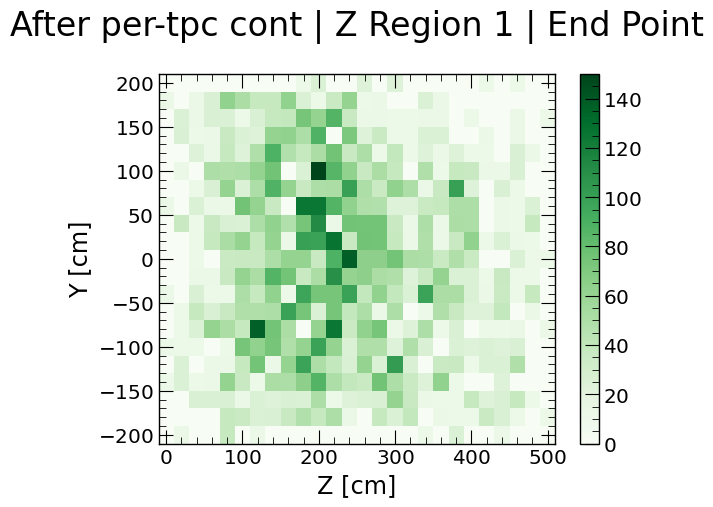

In [65]:
fig,ax = plt.subplots()
x_region1 = (np.abs(s.data.slc.vertex.x) > 5) & (np.abs(s.data.slc.vertex.x) < 190)
z_region1 = (s.data.slc.vertex.z > 10) & (s.data.slc.vertex.z < 250) & (np.abs(s.data.slc.vertex.y) < 190)
z_region2 = (s.data.slc.vertex.z > 250) & (s.data.slc.vertex.z < 450) & (s.data.slc.vertex.y > -190) & (s.data.slc.vertex.y < 100)
z_region3 = (s.data.slc.vertex.z > 250) & (s.data.slc.vertex.z < 450) & (s.data.slc.vertex.y > 100) & (s.data.slc.vertex.y < 190)
im = ax.hist2d(s.data[z_region1].mu.pfp.trk.end.z,
  s.data[z_region1].mu.pfp.trk.end.y,
  weights=s.data[z_region1].genweight,
  bins=[np.arange(-10,530,20),np.arange(-210,230,20)])
ax.set_xlabel('Z [cm]')
ax.set_ylabel('Y [cm]')
ax.set_title('After per-tpc cont | Z Region 1 | End Point')
fig.colorbar(im[3])
plt.show()

In [46]:
keys = ['slc.truth.mu.genE','slc.truth.nmu_100MeV']
cols = slc_mc.get_key(keys)
m = ~np.isnan(slc_mc.data.slc.truth.nmu_100MeV)
m2 = slc_mc.data.slc.truth.nmu_100MeV > 0
np.min(slc_mc.data.loc[m&m2,cols[0]]-kMuonMass)

0.0993704

TypeError: scatter() missing 1 required positional argument: 'y'

In [346]:
caf_fnames = []
with open('/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/v7/dataonbeam.list','r') as f:
  for line in f:
    caf_fnames.append(line.strip())

caf_fnames[0]

'/pnfs/sbn/data_add/sbn_nd/poms_production/data/MCP2025C/v10_06_00_09/Spring25_reprocess_Dev1e20_bnblight/flatcaf/bnblight/bb/reco2_reco1_filtered_decoded-raw_filtered_data_EventBuilder6_art1_run18342_25_strmBNBLight_20250322T143219-bb27c2c6-7b2e-3d6a-8105-5b4fb9115db4.flat.caf.root'

In [354]:
for ind in tqdm(range(len(caf_fnames))):
  caf_fname = caf_fnames[ind]
  g_xroot = caf_fname.replace("/pnfs", "root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr")
  tree = uproot.open(g_xroot)['recTree']
  keys = ['rec.slc.barycenterFM.flashPEs']
  df = tree.arrays(keys,library='pd')
  if len(df) > 0:
    break

  0%|          | 0/8698 [00:00<?, ?it/s]

  0%|          | 11/8698 [00:21<4:46:55,  1.98s/it]


In [355]:
df.head()

,rec.slc.barycenterFM.flashPEs
0,"[3229.844970703125, -9999.0, 3229.844970703125..."
1,"[8419.712890625, 1477.5244140625, 1477.5244140..."
2,"[30851.3828125, 30851.3828125, 30851.3828125, ..."
3,"[717.419189453125, -9999.0, -9999.0, -9999.0, ..."
4,"[180.00265502929688, 9578.154296875, 9578.1542..."


In [351]:
mc_pand_keys

['evt_pand_0',
 'evt_pand_1',
 'evt_pand_2',
 'evt_pand_3',
 'evt_pand_4',
 'evt_pand_5',
 'evt_pand_6']

In [358]:
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/v7/dataonbeam_run1blind_nocuts_small.df'
_slc_data = CAFSlice.load(fname,key='evt_pand_0')
#_slc_data.data.keys()
_slc_data.data

slc                          \
                              is_clear_cosmic      vertex               
                                                        x           y   
                                                                        
                                                                        
                                                                        
                                                                        
                                                                        
                                                                        
__ntuple entry rec.slc..index                                           
11       0     0                            0  -22.605539  164.886276   
               1                            0   40.931522   46.010612   
               2                            0   -8.047956  137.681458   
               3                            1  102.724121  200.861938   
         1     0                            0   31.258043  175.016449   
..                                        ...         ...         ...   
13       4     3                            1  -33.399658  -68.021202   
               4                            1  -35.785988  201.741913   
               5                            1   33.331627   98.146866   
               6                            1  -33.393272  157.535461   
               7                            1 -221.774048 -148.125443   

                                                                    \
                                          tmatch          nu_score   
                                        z    eff pur idx             
                                                                     
                                                                     
                                                                     
                                                                     
                                                                     
                                                                     
__ntuple entry rec.slc..index                                        
11       0     0                71.179611    NaN NaN NaN  0.515426   
               1                73.611870    NaN NaN NaN  0.310072   
               2               476.767212    NaN NaN NaN  0.415631   
               3               256.073486    NaN NaN NaN -1.000000   
         1     0               377.844269    NaN NaN NaN  0.569786   
..                                    ...    ...  ..  ..       ...   
13       4     3               429.669556    NaN NaN NaN -1.000000   
               4               133.712601    NaN NaN NaN -1.000000   
               5               305.657990    NaN NaN NaN -1.000000   
               6               340.253052    NaN NaN NaN -1.000000   
               7               342.552307    NaN NaN NaN -1.000000   

                                                      ...    cut             \
                              barycenterFM            ...  truth flashmatch   
                                 flashTime     score  ... cosmic              
                                                      ...                     
                                                      ...                     
                                                      ...                     
                                                      ...                     
                                                      ...                     
                                                      ...                     
__ntuple entry rec.slc..index                         ...                     
11       0     0                 -0.714285  0.000001  ...   True      False   
               1                       NaN       NaN  ...   True      False   
               2                 -0.714285  0.219139  ...   True       True   
          

In [ ]:
dirt_fraccov_fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4/syst/bg_studies/dirt/CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4/differential_xsec_fraccov.csv'
numucc_fraccov_fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4/syst/bg_studies/numucc/CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4/differential_xsec_fraccov.csv'
oops_fraccov_fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint4/syst/bg_studies/numucc_oops/CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4/differential_xsec_fraccov.csv'

dirt_fraccov = np.loadtxt(dirt_fraccov_fname)
numucc_fraccov = np.loadtxt(numucc_fraccov_fname)
oops_fraccov = np.loadtxt(oops_fraccov_fname)

max_val = np.max([dirt_fraccov,numucc_fraccov,oops_fraccov])
min_val = np.min([dirt_fraccov,numucc_fraccov,oops_fraccov])

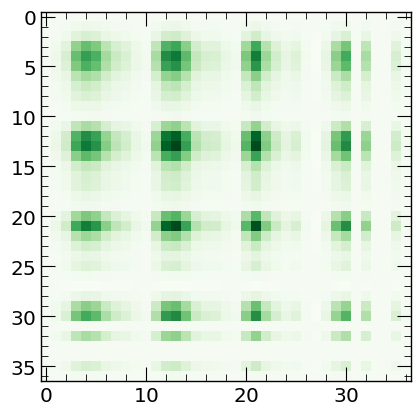

In [ ]:
fig,ax = plt.subplots()
ax.imshow(dirt_fraccov,vmin=min_val,vmax=max_val)

fig.colorbar(ax)

In [58]:
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/mc_tinypand_slimsyst_nocuts_norecomb3.df'
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/mc_tinypand_fullsyst_cut_norecomb3.df'
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/mc_tinypand_nosyst_nocuts_recomb3.df'
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v7/mc_tinypand_fullsyst_cut_norecomb.df'
import h5py
with h5py.File(fname,'r') as f:
  root_keys = list(f.keys())
  print(f"Keys at the root level: {root_keys}")


Keys at the root level: ['evt_pand_selected_0', 'evt_pand_signal_0', 'hdr_0', 'mcnu_0', 'split']


In [59]:
df = pd.read_hdf(fname,key=root_keys[1])
# with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/slc_keys3.txt','w') as f:
#   for key in list(df.keys()):
#     f.write(f'{key}\n')

In [65]:
mask = df.truth.genie_mode != 0
np.unique(df[mask].truth.ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b1.cv,return_counts=True)

(array([1.]), array([242]))

In [111]:
keys = [
    "rec.hdr.pot",
    "rec.hdr.first_in_subrun",
    "rec.hdr.ismc",
    "rec.hdr.run",
    "rec.hdr.subrun",
    "rec.hdr.ngenevt",
    "rec.hdr.evt",
    "rec.hdr.proc",
    "rec.hdr.cluster",
    "rec.hdr.fno",
    "rec.hdr.noffbeambnb",
    #"rec.hdr.bnbinfo",
    "rec.hdr.spillbnbinfo.TOR860",
    "rec.hdr.spillbnbinfo.TOR875",
    "rec.hdr.spillbnbinfo.FOM",
    "rec.hdr.spillbnbinfo.THCURR",
    "rec.hdr.spillbnbinfo.spill_time_nsec",
    # "rec.hdr.run",
    # "rec.hdr.subrun",
    # "rec.hdr.evt",
]

In [112]:
import uproot
fname = 'root://fndcadoor.fnal.gov:1094/pnfs/fnal.gov/usr/sbnd/scratch/users/gputnam/Ar23+/SBNDSpringMC4/26600222_14/out26.flat.caf.root'
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tmp/out1.flat.caf.root'
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/tmp/reco2_reco1_filtered_decoded-raw_filtered_data_EventBuilder6_art2_run18255_66_strmBNBLight_20250218T134916-ea8f41f7-b617-af35-3851-ee02081e9897.flat.caf.root'

tree = uproot.open(fname)['recTree']
# tree.keys()
# with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/logs/datacaf_keys.txt','w') as f:
#   for key in tree.keys():
#     f.write(f'{key}\n')


df = tree.arrays(keys,library='pd')

In [113]:
df

,rec.hdr.pot,rec.hdr.first_in_subrun,rec.hdr.ismc,rec.hdr.run,rec.hdr.subrun,rec.hdr.ngenevt,rec.hdr.evt,rec.hdr.proc,rec.hdr.cluster,rec.hdr.fno,rec.hdr.noffbeambnb,rec.hdr.spillbnbinfo.TOR860,rec.hdr.spillbnbinfo.TOR875,rec.hdr.spillbnbinfo.FOM,rec.hdr.spillbnbinfo.THCURR,rec.hdr.spillbnbinfo.spill_time_nsec
0,4.752144e+10,1,0,18255,1,0,522999,0,66935640,0,0.0,1.043811e+09,2.353405e+09,4.0,-0.107422,283999919
1,0.000000e+00,0,0,18255,1,0,523351,0,66935640,0,0.0,1.038198e+10,4.017511e+09,4.0,-0.166016,210000038


In [60]:
os.listdir('/pnfs/sbnd/persistent/users/mueller/MCP2025B/')

In [89]:
keys = ['rec.dlp.num_primary_particles']
tree = uproot.open('/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/test.flat.caf.root')
df = tree['recTree'].arrays(keys,library='pd')
df.keys()

In [90]:
unique_values = []
for i in range(len(df)):
  [unique_values.append(num) for num in np.unique(df.iloc[i].to_numpy()) if num not in unique_values]
unique_values

In [539]:
_inter = CAFInteraction.load('/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/mc_med2.df')

In [542]:
_inter.data.is_time_contained_x == True

In [540]:
list(_inter.data.keys())

In [507]:
slc.get_pur_eff_f1(mcnu,PAND_CUTS)

In [508]:
inter.get_pur_eff_f1(mcnu,SPINE_CUTS)

In [504]:
zbins = np.arange(0,10,0.5)
m1 = np.isin(inter.data.truth.event_type,[3])
m2 = np.isin(inter.data.truth.event_type,[0,1])
plt.hist([inter.data.mu.end_point.z[m1],inter.data.mu.end_point.z[m2]],bins=zbins,histtype='step',label=['dirt','signal']);
plt.legend()
plt.show()
plt.hist([inter.data.mu.start_point.z[m1],inter.data.mu.start_point.z[m2]],bins=zbins,histtype='step',label=['dirt','signal']);
plt.legend()

In [502]:
m1 = np.isin(slc.data.truth.event_type,[3])
m2 = np.isin(slc.data.truth.event_type,[0,1])
plt.hist([slc.data.mu.pfp.trk.end.z[m1],slc.data.mu.pfp.trk.end.z[m2]],bins=zbins,histtype='step',label=['dirt','signal']);
plt.legend()
plt.show()
plt.hist([slc.data.mu.pfp.trk.start.z[m1],slc.data.mu.pfp.trk.start.z[m2]],bins=zbins,histtype='step',label=['dirt','signal']);
plt.legend()
plt.show()


In [499]:
inter.data.mu.end_point.z[m1].min()

In [490]:
_slc = slc.copy()
_slc.cut_flashmatch(use_isclearcosmic=False)

In [491]:
cols = _slc.get_key(['slc.opt0.score','cut.flashmatch','slc.is_clear_cosmic'])
m = _slc.data.slc.opt0.score > 0
#m &= _slc.data.cut.flashmatch
print(_slc.data[cols][m].head(30))

In [464]:
col = slc.get_key('slc.opt0.score')[0]
_slc.data.groupby('entry').apply(lambda x: x.idxmax(axis=0,skipna=True))[col]

In [461]:
slc.data.slc.opt0.score.tail(20)

In [21]:
hdf5 = pd.read_hdf(f'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/data_dev.df',key='hdr_0')

In [23]:
hdf5.keys()

In [27]:
hdf5.pot.value_counts()

In [ ]:
from sbnd.plotlibrary import makeplot
m = np.isin(slc.data.truth.event_type,[0])
x = slc.data[m].cut.muon
y = (slc.data[m].truth.nmu_100MeV > 0)
hist = np.histogram2d(x,y,bins=[2,2])[0]
makeplot.draw_confusion_matrix_binned(hist,norm_ax=0,class_names=['No muon','Muon'])

In [ ]:
from sbnd.general import utils
utils.calc_ke_from_momentum(slc.data[m].mu.pfp.trk.P.p_muon.describe(),PDG_TO_MASS_MAP[13])
fig,ax = plt.subplots()
xs = [1]*len(slc.data[m].mu.pfp.trk.P.p_muon)
ax.scatter(xs,utils.calc_ke_from_momentum(slc.data[m].mu.pfp.trk.P.p_muon,PDG_TO_MASS_MAP[13]),s=1)
ax.axhline(0.1,color='black',linestyle='--')
ax.set_ylim([0.04,.11])

In [ ]:
m = np.isin(inter.data.truth.event_type,[0])
x = inter.data[m].cut.muon
y = (inter.data[m].truth.nmu_100MeV > 0)
hist = np.histogram2d(x,y,bins=[2,2])[0]
makeplot.draw_confusion_matrix_binned(hist,norm_ax=0,class_names=['No muon','Muon'])

In [ ]:
inter.add_key(['start_diff','end_diff','tpart_start_diff','tpart_end_diff','reco_tpart_start_diff','reco_tpart_end_diff'],
fill=np.array([np.linalg.norm(inter.data.mu.start_point.values-inter.data.truth.mu.start.values,axis=1),
np.linalg.norm(inter.data.mu.end_point.values-inter.data.truth.mu.end.values,axis=1),
np.linalg.norm(inter.data.mu.tpart.start_point.values-inter.data.truth.mu.start.values,axis=1),
np.linalg.norm(inter.data.mu.tpart.end_point.values-inter.data.truth.mu.end.values,axis=1),
np.linalg.norm(inter.data.mu.tpart.start_point.values-inter.data.mu.start_point.values,axis=1),
np.linalg.norm(inter.data.mu.tpart.end_point.values-inter.data.mu.end_point.values,axis=1)]).T)

In [ ]:
inter.add_key(['reco_tpart_start_diff','reco_tpart_end_diff'],
fill=np.array([
np.linalg.norm(inter.data.mu.tpart.start_point.values-inter.data.mu.start_point.values,axis=1),
np.linalg.norm(inter.data.mu.tpart.end_point.values-inter.data.mu.end_point.values,axis=1)]).T)

In [ ]:
keys = [
#   ('mu', 'start_point', 'x', '', '', ''),
# ('mu', 'start_point', 'y', '', '', ''),
# ('mu', 'start_point', 'z', '', '', ''),
('mu', 'tpart', 'start_point', 'x', '', ''),
('mu', 'tpart', 'start_point', 'y', '', ''),
('mu', 'tpart', 'start_point', 'z', '', ''),
('truth', 'mu', 'start', 'x', '', ''),
('truth', 'mu', 'start', 'y', '', ''),
('truth', 'mu', 'start', 'z', '', ''),
('start_diff', '', '', '', '', ''),
('tpart_start_diff', '', '', '', '', ''),
# ('mu', 'end_point', 'x', '', '', ''),
# ('mu', 'end_point', 'y', '', '', ''),
# ('mu', 'end_point', 'z', '', '', ''),
('mu', 'tpart', 'end_point', 'x', '', ''),
('mu', 'tpart', 'end_point', 'y', '', ''),
('mu', 'tpart', 'end_point', 'z', '', ''),
('truth', 'mu', 'end', 'x', '', ''),
('truth', 'mu', 'end', 'y', '', ''),
('truth', 'mu', 'end', 'z', '', ''),
('end_diff', '', '', '', '', ''),
('tpart_end_diff', '', '', '', '', ''),
('mu', 'is_contained', '', '', '', ''),
('truth', 'mu', 'is_contained_y', '', '', '')]
inter.data.loc[m2,keys]

In [ ]:
def plot_start_end_points(start_x,start_y,end_x,end_y,ax,label='',colors=['blue','red'],markers=['o','x']):
  ax.plot([start_x,end_x],[start_y,end_y],c='black',alpha=0.5)
  ax.scatter(start_x,start_y,c=colors[0],label=f'{label} start',marker=markers[0])
  ax.scatter(end_x,end_y,c=colors[1],label=f'{label} end',marker=markers[1])

In [ ]:
#Plot start and end points for first m-n events
m=94
n = 95
fig,ax = plt.subplots()

plot_start_end_points(inter.data[m2].iloc[m:n].mu.start_point.x,inter.data[m2].iloc[m:n].mu.start_point.y,inter.data[m2].iloc[m:n].mu.end_point.x,inter.data[m2].iloc[m:n].mu.end_point.y,ax,'Reco')
plot_start_end_points(inter.data[m2].iloc[m:n].truth.mu.start.x,inter.data[m2].iloc[m:n].truth.mu.start.y,inter.data[m2].iloc[m:n].truth.mu.end.x,inter.data[m2].iloc[m:n].truth.mu.end.y,ax,'GENIE',colors=['green','orange'])


ax.legend()
ax.set_xlabel('X [cm]')
ax.set_ylabel('Y [cm]')


In [ ]:
dx = 2
endx = 400+dx
bins = np.arange(0,endx,dx)

In [ ]:
fig,ax = plt.subplots()
ax.hist([inter.data[m2].start_diff,inter.data[m2].end_diff,inter.data[m2].start_diff+inter.data[m2].end_diff],
bins=bins,histtype='step',label=['start','end','total'])
ax.legend()
ax.set_xlabel('Reco - Genie distance [cm]')
ax.set_ylabel('Candidates')
ax.set_yscale('log')
plotters.add_label(ax,inter.data[m2].start_diff.describe(),where='bottomrightoutside',color='black',alpha=1.,fontsize=12)
plotters.add_label(ax,inter.data[m2].end_diff.describe(),where=(1.05,1.0),horizontalalignment='left',verticalalignment='top',color='black',alpha=1.,fontsize=12)


In [ ]:
fig,ax = plt.subplots()
ax.hist([inter.data[m2].reco_tpart_start_diff,inter.data[m2].reco_tpart_end_diff,
inter.data[m2].reco_tpart_start_diff+inter.data[m2].reco_tpart_end_diff],
bins=bins,histtype='step',label=['start','end','total'])
ax.legend()
ax.set_xlabel('Reco - Truth Distance [cm]')
ax.set_ylabel('Candidates')
ax.set_yscale('log')


In [ ]:
fig,ax = plt.subplots()
ax.hist([inter.data[m2].tpart_start_diff,inter.data[m2].tpart_end_diff,
inter.data[m2].tpart_start_diff+inter.data[m2].tpart_end_diff],
bins=bins,histtype='step',label=['start','end','total'])
ax.legend()
ax.set_xlabel('Truth - Genie Distance [cm]')
ax.set_ylabel('Candidates')
ax.set_yscale('log')
plotters.add_label(ax,inter.data[m2].tpart_start_diff.describe(),where='bottomrightoutside',color='black',alpha=1.,fontsize=12)
plotters.add_label(ax,inter.data[m2].tpart_end_diff.describe(),where=(1.05,1.0),horizontalalignment='left',verticalalignment='top',color='black',alpha=1.,fontsize=12)


In [67]:
inter.data[inter.data.truth.event_type == 2].truth.mu

In [ ]:
inter.data.truth.E.isna().sum()

In [30]:
inter.data.truth.iscc.value_counts(),slc.data.iscc.value_counts()

In [39]:
run, subrun, evt = 3,12,23
inter.data.loc[inter.data.run == run,inter.data.subrun == subrun,inter.data.evt == evt].truth.loc[:,["pdg","event_type"]]

In [43]:
slc.data.loc[slc.data.run == run,slc.data.subrun == subrun,slc.data.evt == evt].truth.event_type

In [34]:
inter.data.loc[inter.data.truth.iscc == 1,["run","subrun","evt"]].drop_duplicates(),slc.data.loc[slc.data.iscc == 1,["run","subrun","evt"]].drop_duplicates()


In [330]:
from sbnd.plotlibrary import makeplot
x = inter.data.mu.tpart.is_contained.values
y = inter.data.mu.is_contained.values

# x = inter.data.mu.is_primary
# y = inter.data.mu.truth.is_primary

hist = np.histogram2d(x,y,bins=[0,1,2])[0]
print(hist)

makeplot.draw_confusion_matrix_binned(hist,
class_names=['Contained','Uncontained'],
show_counts=True,
norm_ax=1
)

In [316]:
inter.data.truth.av.value_counts()
inter.data.truth.iscc.value_counts()
inter.data.truth.pdg.value_counts()

In [307]:
from sbnd.detector.volume import plot_volume_boundary

x = inter.data[~inter.data.truth.position.x.isna()].truth.position.x.values
y = inter.data[~inter.data.truth.position.y.isna()].truth.position.y.values

plt.hist2d(x,y,bins=np.arange(-300,300,10))
plot_volume_boundary(volume=AV,ax=plt.gca(),color='k')


In [298]:
x = inter.data.mu.start_point.x
y = inter.data.mu.tpart.start_point.x

plt.hist(x-y,bins=np.arange(-10,10.5,0.5));

In [252]:
x.value_counts()

In [111]:
slc.data.mu.pfp.trk.truth.p.contained.value_counts()

In [112]:
slc.data

In [333]:
hdr = pd.read_hdf(f'{DATA_DIR}/{FNAME}',key='hdr_0')
hdr.keys()

In [336]:
from pyanalib.pandas_helpers import multicol_merge
multicol_merge(slc.data,hdr,left_index=True,right_index=True,how='left',validate='one_to_one')

In [332]:
slc.data.head()

In [76]:
slc.data.mu.pfp.trk.is_muon == True

In [50]:
h5name = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/small/mc_small_syst.df'
h5df = pd.read_hdf(h5name,key='evt_pand_0')

In [ ]:
inter.data.

In [55]:
h5df.loc[:,('slc', 'reco', 'npfp', '', '', '', '', '', '')].value_counts()

In [51]:
list(h5df.keys())

In [30]:
fname = '/exp/sbnd/app/users/mueller/production/production_tools/official09082025/test.flat.root'
tree = uproot.open(fname)['recTree']
fkeys = [k for k in tree.keys() if "slc" in k and '..' not in k]

In [33]:
df = tree.arrays(fkeys, library="pd")
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/slc_caf_keys.txt', 'w') as f:
  for k in df.keys():
    f.write(f"{k}\n")


In [32]:
os.listdir()

In [10]:
df = tree.arrays(fkeys + ['rec.dlp.id'], library="pd")
df.head()

In [22]:
import awkward as ak
ak.min(df.loc[:,'rec.dlp.flash_times'].values,axis=1)

In [25]:
fname_big = '/pnfs/sbnd/scratch/users/mueller/mc5e18_bugfix_v2/flat/input000.flat.root'
glob_tree = uproot.open(fname_big)['globalTree']
glob_tree.keys()

In [5]:
ind = 6
[(name,len(df.iloc[ind].values[i])) for i,name in enumerate(df.columns)]